# THỰC HÀNH: CÁC GIẢI THUẬT PHÂN LOẠI CƠ BẢN

## 2.1. GIẢI THUẬT 1: CÂY QUYẾT ĐỊNH VÀ RỪNG CÂY

### 2.1.1. Ôn tập lý thuyết

#### + Quy trình khai phá dữ liệu CRISP – DM (Cross Industry Standard Process for Data Mining) là gì ? Quy trình khai phá dữ liệu SEMMA (Sample, Explore, Modify, Model, Access) là gì?

Cả hai đều là các khung sườn (framework) có cấu trúc để hướng dẫn một dự án khai phá dữ liệu.  

1. **CRISP-DM (Cross Industry Standard Process for Data Mining)**: Đây là quy trình phổ biến và toàn diện nhất, tập trung mạnh vào bối cảnh kinh doanh. Nó gồm 6 pha lặp đi lặp lại:

    - Business Understanding (Hiểu biết nghiệp vụ): Xác định mục tiêu của dự án, bài toán cần giải quyết dưới góc độ kinh doanh.

    - Data Understanding (Hiểu biết dữ liệu): Thu thập dữ liệu ban đầu, khám phá (explore) để hiểu rõ hơn về dữ liệu, xác định các vấnS đề về chất lượng.

    - Data Preparation (Chuẩn bị dữ liệu): Đây thường là pha tốn nhiều thời gian nhất. Bao gồm làm sạch, tích hợp, định dạng lại, và trích xuất đặc trưng (feature engineering).

    - Modeling (Mô hình hóa): Lựa chọn kỹ thuật mô hình hóa (như Cây quyết định, Hồi quy), xây dựng và huấn luyện mô hình.

    - Evaluation (Đánh giá): Đánh giá mô hình xem nó có đáp ứng được mục tiêu kinh doanh đã đề ra ở Pha 1 hay không.

    - Deployment (Triển khai): Tích hợp mô hình vào quy trình kinh doanh để đưa ra quyết định (ví dụ: hệ thống gợi ý, chấm điểm tín dụng).  

2. **SEMMA (Sample, Explore, Modify, Model, Assess)**: Được phát triển bởi viện SAS, SEMMA tập trung nhiều hơn vào khía cạnh kỹ thuật của mô hình hóa.

    - Sample (Lấy mẫu): Trích xuất một tập dữ liệu đủ lớn (nhưng vẫn quản lý được) từ một tập dữ liệu khổng lồ.

    - Explore (Khám phá): Trực quan hóa, thống kê mô tả để hiểu rõ các mối quan hệ và phát hiện bất thường.

    - Modify (Điều chỉnh): Biến đổi, tiền xử lý dữ liệu (ví dụ: chuẩn hóa, xử lý giá trị thiếu) để chuẩn bị cho mô hình.

    - Model (Mô hình hóa): Áp dụng các thuật toán để tìm ra các mẫu (pattern) trong dữ liệu.

    - Assess (Đánh giá): Đánh giá hiệu suất và tính hữu dụng của mô hình.

    - Khác biệt chính: CRISP-DM bao quát toàn bộ vòng đời dự án (từ lúc hiểu nghiệp vụ đến lúc triển khai), trong khi SEMMA tập trung chủ yếu vào các bước kỹ thuật (data-centric) để xây dựng mô hình.

#### + Cây quyết định hoạt động như thế nào? Hãy giải thích các thành phần chính (nút gốc, nút lá, nhánh) và cách cây đưa ra dự đoán.

**Hoạt động**: Cây quyết định (Decision Tree) là một mô hình học máy có giám sát, hoạt động giống như một sơ đồ "nếu-thì" (if-then) lồng nhau. Nó chia nhỏ tập dữ liệu thành các tập con ngày càng nhỏ hơn dựa trên các quy tắc quyết định đơn giản.

**Các thành phần chính**:

- Nút gốc (Root Node): Nút trên cùng của cây, đại diện cho toàn bộ tập dữ liệu ban đầu. Đây là điểm bắt đầu của quá trình ra quyết định.

- Nhánh (Branch): Các đường nối giữa các nút, đại diện cho kết quả của một "phép thử" hay một quy tắc (ví dụ: Thu nhập > 50 triệu? -> có 2 nhánh: "Đúng" và "Sai").

- Nút trong (Internal Node): Bất kỳ nút nào nằm giữa nút gốc và nút lá. Mỗi nút trong đại diện cho một "phép thử" (test) trên một đặc trưng (feature) nào đó.

- Nút lá (Leaf Node / Terminal Node): Các nút cuối cùng của cây (không có nhánh đi ra). Chúng đại diện cho kết quả dự đoán (ví dụ: "Mua hàng", "Không mua hàng" hoặc một giá trị số cụ thể).

**Cách đưa ra dự đoán**: Để dự đoán cho một điểm dữ liệu mới, ta bắt đầu từ nút gốc.

1. Tại mỗi nút, ta kiểm tra điều kiện (phép thử) của nút đó với dữ liệu đầu vào.

2. Dựa trên kết quả (ví dụ: Đúng/Sai, Lớn hơn/Nhỏ hơn), ta đi theo nhánh tương ứng.

3. Lặp lại quá trình này cho đến khi đến được một nút lá.

4. Giá trị (hoặc lớp) tại nút lá đó chính là dự đoán của mô hình.

#### + Các tiêu chí phân tách (splitting criteria) như Gini Index, Entropy, hay Information Gain được sử dụng trong cây quyết định là gì? Chúng khác nhau ra sao?

Khi xây dựng cây, tại mỗi nút, chúng ta phải trả lời câu hỏi: "Nên dùng đặc trưng nào và ngưỡng nào để chia dữ liệu là tốt nhất?". Tiêu chí phân tách (Splitting Criteria) giúp chúng ta trả lời câu hỏi đó.

Mục tiêu là tìm ra cách chia sao cho các tập con (các nút con) trở nên "thuần khiết" (homogeneous) nhất có thể (tức là chứa chủ yếu các mẫu thuộc cùng một lớp).

1. **Gini Index (Chỉ số Gini)**:

    - Khái niệm: Đo lường "độ bất tinh khiết" (impurity) của một nút.

    - Giá trị:

        - Gini = 0: Nút hoàn toàn thuần khiết (chỉ chứa 1 lớp duy nhất).

        - Gini = 0.5: Nút bất tinh khiết tối đa (ví dụ: trong bài toán 2 lớp, tỷ lệ là 50/50).

    - Cách dùng: Thuật toán (ví dụ: CART) sẽ chọn cách chia nào tạo ra độ giảm Gini (Gini Impurity Decrease) lớn nhất.

2. **Entropy (Độ hỗn loạn)**:

    - Khái niệm: Đo lường "độ hỗn loạn" hoặc "mức độ bất định" (uncertainty) của một nút.

    - Giá trị:

        - Entropy = 0: Nút hoàn toàn thuần khiết (hoàn toàn chắc chắn).

        - Entropy = 1 (trong bài toán 2 lớp): Nút hỗn loạn tối đa (50/50).

    - Cách dùng: Entropy được dùng để tính Information Gain.

3. **Information Gain (Lợi ích thông tin)**:

    - Khái niệm: Dựa trên Entropy. Nó đo lường mức độ giảm của Entropy sau khi thực hiện một phép chia.

    - Công thức (ý tưởng): Gain = Entropy(cha) - Trung_bình_trọng_số(Entropy(con))

    - Cách dùng: Thuật toán (ví dụ: ID3, C4.5) sẽ chọn cách chia nào mang lại Information Gain cao nhất.

**Khác biệt**:

- Gini vs. Entropy: Cả hai đều là thước đo độ bất tinh khiết. Gini có xu hướng ưu tiên các nhóm lớn hơn và tính toán nhanh hơn một chút (vì không có hàm log). Entropy nhạy cảm hơn với các nhóm nhỏ.

- Information Gain: Là kết quả của việc áp dụng Entropy. Chúng ta không so sánh Gini với Information Gain, mà chúng ta so sánh Gini Decrease với Information Gain (hoặc Gini với Entropy). Trong thực tế, kết quả của cả hai phương pháp thường khá tương đồng.

#### + Rừng cây (Random Forest) là gì? Nó khác gì so với một cây quyết định đơn lẻ? Tại sao Random Forest thường có hiệu suất tốt hơn cây quyết định trong các bài toán phân loại?

**Random Forest (RF) là gì?** Rừng cây là một thuật toán học tập tổ hợp (ensemble learning). Thay vì xây dựng chỉ một cây quyết định, nó xây dựng rất nhiều cây quyết định (một "khu rừng") và tổng hợp kết quả của chúng để đưa ra dự đoán cuối cùng.

- Với bài toán phân loại: Kết quả dự đoán là lớp được "bầu chọn" nhiều nhất (majority vote) bởi các cây.

- Với bài toán hồi quy: Kết quả dự đoán là giá trị trung bình (average) của tất cả các cây.

**Khác biệt so với Cây Quyết Định đơn lẻ**: Sự khác biệt mấu chốt nằm ở hai chữ "Random" (Ngẫu nhiên):

1. Bagging (Bootstrap Aggregating): Mỗi cây trong rừng không được huấn luyện trên toàn bộ dữ liệu gốc. Thay vào đó, nó được huấn luyện trên một mẫu bootstrap (lấy mẫu ngẫu nhiên có hoàn lại). Điều này có nghĩa là mỗi cây sẽ "nhìn thấy" một phiên bản hơi khác nhau của dữ liệu.

2. Random Subspace (Không gian con ngẫu nhiên): Khi một cây quyết định đơn lẻ tìm cách chia (split) tại một nút, nó sẽ xem xét tất cả các đặc trưng. Ngược lại, Random Forest tại mỗi nút chỉ chọn ngẫu nhiên một tập con các đặc trưng (ví dụ: chỉ xem xét 5 trong tổng số 20 đặc trưng) để tìm ra cách chia tốt nhất.

**Tại sao RF thường tốt hơn?** Một cây quyết định đơn lẻ rất dễ bị overfitting (quá khớp). Nó "học thuộc lòng" dữ liệu huấn luyện, bao gồm cả nhiễu, và do đó hoạt động kém trên dữ liệu mới.

Random Forest giải quyết vấn đề này:

- Bằng cách xây dựng nhiều cây (Bagging) và chỉ xem xét một phần đặc trưng (Random Subspace), RF tạo ra rất nhiều cây "yếu" (chỉ tốt ở một khía cạnh) nhưng lại rất đa dạng và ít tương quan với nhau.

- Khi kết hợp lại, các dự đoán sai của cây này sẽ được "bù trừ" bởi các dự đoán đúng của cây khác.

- Kết quả là mô hình tổng thể (khu rừng) có phương sai (variance) thấp hơn nhiều so với một cây đơn lẻ, giúp chống overfitting hiệu quả và tổng quát hóa tốt hơn trên dữ liệu mới.

#### + Những ưu điểm và hạn chế của cây quyết định và Random Forest là gì? Trong trường hợp nào thì cây quyết định có thể hoạt động kém hiệu quả?

1. **Cây Quyết Định (Decision Tree)**

- **Ưu điểm**:

    - Dễ diễn giải: Rất trực quan, có thể vẽ ra và giải thích (mô hình "hộp trắng" - white-box).

    - Nhanh: Huấn luyện và dự đoán nhanh.

    - Ít tiền xử lý: Không yêu cầu chuẩn hóa (scaling) dữ liệu. Có thể xử lý cả dữ liệu số và dữ liệu hạng mục.

- **Hạn chế**:

    - Dễ Overfitting: Đây là nhược điểm lớn nhất. Cây có xu hướng phát triển quá phức tạp để vừa khít với dữ liệu huấn luyện.

    - Không ổn định: Một thay đổi nhỏ trong dữ liệu có thể dẫn đến một cấu trúc cây hoàn toàn khác.

2. **Rừng Cây (Random Forest)**

- **Ưu điểm**:

    - Hiệu suất cao: Thường cho độ chính xác rất cao ngay cả khi không cần tùy chỉnh nhiều.

    - Chống Overfitting: Rất mạnh mẽ trong việc chống quá khớp nhờ tính ngẫu nhiên.

    - Ổn định: Thay đổi nhỏ trong dữ liệu ít ảnh hưởng đến kết quả cuối.

    - Hữu ích: Cung cấp sẵn thước đo feature_importance (mức độ quan trọng của đặc trưng).

- **Hạn chế**:

    - Khó diễn giải: Là mô hình "hộp đen" (black-box). Bạn biết nó dự đoán đúng, nhưng khó giải thích tại sao nó lại đưa ra dự đoán đó (vì phải tổng hợp hàng trăm cây).

    - Tốn tài nguyên: Cần nhiều thời gian và bộ nhớ hơn để huấn luyện so với 1 cây.

**Trường hợp Cây Quyết Định hoạt động kém hiệu quả**: Cây quyết định hoạt động kém khi:

- Dữ liệu có nhiều nhiễu (noise) (nó sẽ cố gắng "học" cả nhiễu).

- Mối quan hệ giữa các đặc trưng và nhãn là phức tạp, phi tuyến tính mà một cây đơn lẻ không thể nắm bắt nếu không trở nên quá sâu (và do đó bị overfitting).

- Tập dữ liệu quá nhỏ (dễ bị overfitting).

#### + Viết đoạn code mẫu bằng Python (sử dụng Scikit-learn) để xây dựng một mô hình cây quyết định không? Hãy mô tả các bước thực hiện

Các đặc trưng: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Các lớp: ['setosa' 'versicolor' 'virginica']

Đã huấn luyện xong mô hình Cây Quyết Định!
Độ chính xác trên tập Test: 100.00%


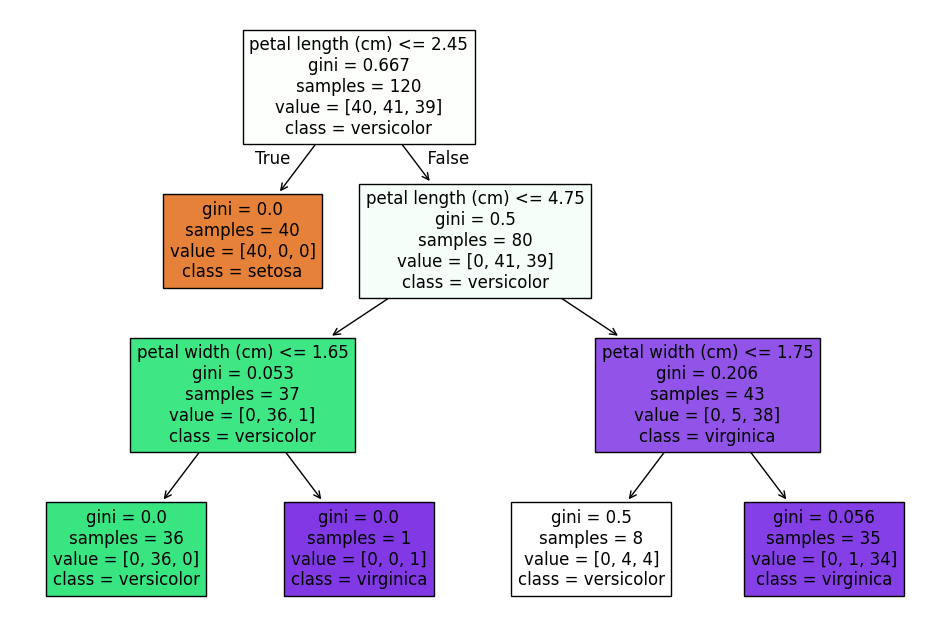

In [3]:
# Bước 1: Import các thư viện cần thiết
import pandas as pd
from sklearn.datasets import load_iris  
from sklearn.model_selection import train_test_split # Để chia dữ liệu
from sklearn.tree import DecisionTreeClassifier # Mô hình cây quyết định
from sklearn.metrics import accuracy_score # Để đánh giá mô hình

# Bước 2: Tải và chuẩn bị dữ liệu
iris = load_iris()
X = iris.data # Đặc trưng (chiều dài, rộng đài hoa, cánh hoa)
y = iris.target # Nhãn (loài hoa)

print(f"Các đặc trưng: {iris.feature_names}")
print(f"Các lớp: {iris.target_names}")

# Bước 3: Chia dữ liệu thành tập huấn luyện (train) và tập kiểm tra (test)
# 80% cho train, 20% cho test. random_state để đảm bảo kết quả có thể tái lập
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Bước 4: Khởi tạo mô hình
# Chúng ta có thể set max_depth để giới hạn độ sâu, tránh overfitting
# criterion='gini' là tiêu chí phân tách (có thể dùng 'entropy')
dt_model = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)

# Bước 5: Huấn luyện mô hình
# Dùng phương thức .fit() với dữ liệu huấn luyện
dt_model.fit(X_train, y_train)

print("\nĐã huấn luyện xong mô hình Cây Quyết Định!")

# Bước 6: Đưa ra dự đoán trên tập test
y_pred = dt_model.predict(X_test)

# Bước 7: Đánh giá mô hình
accuracy = accuracy_score(y_test, y_pred)
print(f"Độ chính xác trên tập Test: {accuracy * 100:.2f}%")

# (Tùy chọn) Trực quan hóa cây
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
plot_tree(dt_model, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()

#### + Làm thế nào để triển khai một mô hình Random Forest trong Python? Bạn thường thiết lập các tham số nào (ví dụ: n_estimators, max_depth)?

Triển khai Random Forest rất giống với Cây Quyết Định, chỉ cần thay `DecisionTreeClassifier` bằng `RandomForestClassifier`.

In [4]:
# Import thư viện
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Tải và chia dữ liệu (tương tự như trên)
iris = load_iris()
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Khởi tạo mô hình Random Forest
# Các tham số quan trọng thường thiết lập:
rf_model = RandomForestClassifier(
    n_estimators=100,     # (Quan trọng) Số lượng cây trong rừng. Thường là 100, 200, 500...
    max_depth=5,          # Độ sâu tối đa của MỖI cây. Giúp kiểm soát overfitting.
    max_features='sqrt',  # Số lượng đặc trưng ngẫu nhiên để xem xét tại mỗi split.
                          # 'sqrt' (căn bậc 2 của tổng số đặc trưng) là phổ biến.
    random_state=42,      # Để đảm bảo kết quả có thể tái lập.
    n_jobs=-1             # Sử dụng tất cả các nhân CPU để huấn luyện song song (nhanh hơn).
)

# Huấn luyện mô hình
rf_model.fit(X_train, y_train)

print("Đã huấn luyện xong mô hình Random Forest!")

# Dự đoán và Đánh giá
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Độ chính xác (Random Forest) trên tập Test: {accuracy_rf * 100:.2f}%")

Đã huấn luyện xong mô hình Random Forest!
Độ chính xác (Random Forest) trên tập Test: 100.00%


#### + Làm thế nào để đánh giá tầm quan trọng của các đặc trưng (feature importance) trong Random Forest bằng Python?

Sau khi mô hình RF được huấn luyện (dùng `.fit()` ), nó sẽ tự động tính toán và lưu trữ mức độ quan trọng của các đặc trưng trong thuộc tính `.feature_importances_`.

Giá trị này đo lường mức độ đóng góp trung bình của mỗi đặc trưng vào việc *giảm độ bất tinh khiết* (Gini hoặc Entropy) trên tất cả các cây trong rừng.


Mức độ quan trọng của các đặc trưng:
             Feature  Importance
2  petal length (cm)    0.445257
3   petal width (cm)    0.420793
0  sepal length (cm)    0.105913
1   sepal width (cm)    0.028037


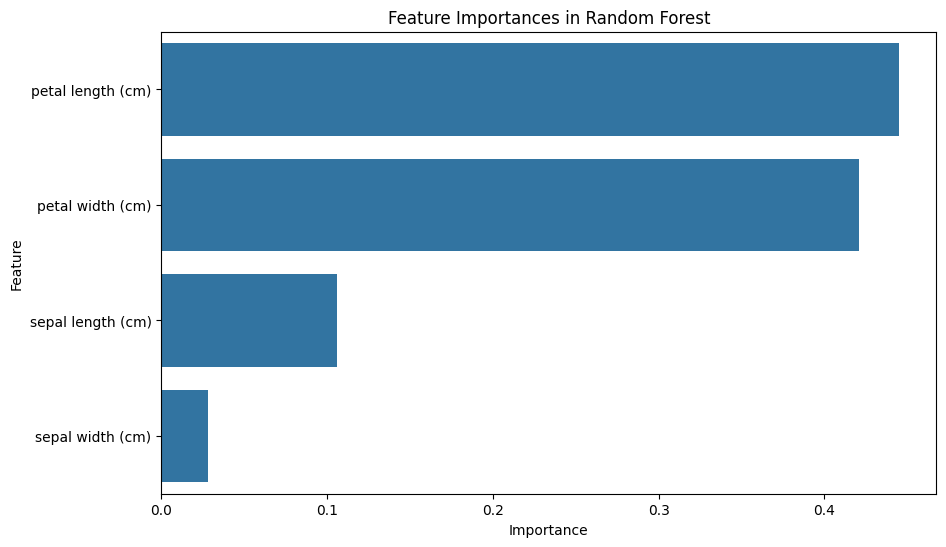

In [5]:
# Lấy ra danh sách các mức độ quan trọng
importances = rf_model.feature_importances_
feature_names = iris.feature_names

# Tạo một DataFrame để xem cho đẹp
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sắp xếp theo mức độ quan trọng giảm dần
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("\nMức độ quan trọng của các đặc trưng:")
print(feature_importance_df)

# Trực quan hóa (rất phổ biến)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importances in Random Forest')
plt.show()

#### + Điều chỉnh siêu tham số (hyperparameter tuning) cho cây quyết định hoặc Random Forest chưa? Hãy mô tả cách bạn sử dụng GridSearchCV hoặc RandomizedSearchCV

Điều chỉnh siêu tham số (Hyperparameter Tuning) là quá trình tìm ra bộ tham số tốt nhất (ví dụ: `n_estimators` hay `max_depth` nào là tối ưu) để mô hình đạt hiệu suất cao nhất.

**GridSearchCV (Tìm kiếm Lưới)**:

- **Cách hoạt động**: Thử tất cả các tổ hợp có thể có từ một "lưới" (grid) tham số bạn định nghĩa.

- **Ví dụ**: Nếu bạn định nghĩa max_depth = [3, 5, 7] và n_estimators = [100, 200], nó sẽ thử (3, 100), (3, 200), (5, 100), (5, 200), (7, 100), (7, 200) - tổng cộng 6 mô hình.

- **Ưu/Nhược**: Kỹ lưỡng (chắc chắn tìm ra_tốt nhất_trong lưới) nhưng rất chậm nếu lưới tham số lớn.

**RandomizedSearchCV (Tìm kiếm Ngẫu nhiên)**:

- **Cách hoạt động**: Thử một số lượng ngẫu nhiên (n_iter) các tổ hợp tham số từ một không gian tìm kiếm (thường là một phân phối xác suất).

- **Ưu/Nhược**: Nhanh hơn GridSearchCV rất nhiều và thường tìm được kết quả "đủ tốt", đặc biệt khi không gian tham số lớn.

In [6]:
from sklearn.model_selection import GridSearchCV

# 1. Định nghĩa "lưới" các tham số bạn muốn thử
# Đây là một lưới nhỏ để chạy cho nhanh
param_grid = {
    'n_estimators': [50, 100, 150],       # Thử 3 giá trị cho số lượng cây
    'max_depth': [3, 5, 7, None],         # Thử 4 giá trị cho độ sâu
    'max_features': ['sqrt', 'log2']      # Thử 2 giá trị cho max_features
}
# Tổng số mô hình sẽ huấn luyện = 3 * 4 * 2 = 24 mô hình
# Nếu dùng cross-validation (cv=5), tổng số lần fit = 24 * 5 = 120 lần!

# 2. Khởi tạo mô hình cơ sở (chưa huấn luyện)
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# 3. Khởi tạo GridSearchCV
# cv=5 nghĩa là dùng 5-fold cross-validation
# scoring='accuracy' là thước đo để chọn mô hình tốt nhất
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1 # In ra tiến trình
)

# 4. Huấn luyện (Đây là bước sẽ tốn thời gian)
print("\nBắt đầu Grid Search...")
grid_search.fit(X_train, y_train)

# 5. Xem kết quả
print("Đã hoàn thành Grid Search!")

# In ra các tham số tốt nhất
print(f"Các tham số tốt nhất tìm được: {grid_search.best_params_}")

# In ra độ chính xác tốt nhất (trên K-fold CV)
print(f"Độ chính xác CV tốt nhất: {grid_search.best_score_:.4f}")

# Lấy ra mô hình tốt nhất đã được huấn luyện
best_rf_model = grid_search.best_estimator_

# Đánh giá mô hình tốt nhất này trên tập Test
y_pred_best = best_rf_model.predict(X_test)
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Độ chính xác (Best Model) trên tập Test: {accuracy_best * 100:.2f}%")


Bắt đầu Grid Search...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Đã hoàn thành Grid Search!
Các tham số tốt nhất tìm được: {'max_depth': 3, 'max_features': 'sqrt', 'n_estimators': 50}
Độ chính xác CV tốt nhất: 0.9500
Độ chính xác (Best Model) trên tập Test: 100.00%


### 2.1.2. Bài làm mẫu

#### Bài toán 1: Xây dựng cây quyết định và rừng cây

##### Nhiệm vụ 1: Xây dựng cây quyết định bằng thư viện Scikit-Learn

1. Tải một số package mà chúng tôi sử dụng và package graphviz, để vẽ cây quyết định

In [1]:
import numpy as np #numerical computation
import pandas as pd #data wrangling
import matplotlib.pyplot as plt #plotting package
#Next line helps with rendering plots
%matplotlib inline
import matplotlib as mpl #add'l plotting functionality
mpl.rcParams['figure.dpi'] = 400 #high res figures
import graphviz #to visualize decision trees

2. Nạp dữ liệu vào bộ nhớ, phân tích và loại bỏ những features không liên quan đến bài toán cần giải
quyết

In [2]:
df = pd.read_csv('default_of_credit_card_clients.csv') #Load the cleaned data
features_response = df.columns.tolist() #Get a list of column names

#Make a list of columns to remove that aren't features or the response variable
items_to_remove = ['ID', 'SEX', 'PAY_2', 'PAY_3',\
                   'PAY_4', 'PAY_5', 'PAY_6',\
                   'EDUCATION_CAT', 'graduate school',\
                   'high school', 'none',\
                   'others', 'university']
features_response = [item for item in features_response if item not in items_to_remove]
features_response

['LIMIT_BAL',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default payment next month']

3. Chuẩn bị dữ liệu cho tập train và tập test

In [3]:
from sklearn.model_selection import train_test_split
from sklearn import tree

#Split the data into training and testing sets using the same random seed
X_train, X_test, y_train, y_test = \
train_test_split(df[features_response[:-1]].values,
df['default payment next month'].values,
test_size=0.2, random_state=24)

4. Xây dựng cây quyết định từ lớp DecisionTreeClassifier có trong thư viện Scikit-Learn

In [4]:
# the tree will grow to a depth of at most 2
dt = tree.DecisionTreeClassifier(max_depth=2)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2)

5. Hiển thị cây quyết định với package graphviz

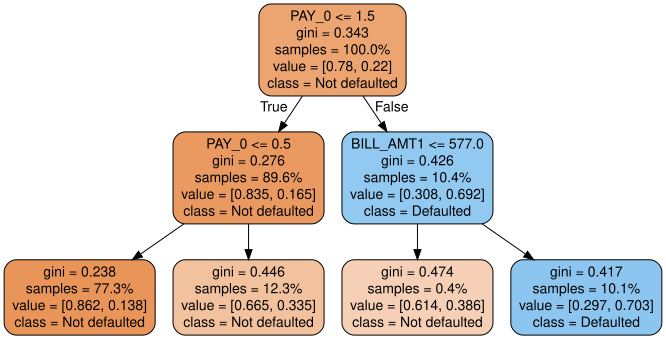

In [5]:
dot_data = tree.export_graphviz(dt,
                                out_file=None,
                                filled=True,
                                rounded=True,
                                feature_names=\
                                features_response[:-1],
                                proportion=True,
                                class_names=['Not defaulted', 'Defaulted'])
graph = graphviz.Source(dot_data)
graph

##### Nhiệm vụ 2: Tìm tham số tối ưu cho cây quyết định bằng GridSearchCV và vẽ biểu đồ đánh giá mô hình với các tham số khác nhau

1. Thực hiện 1, 2 và 3 như ở nhiệm vụ 1 để tải thư viện, nạp dữ liệu và chuẩn bị dữ liệu

2. Tạo cây quyết định và xác định các giá trị tham số có thể chọn để tìm tham số tối ưu

In [6]:
from sklearn.model_selection import GridSearchCV
params = {'max_depth':[1, 2, 4, 6, 8, 10, 12]} #parameters
dt = tree.DecisionTreeClassifier() #tree modal
cv = GridSearchCV(dt, param_grid=params, scoring='roc_auc',
n_jobs=None, refit=True, cv=4, verbose=1,
error_score=np.nan,
return_train_score=True) # cv is the best model.
cv.fit(X_train, y_train)

Fitting 4 folds for each of 7 candidates, totalling 28 fits


GridSearchCV(cv=4, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [1, 2, 4, 6, 8, 10, 12]},
             return_train_score=True, scoring='roc_auc', verbose=1)

`scoring = 'roc_auc'` **(Thước đo ROC AUC)**  

Đây là thước đo bạn chọn để `GridSearchCV` quyết định xem mô hình nào là "tốt nhất".

- Viết tắt: `roc_auc` là viết tắt của Receiver Operating Characteristic - Area Under the Curve (Diện tích dưới đường cong ROC).

- Ý nghĩa: Nó đo lường khả năng của mô hình trong việc phân biệt giữa hai lớp (ví dụ: 'Defaulted' và 'Not defaulted').

- Cách đọc giá trị:

    - 1.0: Mô hình hoàn hảo. Có thể phân biệt 100% hai lớp.

    - 0.5: Mô hình vô dụng. Hiệu suất không khác gì việc tung đồng xu (đoán ngẫu nhiên).

    - < 0.5: Mô hình tệ, dự đoán ngược (nhầm lẫn giữa hai lớp).

- Tại sao dùng nó? `roc_auc` đặc biệt hữu ích khi dữ liệu của bạn bị mất cân bằng (ví dụ: 95% là 'Not defaulted' và chỉ 5% là 'Defaulted'). Trong trường hợp này, `accuracy` (độ chính xác) có thể gây hiểu nhầm, nhưng `roc_auc` vẫn đưa ra đánh giá khách quan về khả năng phân loại của mô hình.  

---  

`cv = 4` **(Kiểm định chéo 4 phần)**  

Đây là viết tắt của 4-fold Cross-Validation. Đây là kỹ thuật để đánh giá hiệu suất của mô hình một cách đáng tin cậy.

**Cách hoạt động**: `GridSearchCV` sẽ lấy toàn bộ tập dữ liệu huấn luyện (`X_train`, `y_train`) của bạn và thực hiện các bước sau:

1. Chia: Xáo trộn và chia `X_train` thành 4 phần (folds) bằng nhau.

2. Lặp (4 lần): Để đánh giá một bộ tham số (ví dụ: `max_depth=4`), nó sẽ:

    - Lần 1: Dùng 3 phần (1, 2, 3) để huấn luyện (train) và dùng phần còn lại (phần 4) để kiểm tra (validate). Tính điểm `roc_auc` (1).

    - Lần 2: Dùng 3 phần (1, 2, 4) để train và dùng phần 3 để validate. Tính điểm `roc_auc` (2).

    - Lần 3: Dùng 3 phần (1, 3, 4) để train và dùng phần 2 để validate. Tính điểm `roc_auc` (3).

    - Lần 4: Dùng 3 phần (2, 3, 4) để train và dùng phần 1 để validate. Tính điểm `roc_auc` (4).

**Tổng kết**: Điểm `roc_auc` cuối cùng cho bộ tham số `max_depth=4` sẽ là trung bình cộng của 4 điểm `roc_auc` (1, 2, 3, 4) ở trên.

**Mục đích**: Việc này giúp đảm bảo hiệu suất của mô hình không phải là do "may mắn" ăn theo một cách chia train/test cụ thể. Nó cho ra một con số đánh giá ổn định và đáng tin cậy hơn.  

---

`return_train_score = True` **(Trả về điểm huấn luyện)**  

Tham số này rất quan trọng để chẩn đoán Bias (Độ chệch) và Variance (Phương sai).

- Mặc định (`False`): `GridSearchCV` chỉ lưu lại điểm số trên các tập kiểm tra (validation folds) - tức là `mean_test_score` trong `cv.cv_results_`.

- Khi đặt là `True`: Ngoài điểm kiểm tra, nó cũng sẽ tính toán và lưu lại điểm số của mô hình trên chính các tập huấn luyện (training folds) mà nó vừa học - tức là `mean_train_score`.

**Cách dùng để đánh giá Bias/Variance** :

Bạn sẽ so sánh `mean_train_score` và `mean_test_score` (điểm validation) cho từng giá trị của `max_depth`:

1. **High Variance (Overfitting - Phương sai cao)**:

- `mean_train_score` rất cao (ví dụ: 0.99 - 1.0).

- `mean_test_score` thấp hơn đáng kể (ví dụ: 0.85).

- **Ý nghĩa**: Mô hình quá phức tạp (ví dụ `max_depth` quá lớn). Nó "học thuộc lòng" dữ liệu huấn luyện nhưng không thể tổng quát hóa tốt trên dữ liệu mới.

2. High Bias (Underfitting - Độ chệch cao):

- `mean_train_score` thấp.

- `mean_test_score` cũng thấp và gần bằng `mean_train_score` (ví dụ: cả hai đều ~0.6).

- **Ý nghĩa**: Mô hình quá đơn giản (ví dụ `max_depth = 1`). Nó không đủ phức tạp để học được các quy luật trong dữ liệu.

3. **Good Fit (Mô hình tốt - Cân bằng)**:

- `mean_train_score` cao.

- `mean_test_score` cao và gần bằng `mean_train_score`.

- **Ý nghĩa**: Đây là điểm cân bằng lý tưởng, nơi mô hình vừa học tốt vừa tổng quát hóa tốt.

Bằng cách vẽ đồ thị hai đường này, bạn có thể thấy rõ ràng mô hình bắt đầu bị overfitting tại `max_depth` bằng bao nhiêu.

3. Vẽ biểu đồ đánh giá mô hình với các tham số chiều sâu của cây khác nhau

Text(0, 0.5, 'ROC AUC')

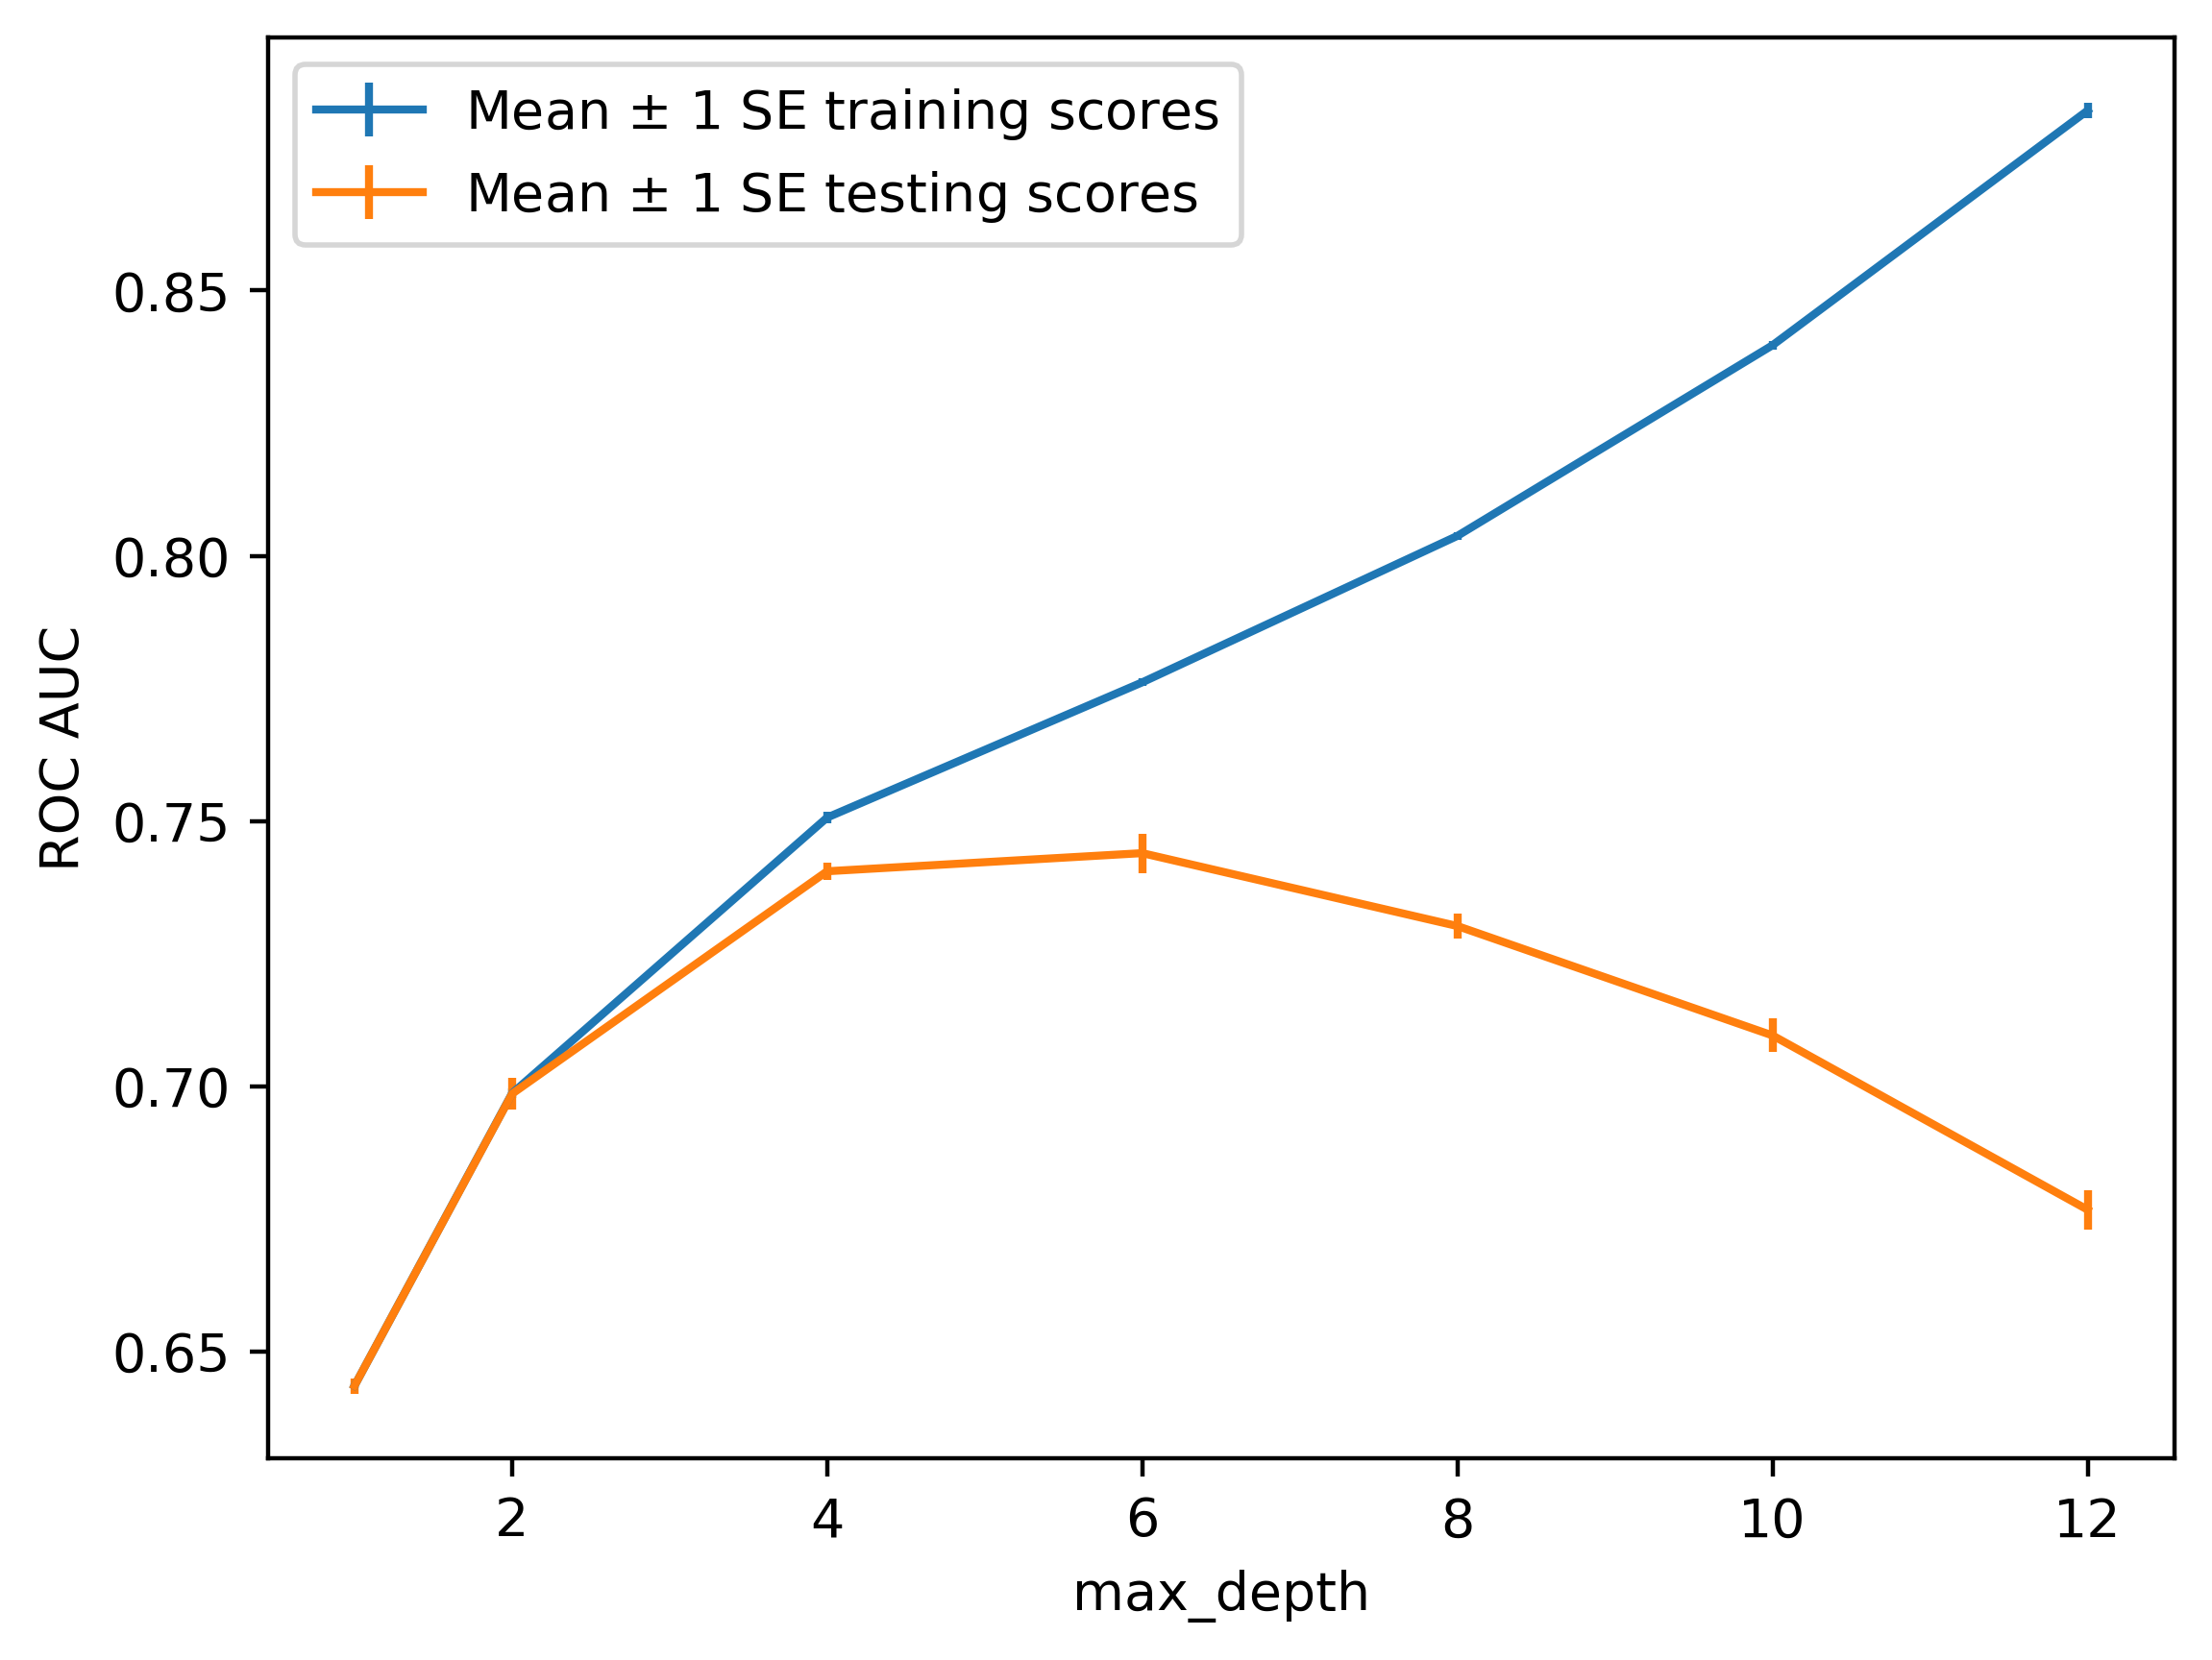

In [8]:
cv_results_df = pd.DataFrame(cv.cv_results_)

#View the names of the remaining columns in the results DataFrame
cv_results_df.columns
ax = plt.axes()
ax.errorbar(cv_results_df['param_max_depth'],
cv_results_df['mean_train_score'],
yerr=cv_results_df['std_train_score']/np.sqrt(4),
label='Mean $\pm$ 1 SE training scores')
ax.errorbar(cv_results_df['param_max_depth'],
cv_results_df['mean_test_score'],
yerr=cv_results_df['std_test_score']/np.sqrt(4),
label='Mean $\pm$ 1 SE testing scores')
ax.legend()
plt.xlabel('max_depth')
plt.ylabel('ROC AUC')

##### Nhiệm vụ 3: Xây dựng rừng cây (random forest)

1. Thực hiện 1, 2 và 3 như ở nhiệm vụ 1 để tải thư viện, nạp dữ liệu và chuẩn bị dữ liệu
2. Tạo rừng cây với lớp RandomForestClassifier trong Scikit-Learn

In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier\
    (n_estimators=10, criterion='gini', max_depth=3,
    min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0,
    max_features='sqrt', max_leaf_nodes=None, min_impurity_decrease=0.0,
    bootstrap=True, oob_score=False, n_jobs=None,
    random_state=4, verbose=0, warm_start=False, class_weight=None)

3. Tìm tham số tối ưu cho mô hình rừng cây và thực hiện train với tham số tối ưu đó

In [12]:
#a parameter grid for this exercise in order to search the numbers of trees, ranging from 10 to 100 by 10s
rf_params_ex = {'n_estimators':list(range(10,110,10))}
cv_rf_ex = GridSearchCV(rf, param_grid=rf_params_ex,
                        scoring='roc_auc', n_jobs=None,
                        refit=True, cv=4, verbose=1,
                        error_score=np.nan,
                        return_train_score=True)

cv_rf_ex.fit(X_train, y_train)

Fitting 4 folds for each of 10 candidates, totalling 40 fits


GridSearchCV(cv=4,
             estimator=RandomForestClassifier(max_depth=3, n_estimators=10,
                                              random_state=4),
             param_grid={'n_estimators': [10, 20, 30, 40, 50, 60, 70, 80, 90,
                                          100]},
             return_train_score=True, scoring='roc_auc', verbose=1)

4. Vẽ biểu đồ đánh giá mô hình rừng cây với các tham số số cây có trong rừng khác nhau

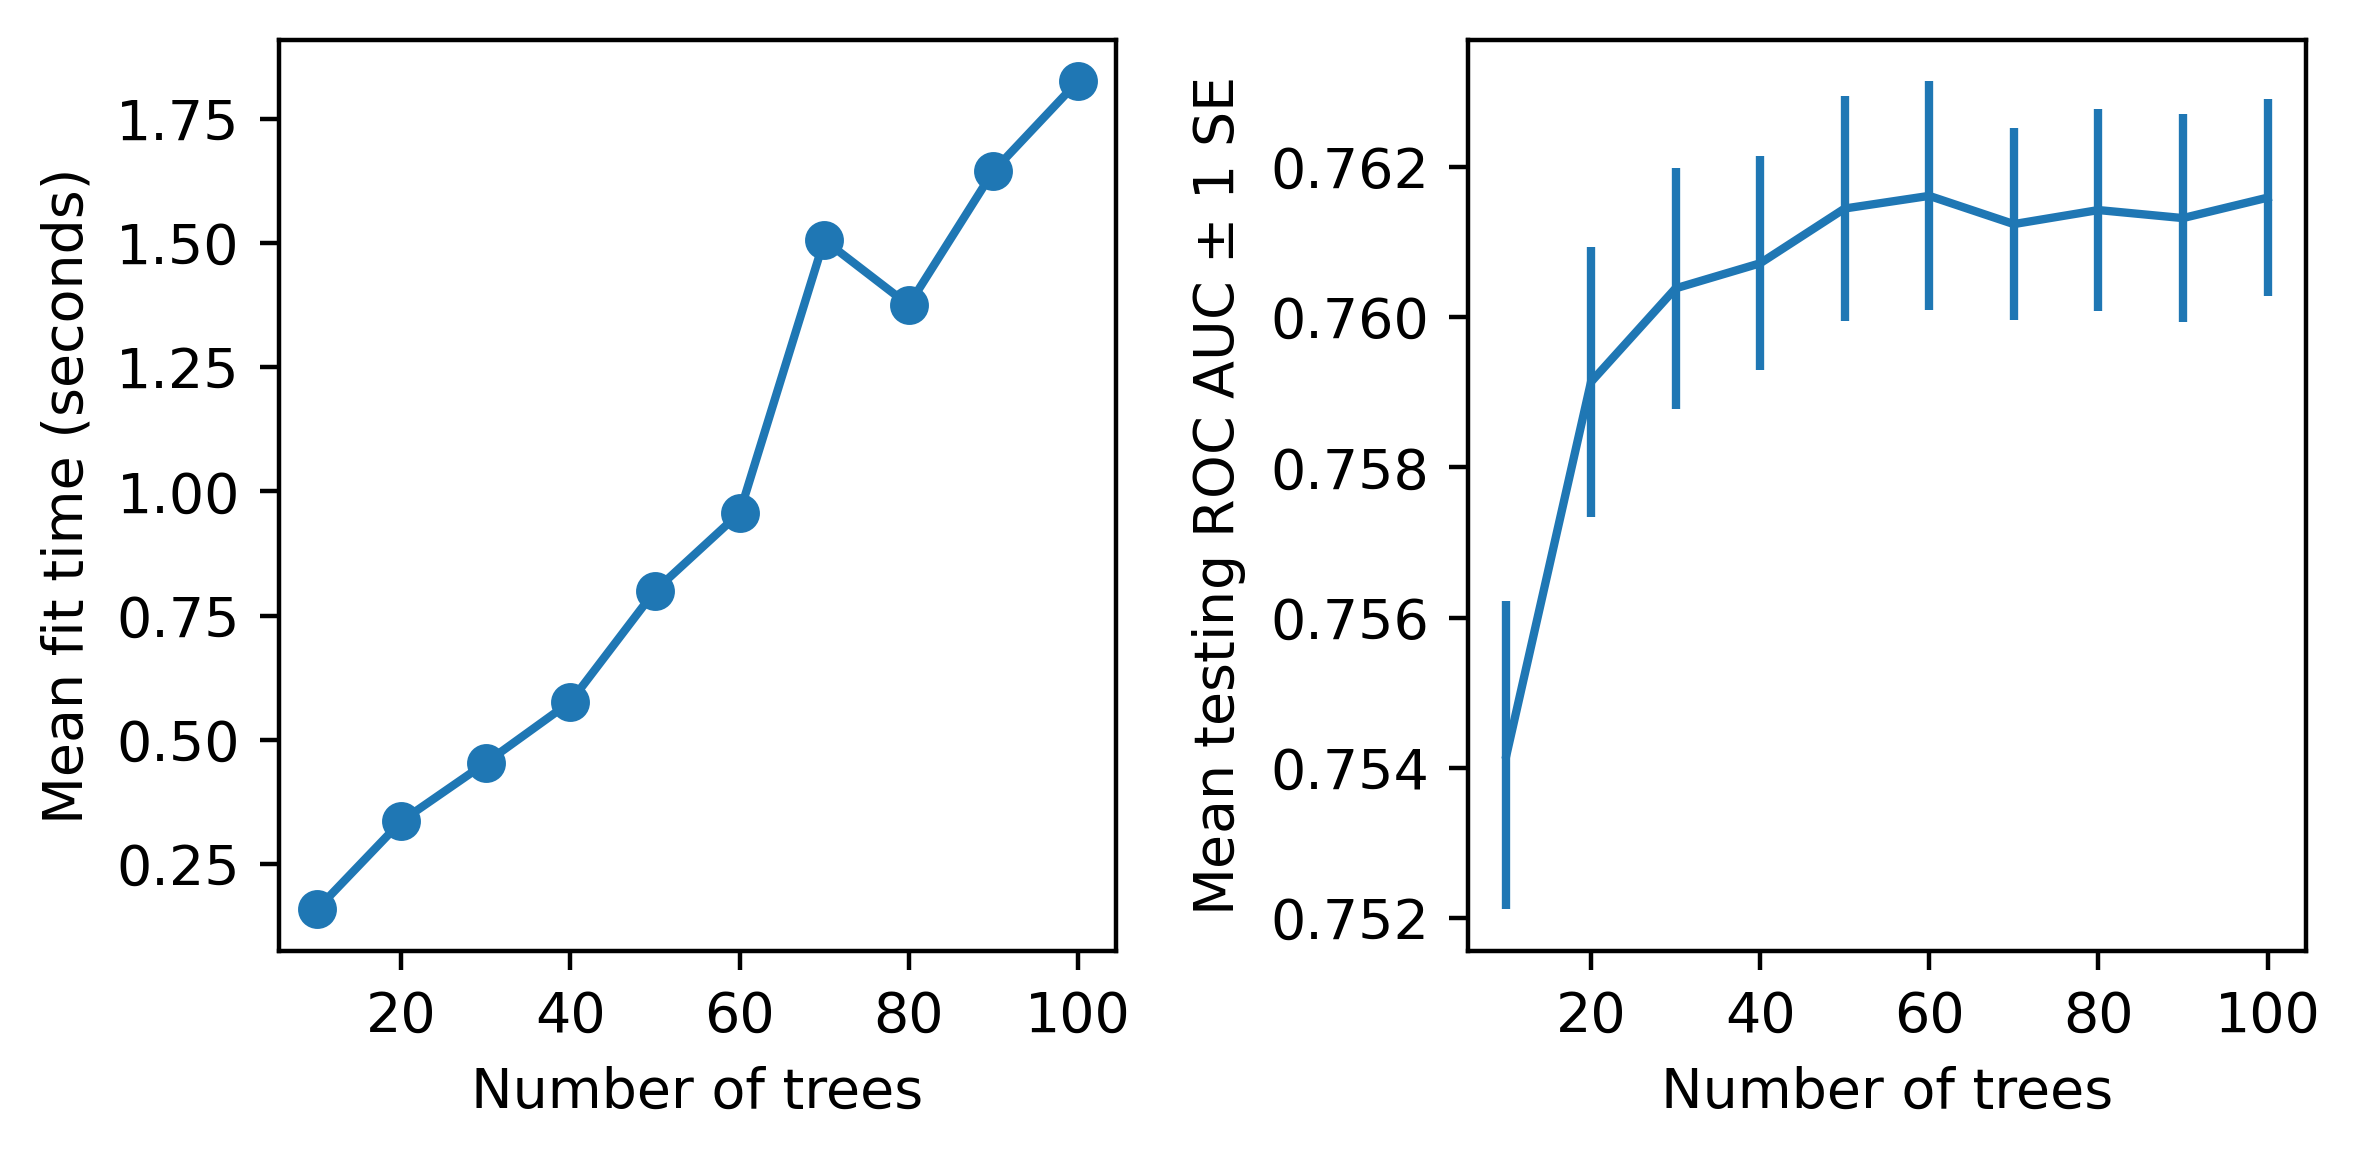

In [13]:
cv_rf_ex_results_df = pd.DataFrame(cv_rf_ex.cv_results_)
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(6, 3))
axs[0].plot(cv_rf_ex_results_df['param_n_estimators'],
            cv_rf_ex_results_df['mean_fit_time'],
            '-o')

axs[0].set_xlabel('Number of trees')
axs[0].set_ylabel('Mean fit time (seconds)')
axs[1].errorbar(cv_rf_ex_results_df['param_n_estimators'],
                cv_rf_ex_results_df['mean_test_score'],
                yerr=cv_rf_ex_results_df['std_test_score']/np.sqrt(4))

axs[1].set_xlabel('Number of trees')
axs[1].set_ylabel('Mean testing ROC AUC $\pm$ 1 SE ')
plt.tight_layout()

5. Xem tham số tốt nhất của rừng cây, xem mức độ quan trọng của từng feature trong mô hình với tham
số tốt nhất

<Axes: >

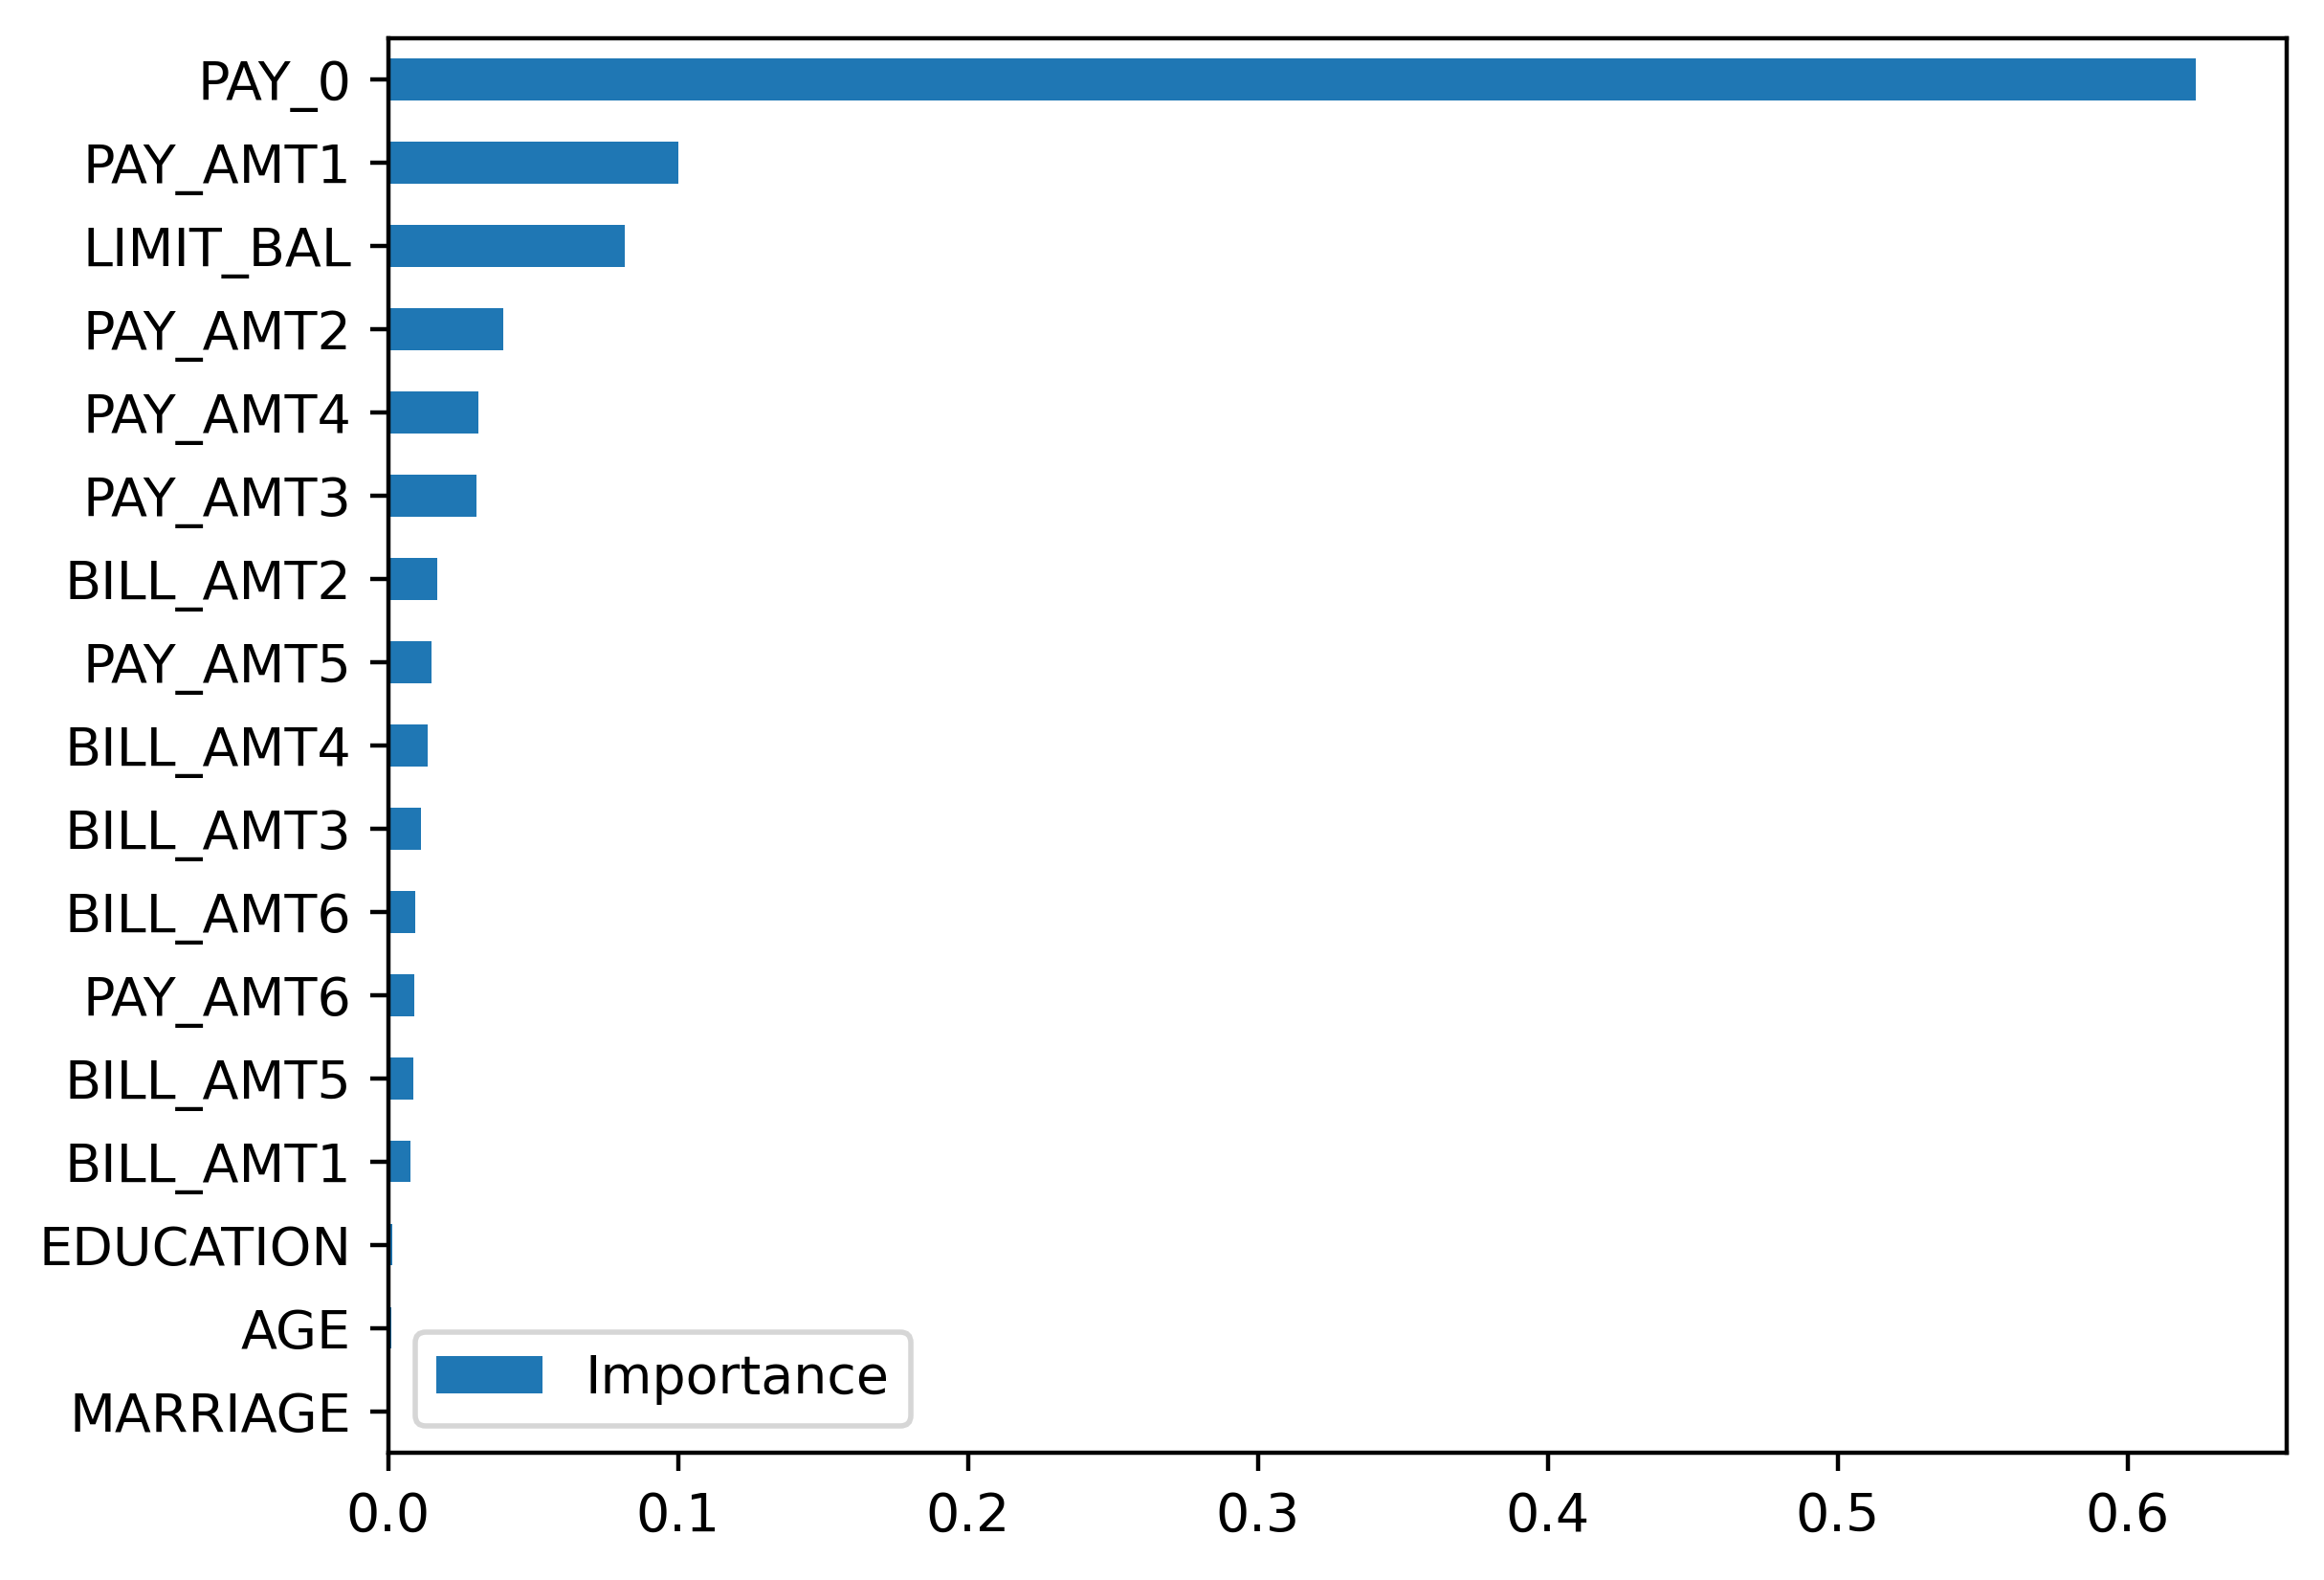

In [14]:
# {'n_estimators': 50}
cv_rf_ex.best_params_

# the feature names and importances
feat_imp_df = pd.DataFrame({
'Importance':cv_rf_ex.best_estimator_.feature_importances_},
index=features_response[:-1])
feat_imp_df.sort_values('Importance', ascending=True).plot.barh()

### 2.1.3. Bài tập thực hành 1 
Xây dựng cây quyết định và rừng cây trên dữ liệu Titanic lấy từ
https://www.kaggle.com/code/dmilla/introduction-to-decision-trees-titanic-dataset

#### 2.1.3.1. Tải các thư viện cần thiết

In [15]:
import numpy as np #numerical computation
import pandas as pd #data wrangling
import matplotlib.pyplot as plt #plotting package
import graphviz #to visualize decision trees
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score

#Next line helps with rendering plots
%matplotlib inline
import matplotlib as mpl #add'l plotting functionality
mpl.rcParams['figure.dpi'] = 400 #high res figures

### 2.1.3.2. Tải và tiền xử lý dữ liệu (train.csv)

In [16]:
# Tải dữ liệu
df = pd.read_csv('train.csv')

# --- 2.1. Xử lý giá trị thiếu (NaN) ---

# Điền giá trị thiếu cho 'Age' (Tuổi) bằng giá trị trung vị (median)
age_median = df['Age'].median()
df['Age'] = df['Age'].fillna(age_median)

# Điền giá trị thiếu cho 'Embarked' (Cảng lên tàu) bằng giá trị xuất hiện nhiều nhất (mode)
embarked_mode = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(embarked_mode)

# Cột 'Cabin' có quá nhiều giá trị thiếu, chúng ta sẽ bỏ qua nó

# --- 2.2. Chuyển đổi dữ liệu (Categorical -> Numerical) ---

# Chuyển 'Sex' (Giới tính) sang dạng số: female=1, male=0
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Chuyển 'Embarked' sang dạng số bằng One-Hot Encoding
# drop_first=True để tránh bẫy biến giả (dummy variable trap)
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

print("Dữ liệu sau khi đã tiền xử lý (5 dòng đầu):")
print(df.head())

Dữ liệu sau khi đã tiền xử lý (5 dòng đầu):
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    0  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    1  38.0      1      0   
2                             Heikkinen, Miss. Laina    1  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    1  35.0      1      0   
4                           Allen, Mr. William Henry    0  35.0      0      0   

             Ticket     Fare Cabin  Embarked_Q  Embarked_S  
0         A/5 21171   7.2500   NaN       False        True  
1          PC 17599  71.2833   C85       False       False  
2  STON/O2. 3101282   7.9250   NaN       False        True  
3       

#### 2.1.3.3. Lựa chọn đặc trưng (Features) và biến mục tiêu (Target)

In [17]:
# Cột mục tiêu
target = 'Survived'

# Danh sách các đặc trưng (features) chúng ta sẽ dùng
# Loại bỏ các cột không liên quan như Name, Ticket, PassengerId, Cabin
features_list = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']

# Kiểm tra xem tất cả các cột đã chọn có trong DataFrame không
for col in features_list:
    if col not in df.columns:
        print(f"Cảnh báo: Cột {col} không tồn tại!")

print(f"Các đặc trưng sẽ sử dụng: {features_list}")

Các đặc trưng sẽ sử dụng: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']


#### 2.1.3.4. Chia dữ liệu (Train/Test Split) 
Tách dữ liệu thành 2 tập: huấn luyện (80%) và kiểm tra (20%).

In [18]:
# Lấy giá trị X (đặc trưng) và y (mục tiêu)
X = df[features_list].values
y = df[target].values

# Sử dụng train_test_split
X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.2, random_state=24)

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}")

Kích thước tập Train: (712, 8)
Kích thước tập Test: (179, 8)


#### 2.1.3.5 NHIỆM VỤ 1: XÂY DỰNG CÂY QUYẾT ĐỊNH (Decision Tree) 
Xây dựng một cây quyết định đơn giản với độ sâu max_depth=3 (để dễ trực quan hóa) và huấn luyện trên tập train.

Đang hiển thị Cây Quyết Định (max_depth=3)...


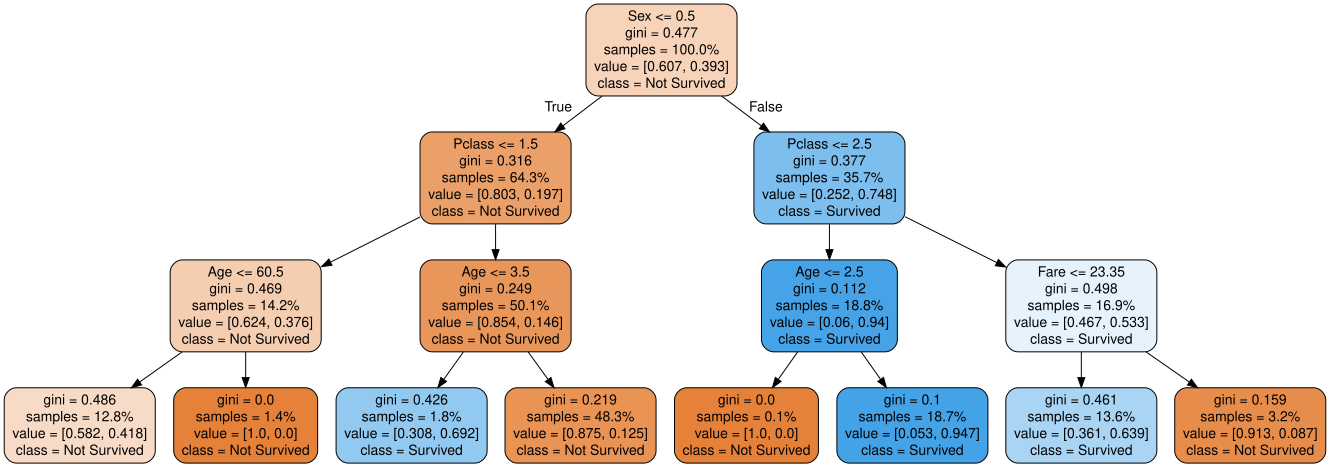

In [20]:
# 4. Xây dựng cây quyết định
dt = tree.DecisionTreeClassifier(max_depth=3, random_state=24)
dt.fit(X_train, y_train)

# 5. Hiển thị cây quyết định với package graphviz
dot_data = tree.export_graphviz(dt,
                                out_file=None,
                                filled=True,
                                rounded=True,
                                feature_names=features_list, # Sử dụng list features
                                proportion=True,
                                class_names=['Not Survived', 'Survived']) # 0 và 1

graph = graphviz.Source(dot_data)

# Lệnh 'graph' sẽ hiển thị cây trong file notebook của bạn
print("Đang hiển thị Cây Quyết Định (max_depth=3)...")
graph

#### 2.1.3.6 NHIỆM VỤ 2: TỐI ƯU CÂY QUYẾT ĐỊNH (GridSearchCV) 
Sử dụng GridSearchCV để tìm ra max_depth (độ sâu) tốt nhất cho cây quyết định và vẽ biểu đồ Bias-Variance.

##### 1. Tạo cây quyết định và lưới tham số

In [21]:
# Xác định các giá trị tham số để thử
params = {'max_depth':[2, 3, 4, 6, 8, 10, 12, 14, 16]} #parameters

# Khởi tạo mô hình cây (chưa huấn luyện)
dt_base = tree.DecisionTreeClassifier(random_state=24)

# Khởi tạo GridSearchCV
cv_dt = GridSearchCV(dt_base, param_grid=params, scoring='roc_auc',
                     n_jobs=-1, refit=True, cv=4, verbose=1,
                     return_train_score=True) # cv is the best model.

print("Bắt đầu tìm tham số tối ưu cho Cây Quyết Định...")

Bắt đầu tìm tham số tối ưu cho Cây Quyết Định...


##### 2. Huấn luyện mô hình GridSearchCV

In [22]:
cv_dt.fit(X_train, y_train)
print("Hoàn thành!")

# In ra tham số tốt nhất
print(f"Tham số max_depth tốt nhất tìm được: {cv_dt.best_params_}")
print(f"Điểm ROC AUC tốt nhất (trên tập validation): {cv_dt.best_score_:.4f}")

Fitting 4 folds for each of 9 candidates, totalling 36 fits
Hoàn thành!
Tham số max_depth tốt nhất tìm được: {'max_depth': 3}
Điểm ROC AUC tốt nhất (trên tập validation): 0.8437


### 3. Vẽ biểu đồ đánh giá (Bias-Variance) 
Vẽ biểu đồ so sánh điểm train và điểm test (validation) để xem mô hình bị overfit ở đâu.

Đang vẽ biểu đồ đánh giá max_depth...


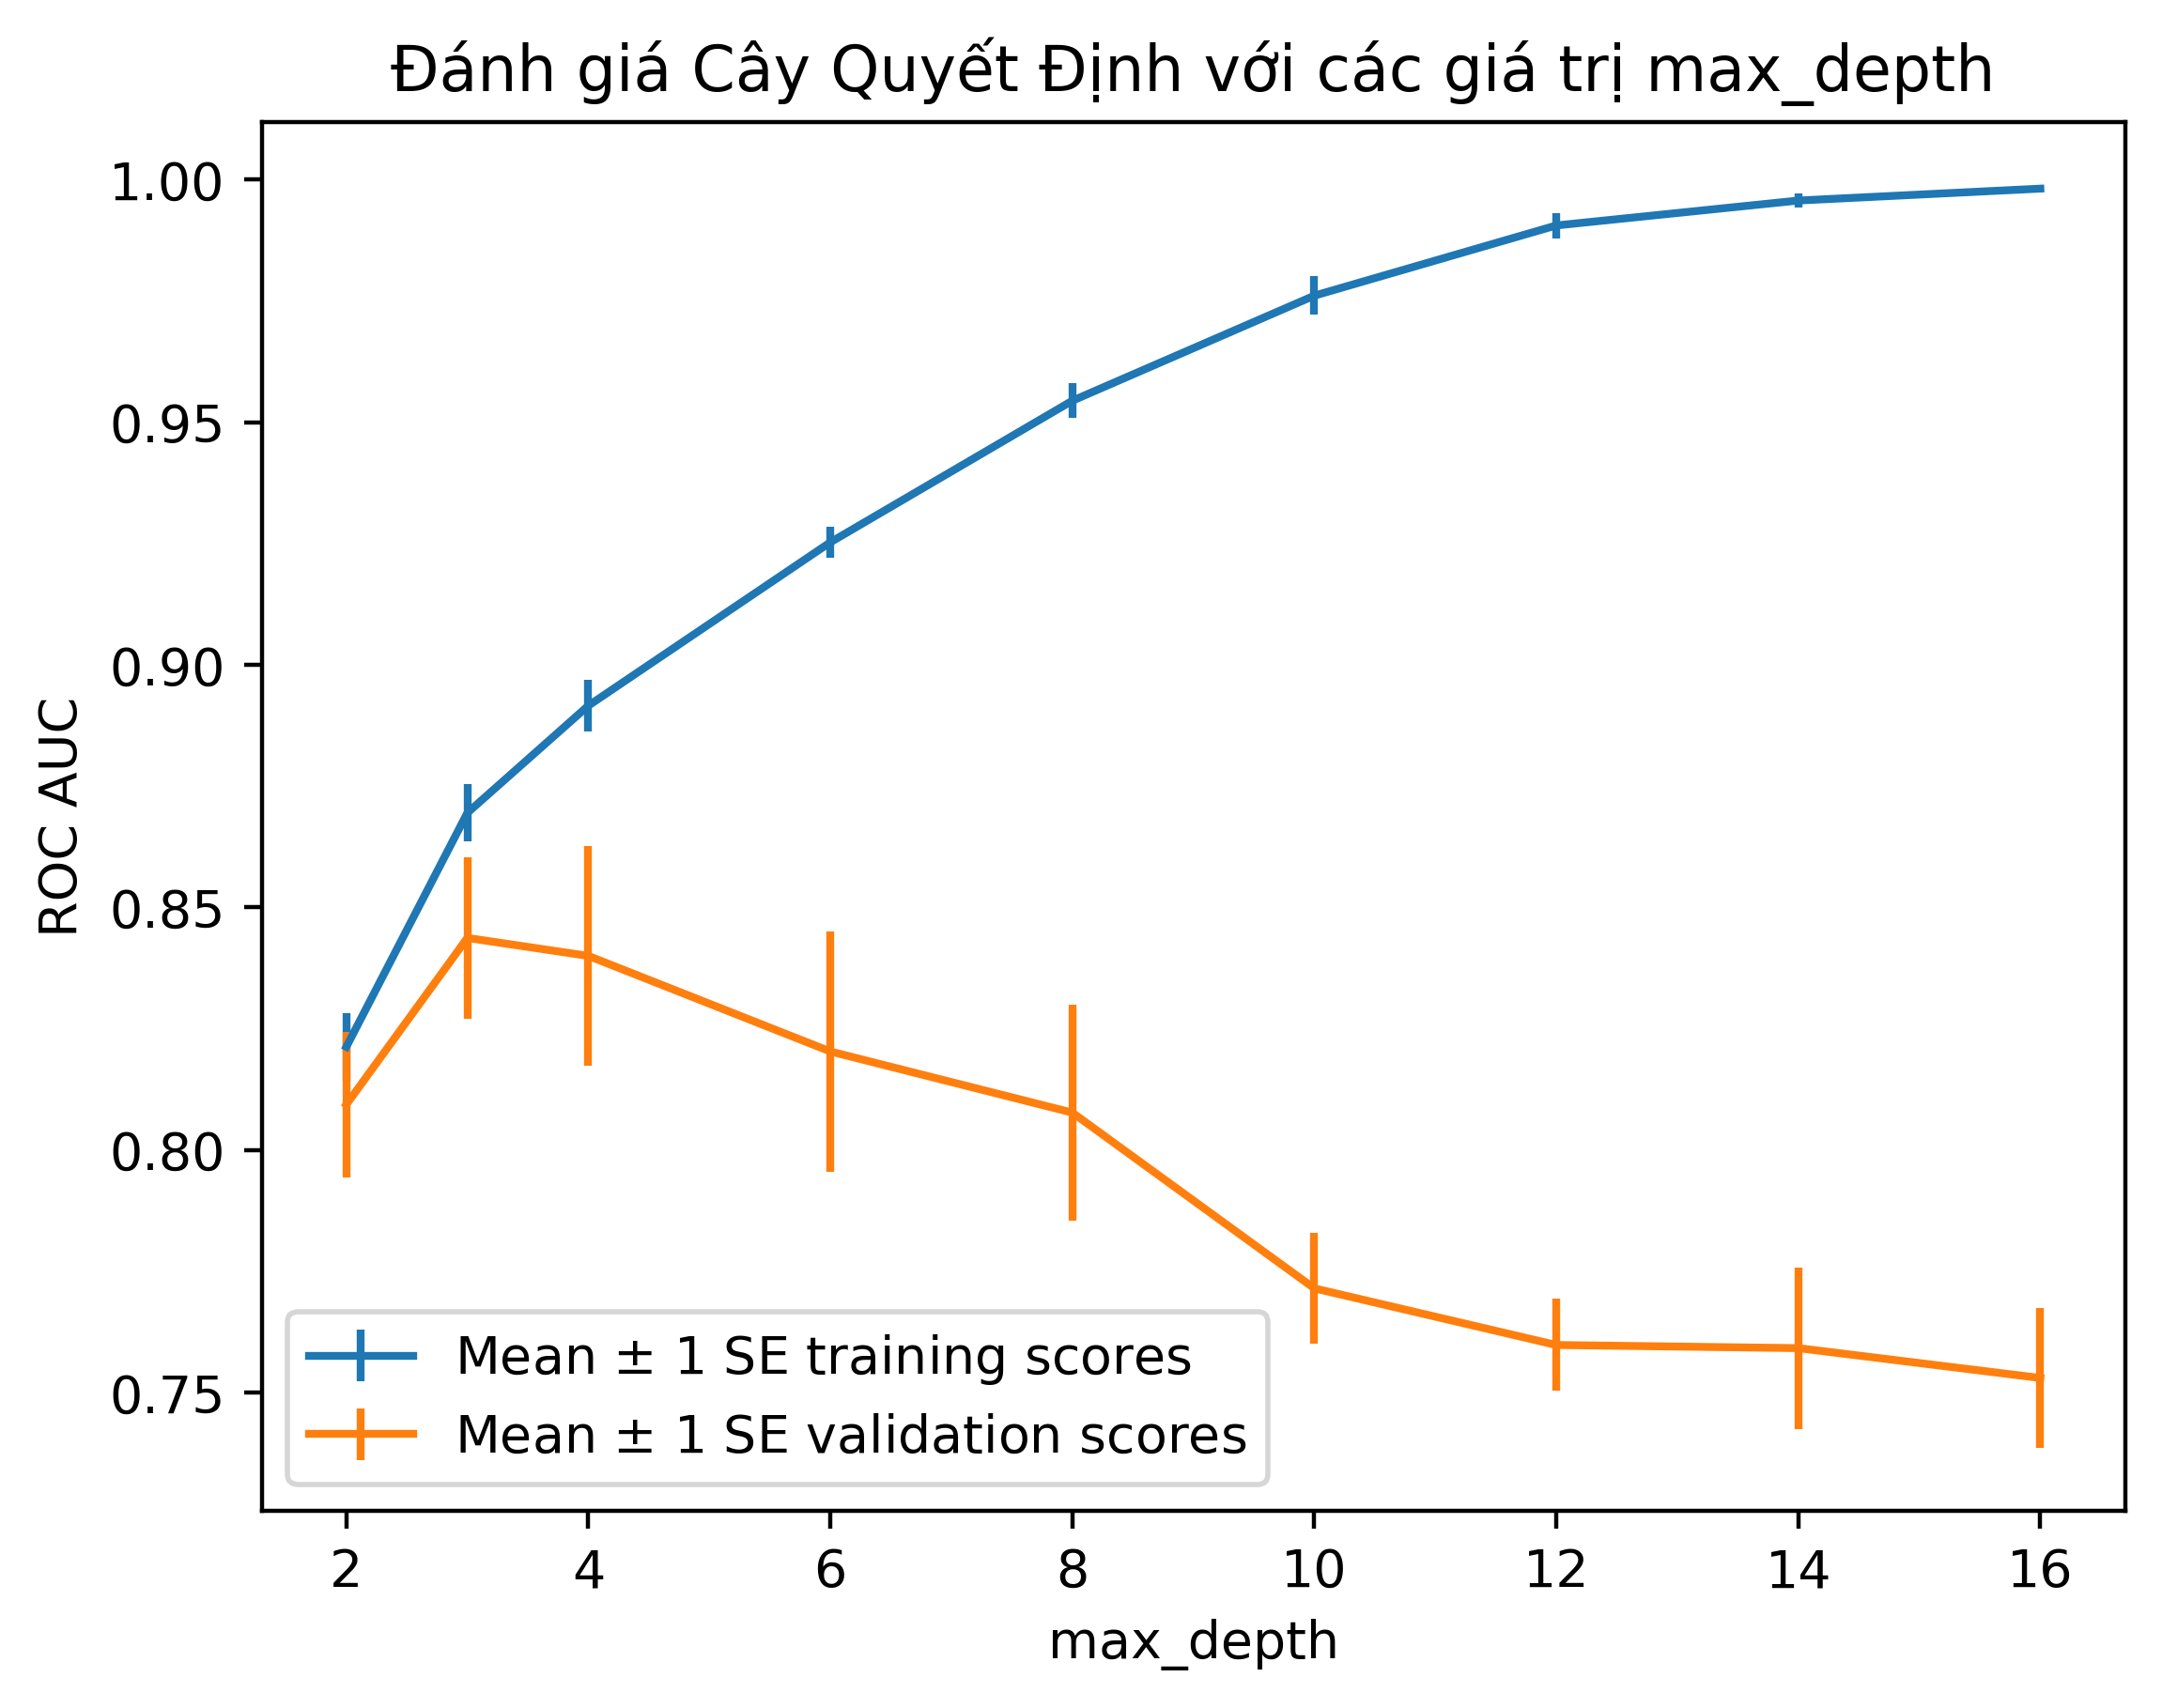

In [23]:
# Lấy kết quả từ GridSearchCV
cv_results_df = pd.DataFrame(cv_dt.cv_results_)

# Vẽ biểu đồ
print("Đang vẽ biểu đồ đánh giá max_depth...")
ax = plt.axes()
ax.errorbar(cv_results_df['param_max_depth'],
            cv_results_df['mean_train_score'],
            yerr=cv_results_df['std_train_score']/np.sqrt(4),
            label='Mean $\pm$ 1 SE training scores')
ax.errorbar(cv_results_df['param_max_depth'],
            cv_results_df['mean_test_score'],
            yerr=cv_results_df['std_test_score']/np.sqrt(4),
            label='Mean $\pm$ 1 SE validation scores') # 'test' ở đây là validation
ax.legend()
plt.xlabel('max_depth')
plt.ylabel('ROC AUC')
plt.title('Đánh giá Cây Quyết Định với các giá trị max_depth')
plt.show()

#### 2.1.3.7 NHIỆM VỤ 3: XÂY DỰNG RỪNG CÂY (Random Forest) 
Xây dựng mô hình Random Forest, dùng GridSearchCV để tìm `n_estimators` (số cây) tốt nhất, và xem xét mức độ quan trọng của các đặc trưng.

##### 1. Tạo rừng cây và lưới tham số

In [24]:
# Khởi tạo mô hình RF cơ sở (chưa huấn luyện)
# n_jobs=-1 để dùng tất cả CPU
rf_base = RandomForestClassifier(random_state=24, n_jobs=-1)

# Lưới tham số: tìm số lượng cây, từ 10 đến 100
rf_params_ex = {'n_estimators': list(range(10, 110, 10))} # [10, 20, ..., 100]

# Khởi tạo GridSearchCV
cv_rf_ex = GridSearchCV(rf_base, param_grid=rf_params_ex,
                        scoring='roc_auc', n_jobs=-1,
                        refit=True, cv=4, verbose=1,
                        return_train_score=True)

print("Bắt đầu tìm tham số tối ưu cho Rừng Cây...")

Bắt đầu tìm tham số tối ưu cho Rừng Cây...


##### 2. Huấn luyện mô hình GridSearchCV

In [25]:
cv_rf_ex.fit(X_train, y_train)
print("Hoàn thành!")

# In ra tham số tốt nhất
print(f"Tham số n_estimators tốt nhất tìm được: {cv_rf_ex.best_params_}")
print(f"Điểm ROC AUC tốt nhất (trên tập validation): {cv_rf_ex.best_score_:.4f}")

Fitting 4 folds for each of 10 candidates, totalling 40 fits
Hoàn thành!
Tham số n_estimators tốt nhất tìm được: {'n_estimators': 100}
Điểm ROC AUC tốt nhất (trên tập validation): 0.8575


##### 3. Vẽ biểu đồ đánh giá (Thời gian vs Hiệu suất) 
Vẽ 2 biểu đồ: Thời gian huấn luyện và Điểm ROC AUC theo số lượng cây.

Đang vẽ biểu đồ đánh giá n_estimators...


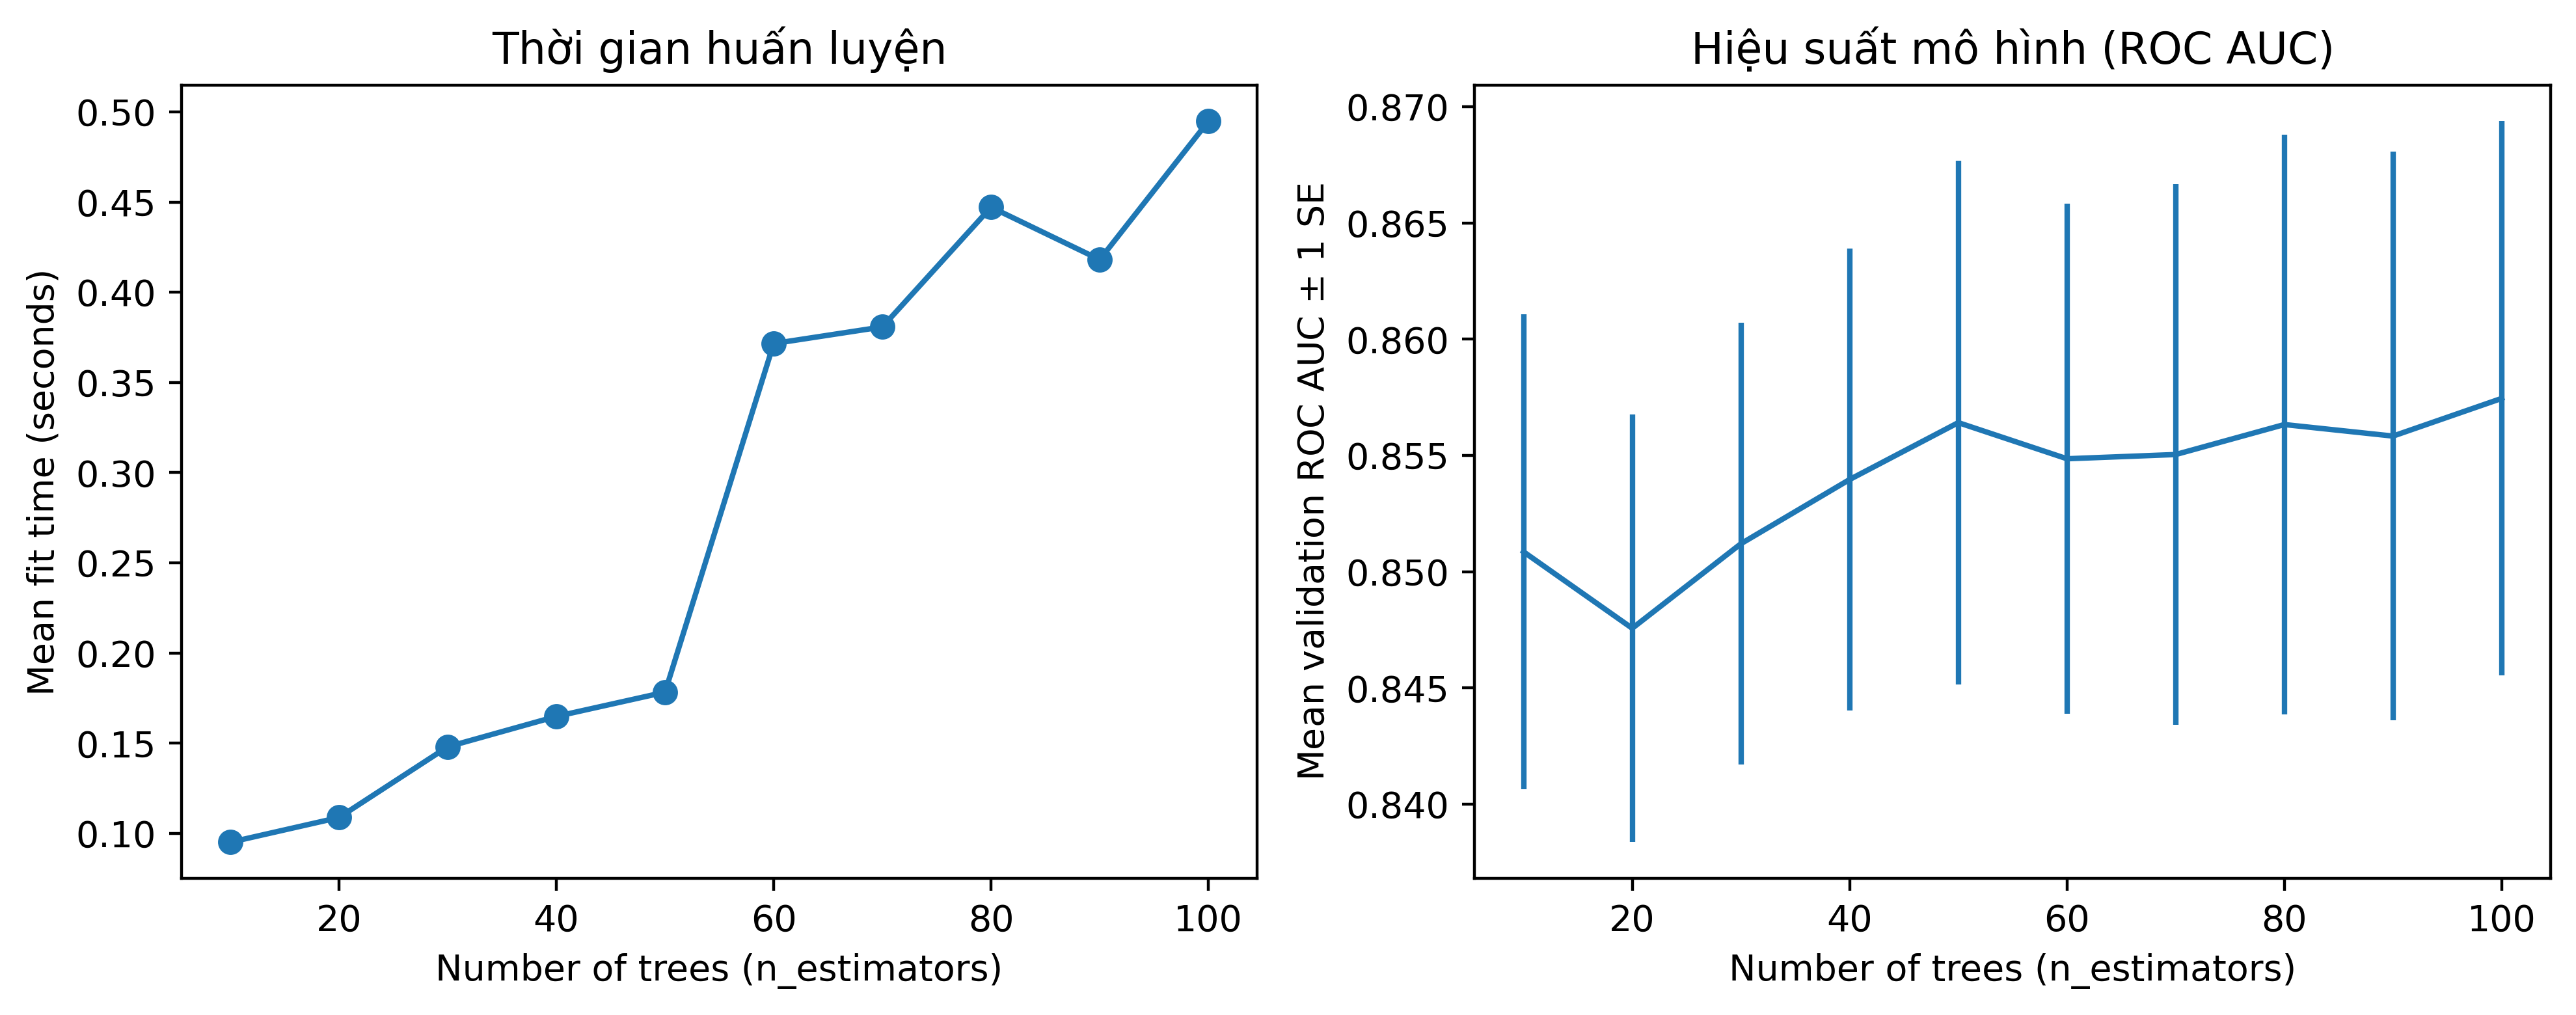

In [26]:
# Lấy kết quả
cv_rf_ex_results_df = pd.DataFrame(cv_rf_ex.cv_results_)

print("Đang vẽ biểu đồ đánh giá n_estimators...")
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

# Biểu đồ 1: Thời gian huấn luyện
axs[0].plot(cv_rf_ex_results_df['param_n_estimators'],
            cv_rf_ex_results_df['mean_fit_time'],
            '-o')
axs[0].set_xlabel('Number of trees (n_estimators)')
axs[0].set_ylabel('Mean fit time (seconds)')
axs[0].set_title('Thời gian huấn luyện')

# Biểu đồ 2: Điểm ROC AUC
axs[1].errorbar(cv_rf_ex_results_df['param_n_estimators'],
                cv_rf_ex_results_df['mean_test_score'],
                yerr=cv_rf_ex_results_df['std_test_score']/np.sqrt(4))
axs[1].set_xlabel('Number of trees (n_estimators)')
axs[1].set_ylabel('Mean validation ROC AUC $\pm$ 1 SE')
axs[1].set_title('Hiệu suất mô hình (ROC AUC)')

plt.tight_layout()
plt.show()

##### 4. Xem mức độ quan trọng của đặc trưng (Feature Importance) 
Lấy mô hình Random Forest tốt nhất (đã được refit) và xem đặc trưng nào quan trọng nhất.

Đang vẽ biểu đồ Feature Importance...


<Figure size 3200x2000 with 0 Axes>

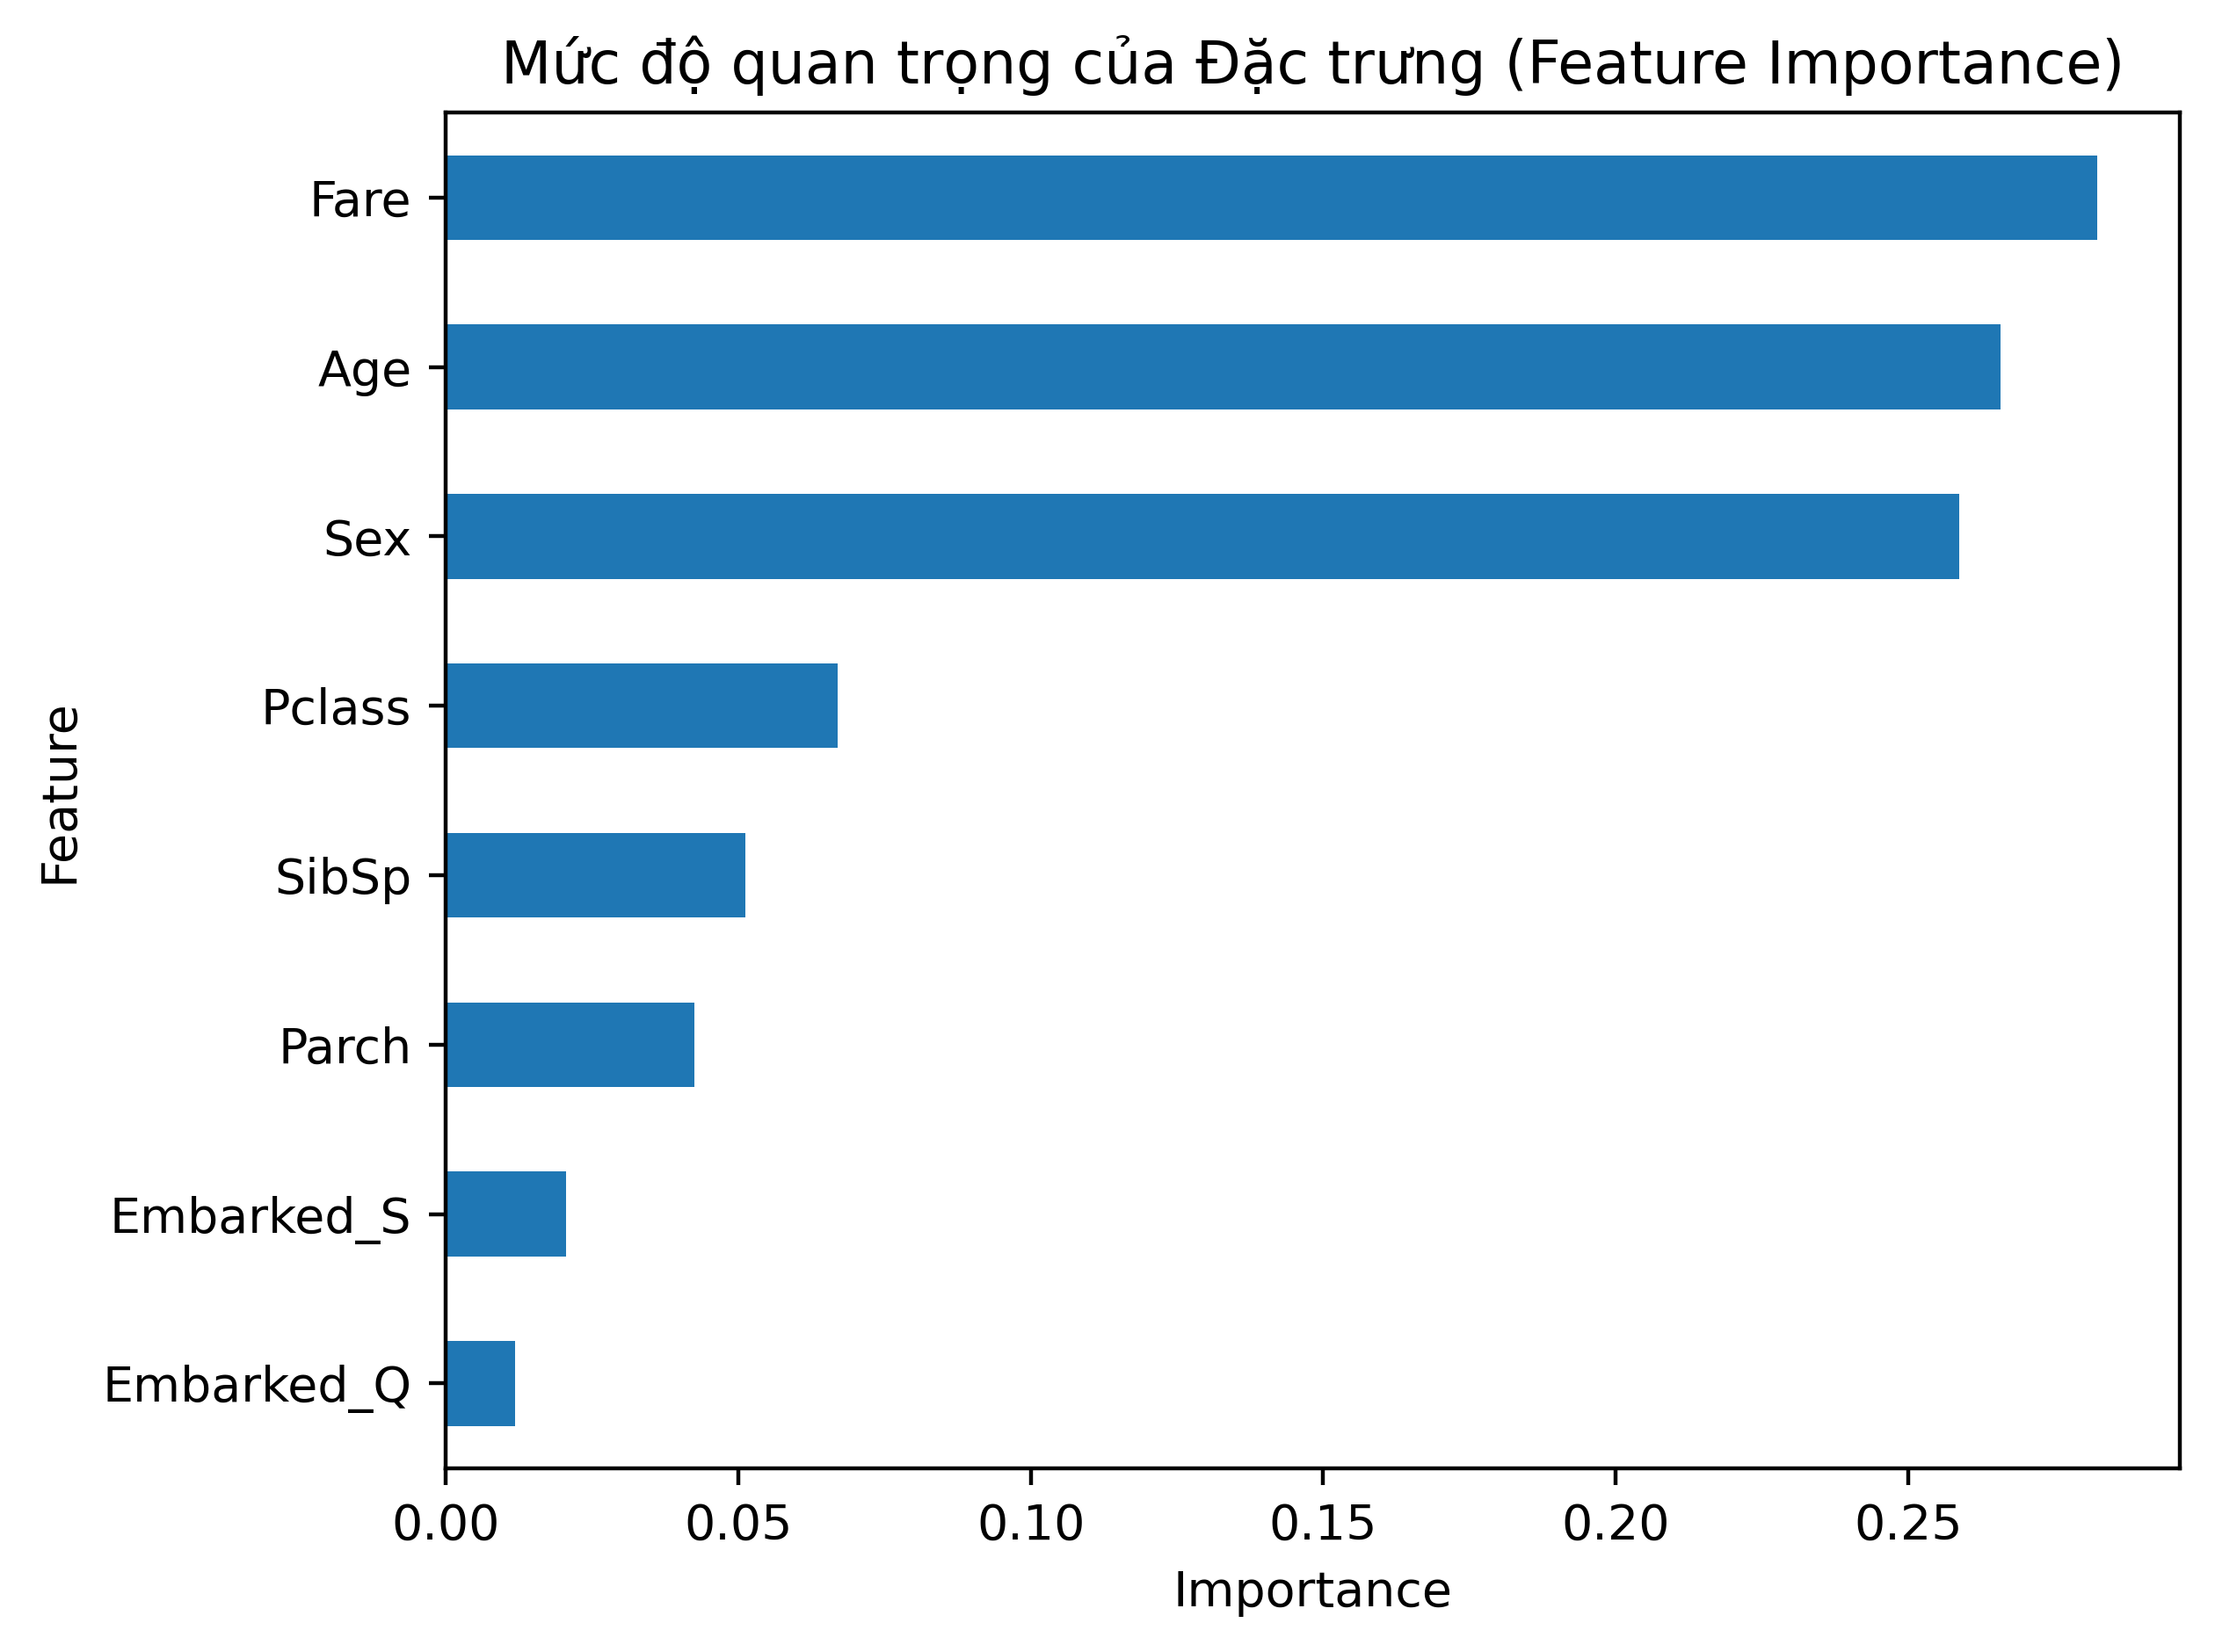

In [27]:
# Lấy ra mô hình tốt nhất
best_rf_model = cv_rf_ex.best_estimator_

# Lấy ra mức độ quan trọng
feat_imp_df = pd.DataFrame({
    'Importance': best_rf_model.feature_importances_},
    index=features_list) # Sử dụng list features

# Sắp xếp và vẽ biểu đồ
print("Đang vẽ biểu đồ Feature Importance...")
plt.figure(figsize=(8, 5))
feat_imp_df.sort_values('Importance', ascending=True).plot.barh(legend=False)
plt.title('Mức độ quan trọng của Đặc trưng (Feature Importance)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### 2.1.4. Bài tập thực hành 2

Xây dựng cây quyết định và rừng cây trên dữ liệu bệnh tiểu đường. Dữ liệu lấy từ
https://www.kaggle.com/code/tumpanjawat/diabetes-eda-random-forest-hp

#### 2.1.4.1. Tải các thư viện cần thiết

In [ ]:
import numpy as np #numerical computation
import pandas as pd #data wrangling
import matplotlib.pyplot as plt #plotting package
import graphviz #to visualize decision trees
import display 

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score

#Next line helps with rendering plots
%matplotlib inline
import matplotlib as mpl #add'l plotting functionality
mpl.rcParams['figure.dpi'] = 400 #high res figures

#### 2.1.4.2. Tải và tiền xử lý dữ liệu (diabetes_prediction_dataset.csv)
Dữ liệu này cần chuyển đổi các cột dạng chữ (gender, smoking_history) sang dạng số.

In [4]:
# Tải dữ liệu
df = pd.read_csv('diabetes_prediction_dataset.csv')

# --- 2.1. Tiền xử lý các cột chữ (Categorical) ---
# Dữ liệu này không có giá trị thiếu (NaN) nên không cần fillna.

# Cột 'gender' có 18 giá trị 'Other', quá ít so với 100.000 mẫu.
# Để đơn giản hóa mô hình, ta có thể loại bỏ chúng.
df = df[df['gender'] != 'Other']

# Chuyển đổi 'gender' và 'smoking_history' sang dạng số bằng One-Hot Encoding
# drop_first=True để tránh bẫy biến giả (dummy variable trap)
df = pd.get_dummies(df, columns=['gender', 'smoking_history'], drop_first=True)

print("Dữ liệu sau khi đã tiền xử lý (5 dòng đầu):")
display(df.head())

Dữ liệu sau khi đã tiền xử lý (5 dòng đầu):


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Male,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,False,False,False,False,True,False
1,54.0,0,0,27.32,6.6,80,0,False,False,False,False,False,False
2,28.0,0,0,27.32,5.7,158,0,True,False,False,False,True,False
3,36.0,0,0,23.45,5.0,155,0,False,True,False,False,False,False
4,76.0,1,1,20.14,4.8,155,0,True,True,False,False,False,False


#### 2.1.4.3. Lựa chọn đặc trưng (Features) và biến mục tiêu (Target) 
Chúng ta chọn các cột sẽ dùng để huấn luyện và cột mục tiêu (diabetes).

In [5]:
# Cột mục tiêu
target = 'diabetes'

# Lấy tất cả các cột khác làm đặc trưng (features)
features_list = df.columns.drop(target).tolist()

print(f"Các đặc trưng sẽ sử dụng: {features_list}")

Các đặc trưng sẽ sử dụng: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'gender_Male', 'smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not current']


### 2.1.4.4. Chia dữ liệu (Train/Test Split) 
Tách dữ liệu thành 2 tập: huấn luyện (80%) và kiểm tra (20%).

In [6]:
# Lấy giá trị X (đặc trưng) và y (mục tiêu)
X = df[features_list].values
y = df[target].values

# Sử dụng train_test_split
X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.2, random_state=24)

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}")

Kích thước tập Train: (79985, 12)
Kích thước tập Test: (19997, 12)


#### 2.1.4.5 NHIỆM VỤ 1: XÂY DỰNG CÂY QUYẾT ĐỊNH (Decision Tree) 
Xây dựng một cây quyết định đơn giản với độ sâu max_depth=3 (để dễ trực quan hóa) và huấn luyện trên tập train.

Đang hiển thị Cây Quyết Định (max_depth=3)...


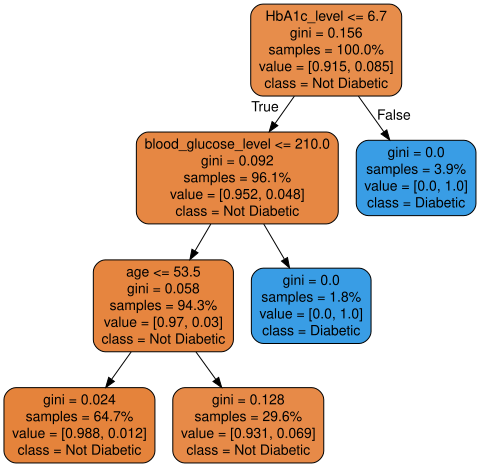

In [7]:
# 4. Xây dựng cây quyết định
# Chúng ta chọn max_depth=3 để cây dễ đọc
dt = tree.DecisionTreeClassifier(max_depth=3, random_state=24)
dt.fit(X_train, y_train)

# 5. Hiển thị cây quyết định với package graphviz
dot_data = tree.export_graphviz(dt,
                                out_file=None,
                                filled=True,
                                rounded=True,
                                feature_names=features_list, # Sử dụng list features
                                proportion=True,
                                class_names=['Not Diabetic', 'Diabetic']) # 0 và 1

graph = graphviz.Source(dot_data)

# Lệnh 'graph' sẽ hiển thị cây trong file notebook của bạn
print("Đang hiển thị Cây Quyết Định (max_depth=3)...")
graph

#### 2.1.4.6 NHIỆM VỤ 2: TỐI ƯU CÂY QUYẾT ĐỊNH (GridSearchCV) 
Sử dụng GridSearchCV để tìm ra max_depth (độ sâu) tốt nhất cho cây quyết định và vẽ biểu đồ Bias-Variance.

##### 1. Tạo cây quyết định và lưới tham số

In [8]:
# Xác định các giá trị tham số để thử
# Dữ liệu này phức tạp hơn, ta có thể thử nhiều độ sâu hơn
params = {'max_depth':[2, 4, 6, 8, 10, 12]} #parameters

# Khởi tạo mô hình cây (chưa huấn luyện)
dt_base = tree.DecisionTreeClassifier(random_state=24)

# Khởi tạo GridSearchCV
# cv=4 nghĩa là 4-fold cross-validation
cv_dt = GridSearchCV(dt_base, param_grid=params, scoring='roc_auc',
                     n_jobs=-1, refit=True, cv=4, verbose=1,
                     return_train_score=True)

print("Bắt đầu tìm tham số tối ưu cho Cây Quyết Định...")

Bắt đầu tìm tham số tối ưu cho Cây Quyết Định...


##### 2. Huấn luyện mô hình GridSearchCV

In [9]:
cv_dt.fit(X_train, y_train)
print("Hoàn thành!")

# In ra tham số tốt nhất
print(f"Tham số max_depth tốt nhất tìm được: {cv_dt.best_params_}")
print(f"Điểm ROC AUC tốt nhất (trên tập validation): {cv_dt.best_score_:.4f}")

Fitting 4 folds for each of 6 candidates, totalling 24 fits
Hoàn thành!
Tham số max_depth tốt nhất tìm được: {'max_depth': 10}
Điểm ROC AUC tốt nhất (trên tập validation): 0.9735


##### 3. Vẽ biểu đồ đánh giá (Bias-Variance) 
Vẽ biểu đồ so sánh điểm train và điểm test (validation) để xem mô hình bị overfit ở đâu.

Đang vẽ biểu đồ đánh giá max_depth...


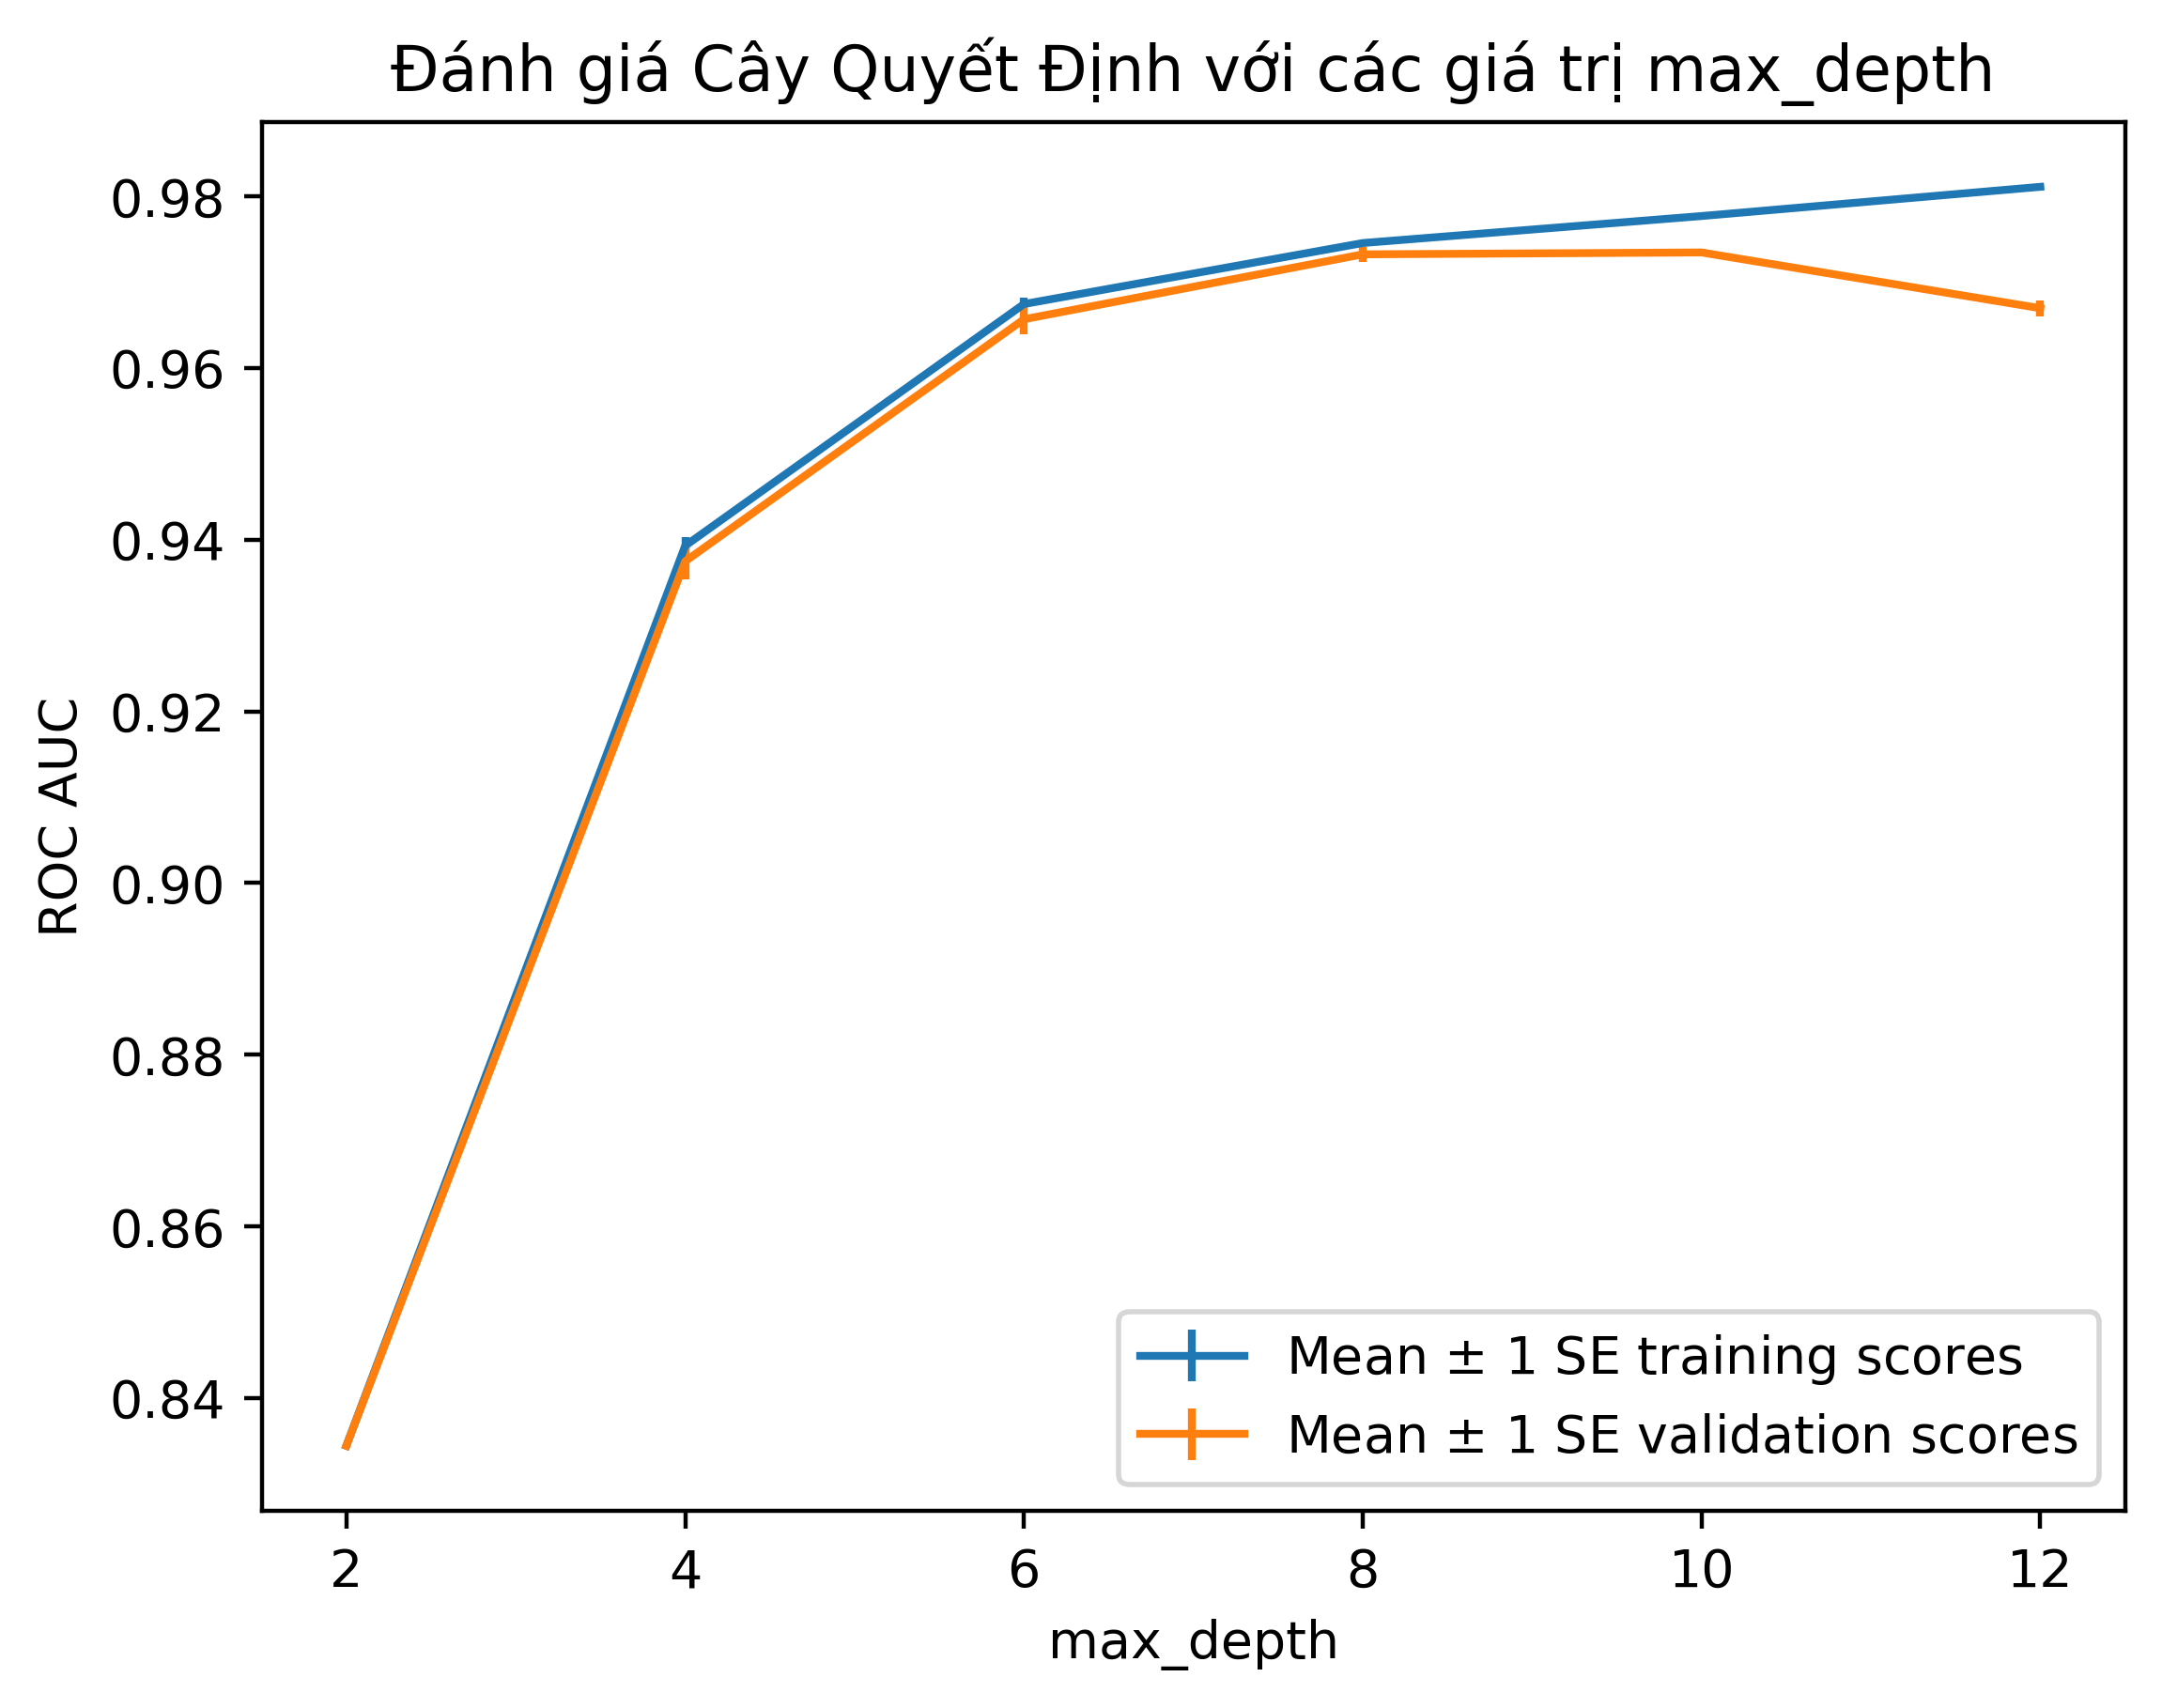

In [10]:
# Lấy kết quả từ GridSearchCV
cv_results_df = pd.DataFrame(cv_dt.cv_results_)

# Vẽ biểu đồ
print("Đang vẽ biểu đồ đánh giá max_depth...")
ax = plt.axes()
ax.errorbar(cv_results_df['param_max_depth'],
            cv_results_df['mean_train_score'],
            yerr=cv_results_df['std_train_score']/np.sqrt(4),
            label='Mean $\pm$ 1 SE training scores')
ax.errorbar(cv_results_df['param_max_depth'],
            cv_results_df['mean_test_score'],
            yerr=cv_results_df['std_test_score']/np.sqrt(4),
            label='Mean $\pm$ 1 SE validation scores') # 'test' ở đây là validation
ax.legend()
plt.xlabel('max_depth')
plt.ylabel('ROC AUC')
plt.title('Đánh giá Cây Quyết Định với các giá trị max_depth')
plt.show()

#### 2.1.4.7 NHIỆM VỤ 3: XÂY DỰNG RỪNG CÂY (Random Forest) 
Xây dựng mô hình Random Forest, dùng GridSearchCV để tìm `n_estimators` (số cây) tốt nhất, và xem xét mức độ quan trọng của các đặc trưng.

##### 1. Tạo rừng cây và lưới tham số

In [11]:
# Khởi tạo mô hình RF cơ sở (chưa huấn luyện)
# n_jobs=-1 để dùng tất cả CPU
rf_base = RandomForestClassifier(random_state=24, n_jobs=-1)

# Lưới tham số: tìm số lượng cây, từ 10 đến 100
rf_params_ex = {'n_estimators': list(range(10, 110, 10))} # [10, 20, ..., 100]

# Khởi tạo GridSearchCV
cv_rf_ex = GridSearchCV(rf_base, param_grid=rf_params_ex,
                        scoring='roc_auc', n_jobs=-1,
                        refit=True, cv=4, verbose=1,
                        return_train_score=True)

print("Bắt đầu tìm tham số tối ưu cho Rừng Cây...")

Bắt đầu tìm tham số tối ưu cho Rừng Cây...


##### 2. Huấn luyện mô hình GridSearchCV

In [12]:
cv_rf_ex.fit(X_train, y_train)
print("Hoàn thành!")

# In ra tham số tốt nhất
print(f"Tham số n_estimators tốt nhất tìm được: {cv_rf_ex.best_params_}")
print(f"Điểm ROC AUC tốt nhất (trên tập validation): {cv_rf_ex.best_score_:.4f}")

Fitting 4 folds for each of 10 candidates, totalling 40 fits
Hoàn thành!
Tham số n_estimators tốt nhất tìm được: {'n_estimators': 100}
Điểm ROC AUC tốt nhất (trên tập validation): 0.9616


### 3. Vẽ biểu đồ đánh giá (Thời gian vs Hiệu suất) 
Vẽ 2 biểu đồ: Thời gian huấn luyện và Điểm ROC AUC theo số lượng cây.

Đang vẽ biểu đồ đánh giá n_estimators...


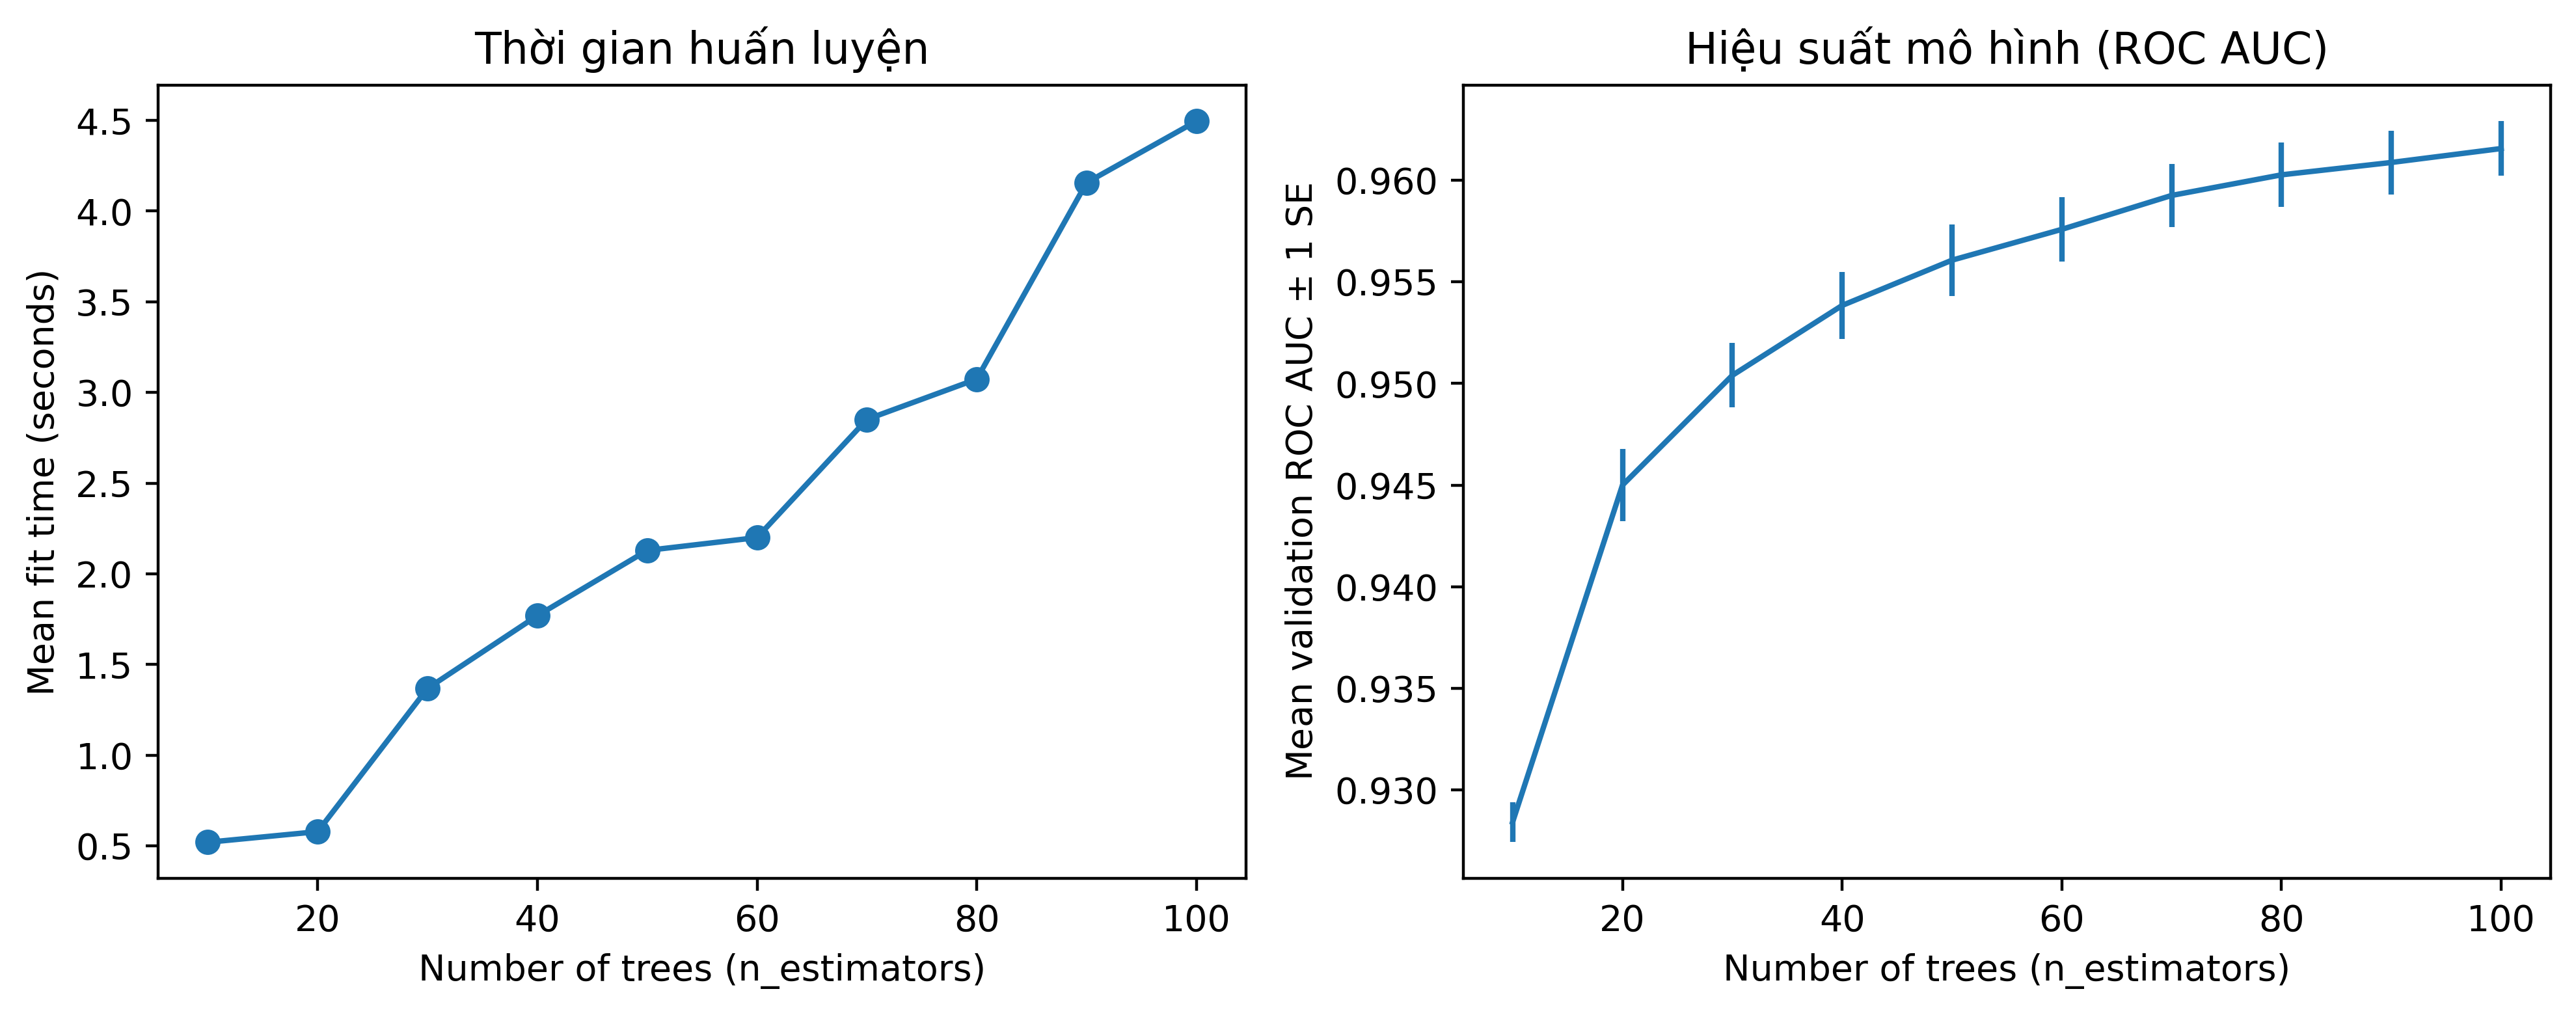

In [13]:
# Lấy kết quả
cv_rf_ex_results_df = pd.DataFrame(cv_rf_ex.cv_results_)

print("Đang vẽ biểu đồ đánh giá n_estimators...")
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

# Biểu đồ 1: Thời gian huấn luyện
axs[0].plot(cv_rf_ex_results_df['param_n_estimators'],
            cv_rf_ex_results_df['mean_fit_time'],
            '-o')
axs[0].set_xlabel('Number of trees (n_estimators)')
axs[0].set_ylabel('Mean fit time (seconds)')
axs[0].set_title('Thời gian huấn luyện')

# Biểu đồ 2: Điểm ROC AUC
axs[1].errorbar(cv_rf_ex_results_df['param_n_estimators'],
                cv_rf_ex_results_df['mean_test_score'],
                yerr=cv_rf_ex_results_df['std_test_score']/np.sqrt(4))
axs[1].set_xlabel('Number of trees (n_estimators)')
axs[1].set_ylabel('Mean validation ROC AUC $\pm$ 1 SE')
axs[1].set_title('Hiệu suất mô hình (ROC AUC)')

plt.tight_layout()
plt.show()

##### 4. Xem mức độ quan trọng của đặc trưng (Feature Importance) 
Lấy mô hình Random Forest tốt nhất (đã được refit) và xem đặc trưng nào quan trọng nhất.

Đang vẽ biểu đồ Feature Importance...


<Figure size 4000x2800 with 0 Axes>

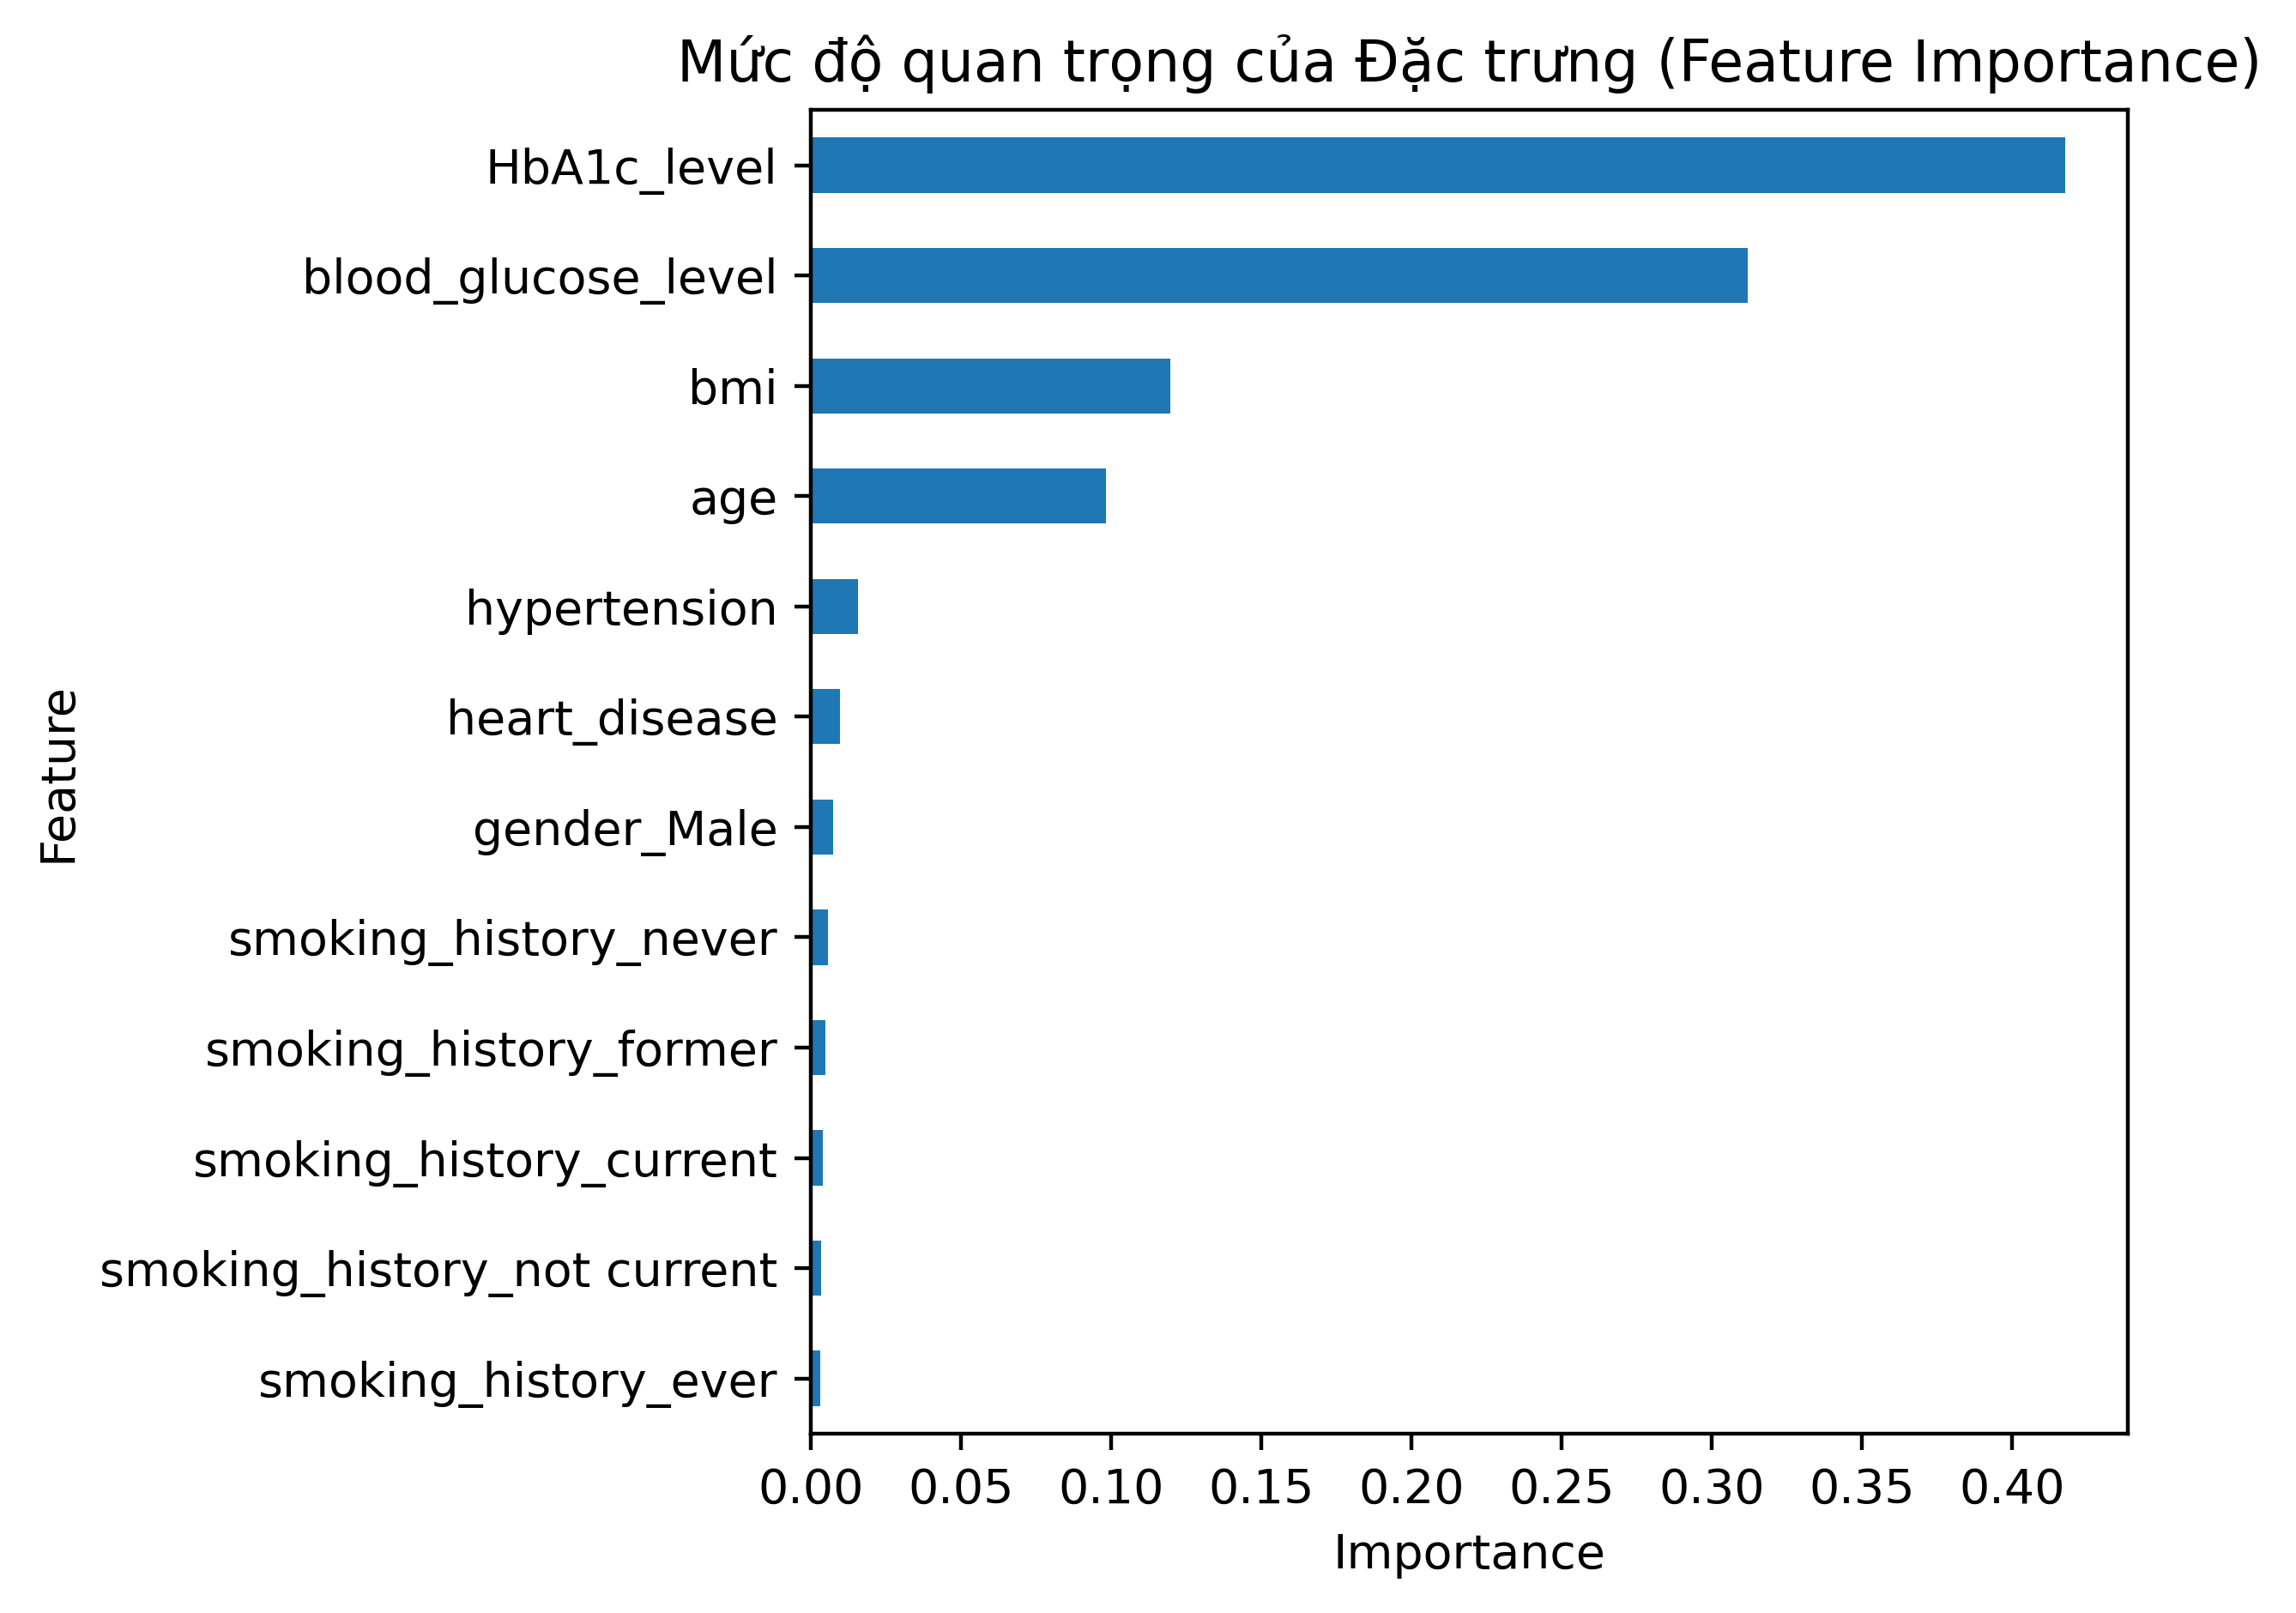

In [14]:
# Lấy ra mô hình tốt nhất
best_rf_model = cv_rf_ex.best_estimator_

# Lấy ra mức độ quan trọng
feat_imp_df = pd.DataFrame({
    'Importance': best_rf_model.feature_importances_},
    index=features_list) # Sử dụng list features

# Sắp xếp và vẽ biểu đồ
print("Đang vẽ biểu đồ Feature Importance...")
# Tăng kích thước biểu đồ để chứa được nhiều feature
plt.figure(figsize=(10, 7)) 
feat_imp_df.sort_values('Importance', ascending=True).plot.barh(legend=False)
plt.title('Mức độ quan trọng của Đặc trưng (Feature Importance)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 2.2. GIẢI THUẬT 2: SUPPORT VECTOR MACHINE (SVM)

### 2.2.1. Ôn tập lý thuyết

#### + Giải thuật Support Vector Machine hoạt động như thế nào? Hãy giải thích khái niệm về ranh giới phân tách (hyperplane) và lề (margin)

**Support Vector Machine (SVM)** là một thuật toán học máy có giám sát mạnh mẽ, có thể được sử dụng cho cả bài toán phân loại và hồi quy. Tuy nhiên, nó được biết đến nhiều nhất với vai trò phân loại.  

**Ý tưởng cốt lõi**: Mục tiêu của SVM là tìm ra một ranh giới phân tách (hyperplane) "tốt nhất" để chia dữ liệu thành các lớp riêng biệt.  

- **Ranh giới phân tách (Hyperplane)**: Đây là "đường" (hoặc mặt phẳng, hoặc siêu mặt phẳng) dùng để phân chia không gian dữ liệu.  

    - Trong không gian 2 chiều (2 features), nó là một đường thẳng.  
    
    - Trong không gian 3 chiều (3 features), nó là một mặt phẳng.  
    
    - Trong không gian $N$ chiều, nó được gọi là siêu mặt phẳng (hyperplane).  
    
- **Lề (Margin)**: SVM không chỉ tìm bất kỳ đường nào có thể chia dữ liệu. Nó tìm đường mang lại khoảng cách lớn nhất từ đường đó đến các điểm dữ liệu gần nhất của mỗi lớp. Khoảng cách này được gọi là lề (margin).

SVM tìm cách tối đa hóa lề (maximizing the margin). Một lề rộng hơn đồng nghĩa với việc mô hình tự tin hơn vào quyết định phân loại của mình và có khả năng tổng quát hóa tốt hơn trên dữ liệu mới.

#### + Các vector hỗ trợ (support vectors) có vai trò gì trong SVM? Tại sao chúng quan trọng?

**Vector Hỗ trợ (Support Vectors)** là các điểm dữ liệu nằm gần nhất với ranh giới phân tách (hyperplane). Chúng chính là các điểm nằm trên các đường biên của lề (margin).

**Vai trò và Tầm quan trọng**:

1. **Định nghĩa lề (Margin)**: Chúng là những điểm duy nhất quyết định vị trí và độ rộng của hyperplane và margin. Nếu bạn di chuyển các điểm dữ liệu khác (không phải support vectors), ranh giới sẽ không thay đổi. Nhưng nếu bạn di chuyển một support vector, ranh giới sẽ thay đổi theo.

2. **Tiết kiệm bộ nhớ**: SVM là một thuật toán "tiết kiệm". Sau khi huấn luyện, nó chỉ cần lưu trữ thông tin về các support vectors này để đưa ra dự đoán cho dữ liệu mới, chứ không cần toàn bộ tập dữ liệu.

3. **Xử lý Outliers (với lề mềm)**: Trong SVM lề mềm, một số support vector có thể nằm bên trong lề hoặc thậm chí nằm sai phía của ranh giới.

#### + Sự khác biệt giữa SVM với lề cứng (hard margin) và lề mềm (soft margin) là gì? Khi nào nên sử dụng lề mềm?

1. **SVM Lề cứng (Hard Margin)**:

- **Điều kiện**: Yêu cầu tất cả các điểm dữ liệu phải được phân loại chính xác và nằm ngoài lề (không có điểm nào được phép nằm trong lề).

- **Khi nào dùng**: Chỉ hoạt động khi dữ liệu có thể được phân tách một cách tuyến tính và hoàn hảo (linearly separable).

- **Vấn đề**: Rất nhạy cảm với outliers (điểm nhiễu). Chỉ cần một outlier, mô hình có thể thất bại (không tìm được lề) hoặc tạo ra một lề rất hẹp và tổng quát hóa kém.

2. **SVM Lề mềm (Soft Margin)**:

- **Điều kiện**: Cho phép một số điểm dữ liệu "vi phạm" lề. Tức là một số điểm có thể nằm bên trong lề hoặc thậm chí nằm sai phía của ranh giới.

- **Cơ chế**: Nó đưa vào một tham số C (chúng ta sẽ nói ở dưới) để tạo ra sự cân bằng:

    - Cố gắng giữ lề rộng nhất có thể.

    - Đồng thời cố gắng giảm thiểu số lượng các điểm vi phạm (misclassifications).

**Khi nào dùng**: Hầu như luôn luôn. Dữ liệu trong thế giới thực hiếm khi nào sạch và tách biệt hoàn hảo. Lề mềm giúp mô hình linh hoạt hơn, chống overfitting và xử lý tốt hơn với nhiễu và outliers.

#### + Hàm nhân (kernel) trong SVM là gì? Hãy giải thích các loại kernel phổ biến (linear, polynomial, RBF) và khi nào nên sử dụng chúng

**Vấn đề**: Dữ liệu thường không thể phân tách bằng một đường thẳng (non-linearly separable).

**Giải pháp (Kernel Trick)**: Thay vì tìm một đường cong phức tạp, hàm nhân (kernel) thực hiện một "mánh khóe": nó "chiếu" (project) dữ liệu của bạn lên một không gian có số chiều cao hơn, nơi dữ liệu có thể được phân tách bằng một siêu mặt phẳng (đường thẳng).

Nó tính toán sự tương đồng giữa các điểm trong không gian mới này mà không cần thực sự tạo ra các chiều mới đó, giúp tiết kiệm chi phí tính toán.

**Các loại Kernel phổ biến**:

1. **Linear (Tuyến tính)**: `kernel='linear'`

    - **Ý nghĩa**: Đây là SVM ở dạng cơ bản nhất, không có phép chiếu nào cả. Nó tìm một đường thẳng (siêu mặt phẳng) trong không gian ban đầu.

    - **Khi dùng**: Khi bạn tin rằng dữ liệu của mình đã gần như tuyến tính, hoặc khi số lượng đặc trưng (features) là rất lớn (ví dụ: dữ liệu văn bản).

2. Polynomial (Đa thức): `kernel='poly'`

    - **Ý nghĩa**: Tạo ra ranh giới dạng đa thức (cong). Có thêm tham số degree (bậc của đa thức) để kiểm soát độ cong.

    - **Khi dùng**: Thường dùng trong xử lý ảnh. Ít phổ biến hơn RBF.

3. RBF (Radial Basis Function): `kernel='rbf'`

    - **Ý nghĩa**: Đây là kernel mạnh mẽ và phổ biến nhất. Nó hoạt động bằng cách xem xét "khoảng cách" của các điểm đến nhau, tạo ra các ranh giới rất linh hoạt, có thể coi như nó chiếu dữ liệu lên không gian vô hạn chiều.

    - **Khi dùng**: Đây thường là lựa chọn mặc định khi bạn không biết rõ về dữ liệu của mình. Nó hoạt động tốt trên hầu hết các tập dữ liệu phi tuyến.

#### + Tham số C trong SVM có ý nghĩa gì? Nó ảnh hưởng như thế nào đến hiệu suất của mô hình?

Tham số `C` (còn gọi là tham số chính quy hóa - Regularization Parameter) là tham số mấu chốt trong **SVM lề mềm (Soft Margin)**.

Nó kiểm soát sự **cân bằng (trade-off)** giữa hai mục tiêu:

1. **Tối đa hóa lề (Margin)**: (Mong muốn lề càng rộng càng tốt)

2. **Giảm thiểu lỗi phân loại**: (Mong muốn càng ít điểm vi phạm lề càng tốt)

- **`C` nhỏ** (ví dụ: 0.1):

    - Ưu tiên Lề RỘNG (tổng quát hóa tốt).

    - Cho phép nhiều điểm vi phạm lề hơn.

    - Mô hình "mềm" hơn, chấp nhận sai sót (có thể gây underfitting).

- **`C` lớn** (ví dụ: 100):

    - Ưu tiên Phân loại ĐÚNG (giảm lỗi).

    - Mô hình sẽ cố gắng phân loại đúng tất cả các điểm, kể cả outliers.

    - Kết quả là Lề HẸP hơn.

    - Mô hình "cứng" hơn, nhạy cảm với nhiễu (có thể gây overfitting).

#### + Viết đoạn code mẫu bằng Python (sử dụng Scikit-learn) để xây dựng một mô hình SVM cho bài toán phân loại không? Hãy mô tả các bước thực hiện

In [15]:
# Bước 1: Import các thư viện cần thiết
import pandas as pd
from sklearn.datasets import load_iris # Dùng dataset mẫu Iris
from sklearn.model_selection import train_test_split # Để chia dữ liệu
from sklearn.preprocessing import StandardScaler # (Rất quan trọng) Để chuẩn hóa
from sklearn.svm import SVC # Support Vector Classifier
from sklearn.metrics import accuracy_score # Để đánh giá

# Bước 2: Tải và chuẩn bị dữ liệu
iris = load_iris()
X = iris.data
y = iris.target

# Chỉ lấy 2 lớp (0 và 1) và 2 đặc trưng (0 và 1) cho ví dụ đơn giản
X = X[y != 2, :2]
y = y[y != 2]

# Bước 3: Chia dữ liệu (Train/Test Split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Bước 4: (RẤT QUAN TRỌNG) Chuẩn hóa dữ liệu
# SVM rất nhạy cảm với tỉ lệ (scale) của dữ liệu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Chỉ .transform() tập test

# Bước 5: Khởi tạo và Huấn luyện mô hình SVM
# Chúng ta dùng kernel='rbf' (phổ biến) và C=1.0 (mặc định)
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)

# Huấn luyện trên dữ liệu đã chuẩn hóa
svm_model.fit(X_train_scaled, y_train)

print("Đã huấn luyện xong mô hình SVM!")

# Bước 6: Đưa ra dự đoán trên tập test (đã chuẩn hóa)
y_pred = svm_model.predict(X_test_scaled)

# Bước 7: Đánh giá mô hình
accuracy = accuracy_score(y_test, y_pred)
print(f"Độ chính xác trên tập Test: {accuracy * 100:.2f}%")

Đã huấn luyện xong mô hình SVM!
Độ chính xác trên tập Test: 100.00%


#### + Hàm nào trong Scikit-learn để chuẩn hóa dữ liệu (scaling) trước khi áp dụng SVM? Tại sao bước này quan trọng?

**Hàm phổ biến nhất**: `sklearn.preprocessing.StandardScaler`

- **Cách hoạt động**: `StandardScaler` biến đổi dữ liệu sao cho mỗi đặc trưng (cột) có giá trị trung bình (mean) = 0 và phương sai (variance) = 1.

- **Các hàm khác**: `MinMaxScaler` (đưa về khoảng [0, 1]) cũng hay được sử dụng.

`Tại sao chuẩn hóa lại QUAN TRỌNG với SVM?` SVM hoạt động dựa trên việc tính toán khoảng cách giữa các điểm dữ liệu để tìm ra lề (margin) lớn nhất.

Hãy tưởng tượng bạn có 2 đặc trưng:

1. `Tuổi` (giá trị từ 18 đến 80)

2. `Giới tính` (giá trị 0 hoặc 1)

Nếu không chuẩn hóa, trục `Tuổi` (với khoảng giá trị lớn) sẽ "lấn át" hoàn toàn trục `Giới tính` (với khoảng giá trị nhỏ) khi tính toán khoảng cách. Mô hình sẽ gần như bỏ qua đặc trưng `Giới tính`.

**Chuẩn hóa** đảm bảo rằng tất cả các đặc trưng đều có "trọng lượng" như nhau và đóng góp công bằng vào việc tìm ra ranh giới phân tách tốt nhất.

### 2.2.2. Bài làm mẫu

#### Bài toán 1: Thực hiện các nhiệm vụ trong bài toán 1 để xây dựng mô hình với giải thuật SVM cho dữ liệu
Iris-data lấy từ https://www.kaggle.com/code/xvivancos/tutorial-knn-in-the-iris-data-set

##### Nhiệm vụ 1: Xây dựng mô hình SVM để phân loại các loài hoa cẩm chướng

1. Tải dữ liệu về, nạp dữ liệu, xem thông tin các feature có trong tập dữ liệu và chuẩn bị dữ liệu cho xây
dựng mô hình

In [16]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split

# Download&Load dữ liệu iris từ datasets của scikit-learn
iris = datasets.load_iris()

# Hiển thị mô ta dữ liệu, chỉ có trong các bộ dữ liệu chuẩn và mở để học tập và nghiên cứu
print(iris.DESCR)

# Từ tập dữ liệu ban đầu, tách lấy ma trận biểu diễn các đặc trưng và nhãn.
data = iris.data
target = iris.target

# TODO: Chia dữ liệu và nhãn thành 2 tập dữ liệu huấn luyện và dữ liệu kiểm tra theo tỉ lệ 80:20
X_train, X_test, y_train, y_test = train_test_split(data, target,
                                                    test_size=0.2, random_state=101)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

2. Tạo mô hình SVM với dữ liệu đã chuẩn bị

In [17]:
from sklearn import svm

# khởi tạo mô hình phân lớp
clf = svm.SVC()

# Sử dụng phương thức 'fit' để huấn luyện mô hình với dữ liệu huấn luyện và nhãn huấn luyện
# fit (X,Y) với X là tập các đối tượng, Y là tập nhãn tương ứng của đối tượng.
clf.fit(X_train, y_train)

SVC()

3. Đánh giá độ chính xác của mô hình

In [18]:
# Tính độ chính xác trên tập huấn luyện và tập kiểm tra
train_acc = clf.score(X_train,y_train)
val_acc = clf.score(X_test,y_test)

print('Training accuracy: {}'.format(train_acc))
print('Validation accuracy: {}'.format(val_acc))

Training accuracy: 0.95
Validation accuracy: 0.9666666666666667


4. Tìm tham số kernel tối ưu cho mô hình SVM

In [19]:
# best_svm, best_val_acc và best_kernel lần lượt là các biến lưu mô hình tốt nhất,
# độ chính xác cao nhất trên tập kiểm tra và kernel tốt nhất
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
best_svm = None
best_val_acc = -1
best_kernel = None

# Huấn luyện các mô hình dựa trên dữ liệu huấn luyện và tham số kernel
# Tính toán độ chính xác trên tập huấn luyện và tập kiểm tra để tìm được mô hình tốt nhất
for i in range(4):
    clf = svm.SVC(kernel=kernels[i], probability=True)
    clf.fit(X_train, y_train)
    tmp_val_acc = clf.score(X_test, y_test)
    if (tmp_val_acc > best_val_acc):
        best_val_acc = tmp_val_acc
        best_svm = clf
        best_kernel = kernels[i]
        
# Hiển thị mô hình tốt nhất cùng với độ chính xác
print("Best validation accuracy : {} with kernel: {}".format(best_val_acc,
best_kernel))
# Mô hình tốt nhất của bạn nên có độ chính xác xấp xỉ 86,67%

Best validation accuracy : 1.0 with kernel: linear


#### **Bài toán 2**: Xây dựng mô hình dựa vào giải thuật SVM trên dữ liệu hình ảnh Handwritten-Digit-MNIST-SVM. 
Dữ liệu lấy từ https://www.kaggle.com/code/nishan192/mnist-digit-recognition-using-svm

##### Nhiệm vụ 1: Tìm hiểu về cách biểu diễn và hiển thị các ảnh từ tập dữ liệu là hình ảnh

1. Import thư viện và tải dữ liệu là tập các hình ảnh viết tay từ số 0 đến số 9

In [22]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
digits = load_digits(n_class=10)

2. Khảo sát thông tin có trong digits

In [21]:
#thông tin toàn bộ dữ liệu đã tải về
digits

#xem thông tin của một hình dưới dạng ma trận 8 x 8
digits['data'][0].reshape(8,8)

#xem thông tin của một hình dưới dạng mảng
digits['data'][0]

#xem thông tin 9 nhãn đầu tiên
digits['target'][0:9]

array([0, 1, 2, 3, 4, 5, 6, 7, 8])

3. Vẽ ra hình dựa vào dữ liệu dạng ma trận 8 x 8

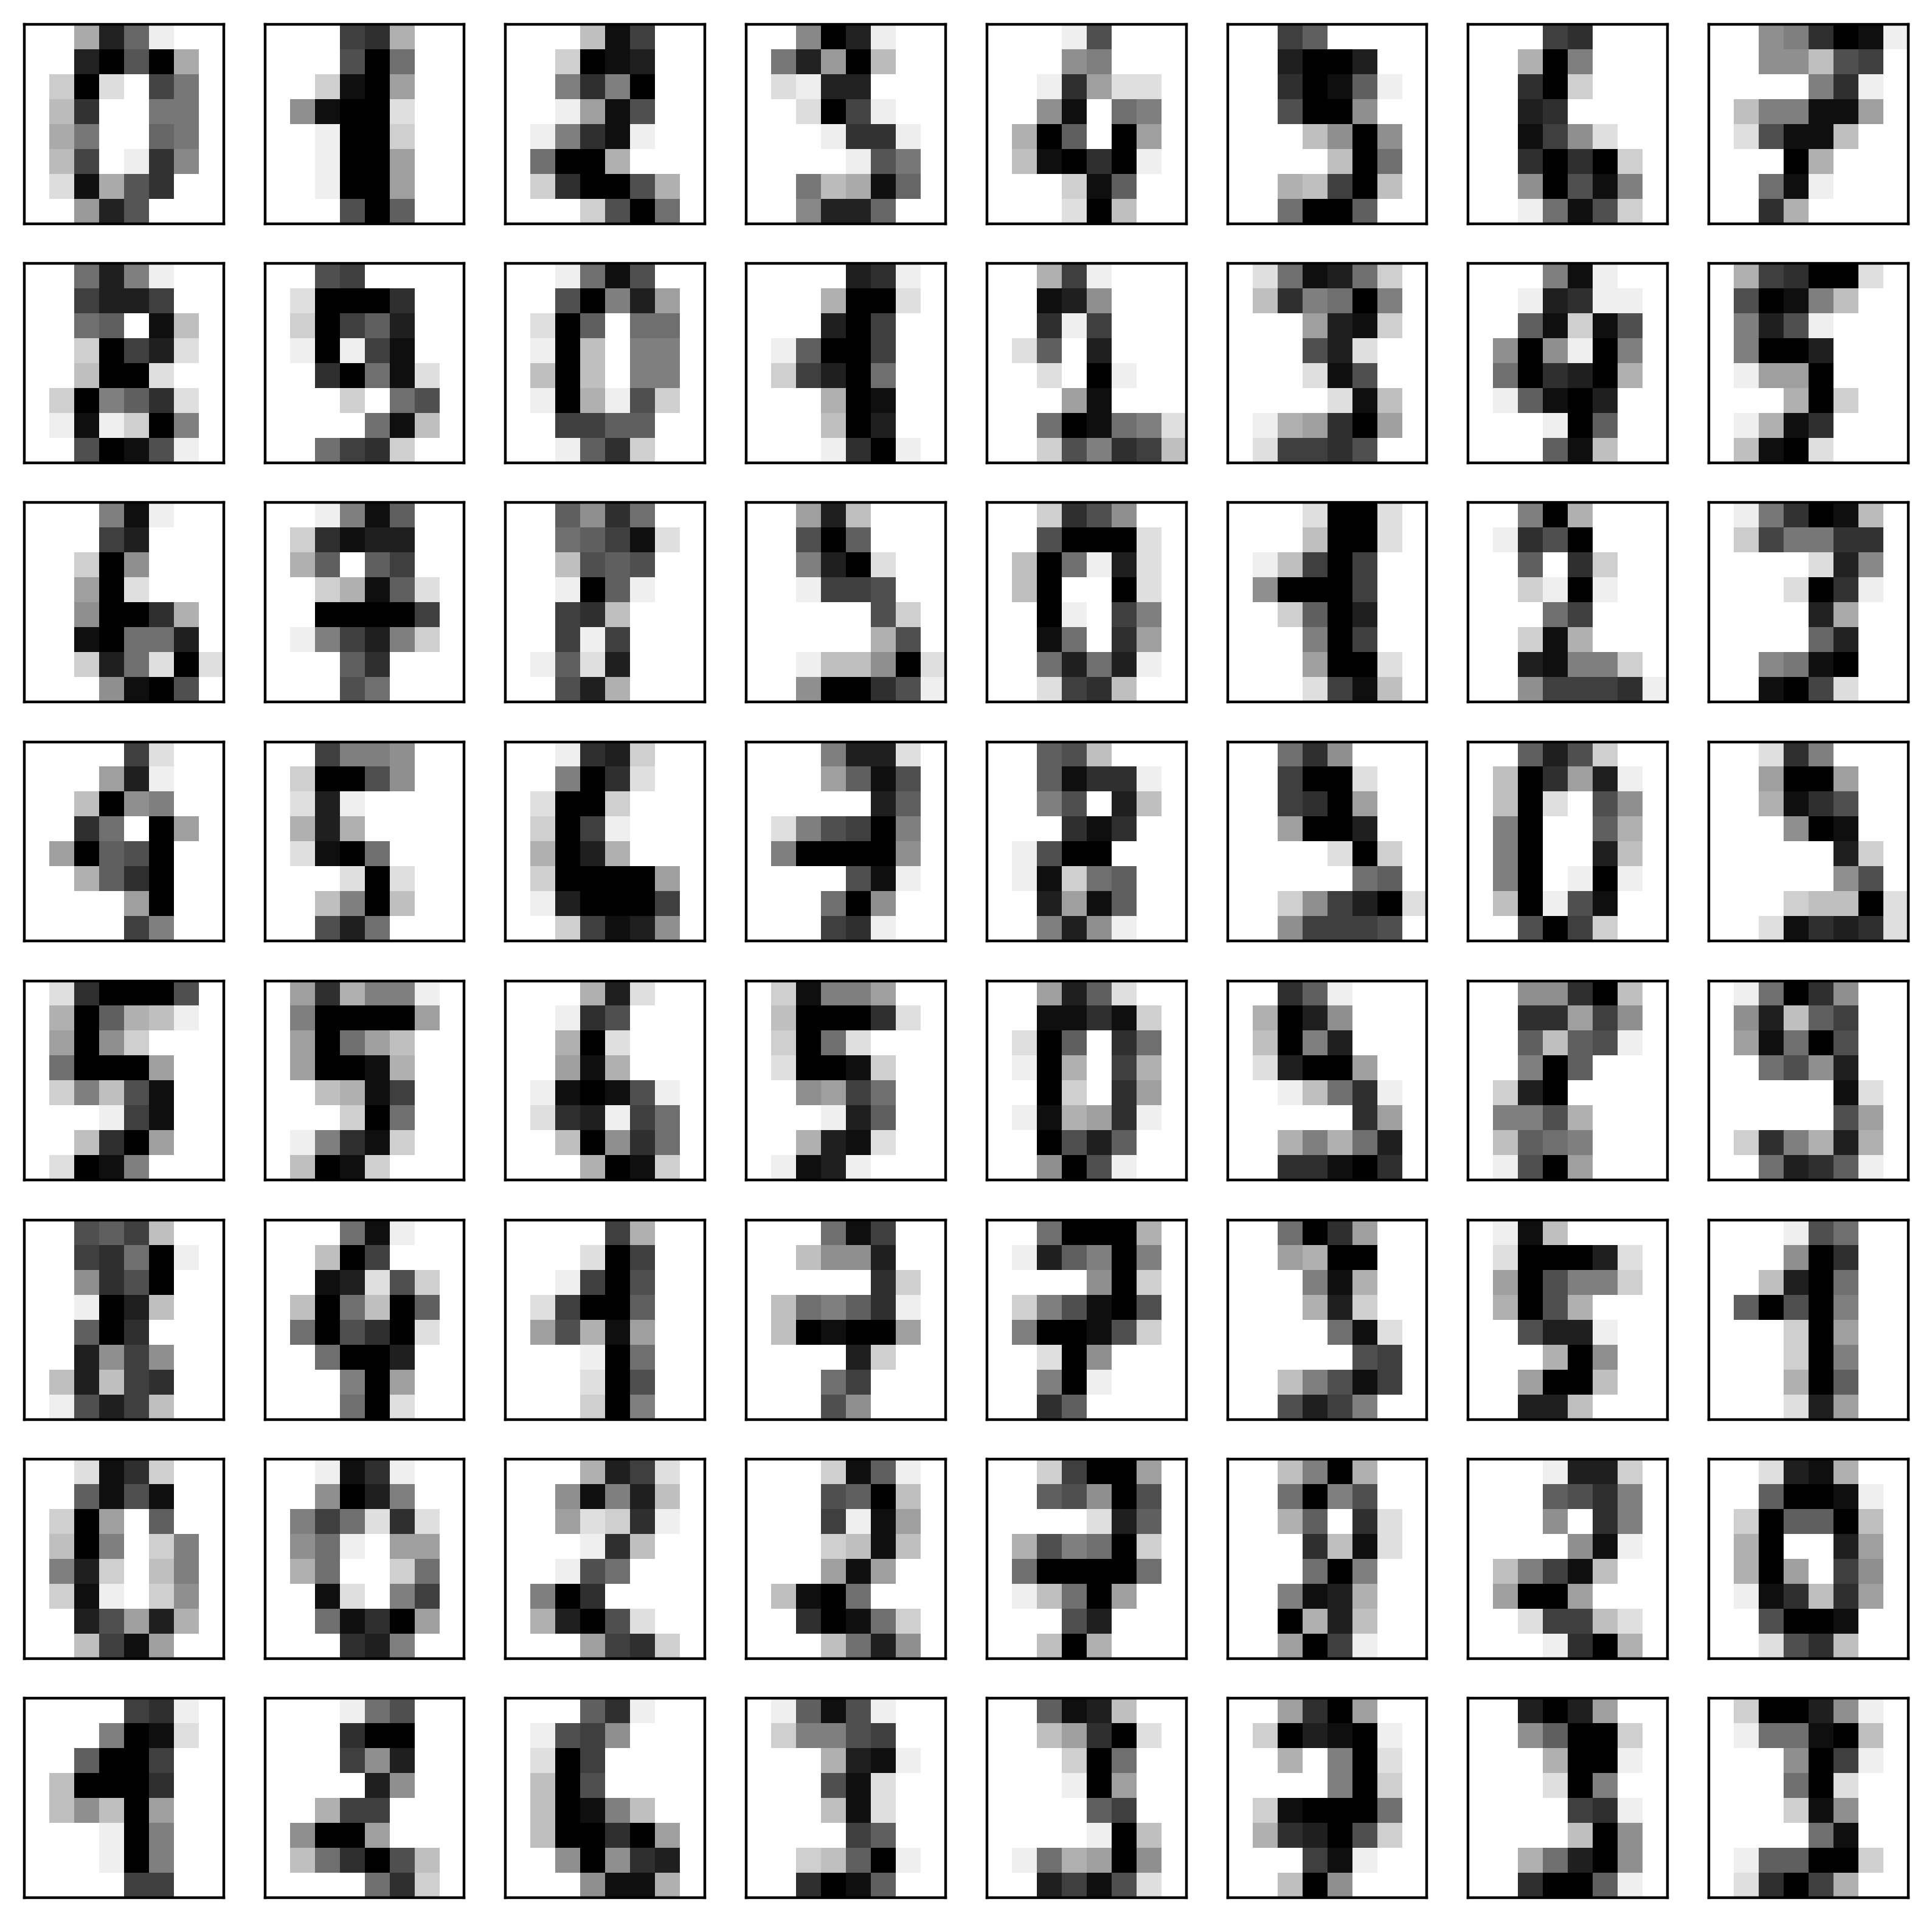

In [23]:
# Each Digit is represented in digits.images as a matrix of 8x8 = 64 pixels. Each of the 64 values represent
# a greyscale. The Greyscale are then plotted in the right scale by the imshow method.
fig, ax = plt.subplots(8,8, figsize=(10,10))
for i, axi in enumerate(ax.flat):
    axi.imshow(digits.images[i], cmap='binary')
    axi.set(xticks=[], yticks=[])

4. Vẽ một ảnh từ ma trận 8 x 8

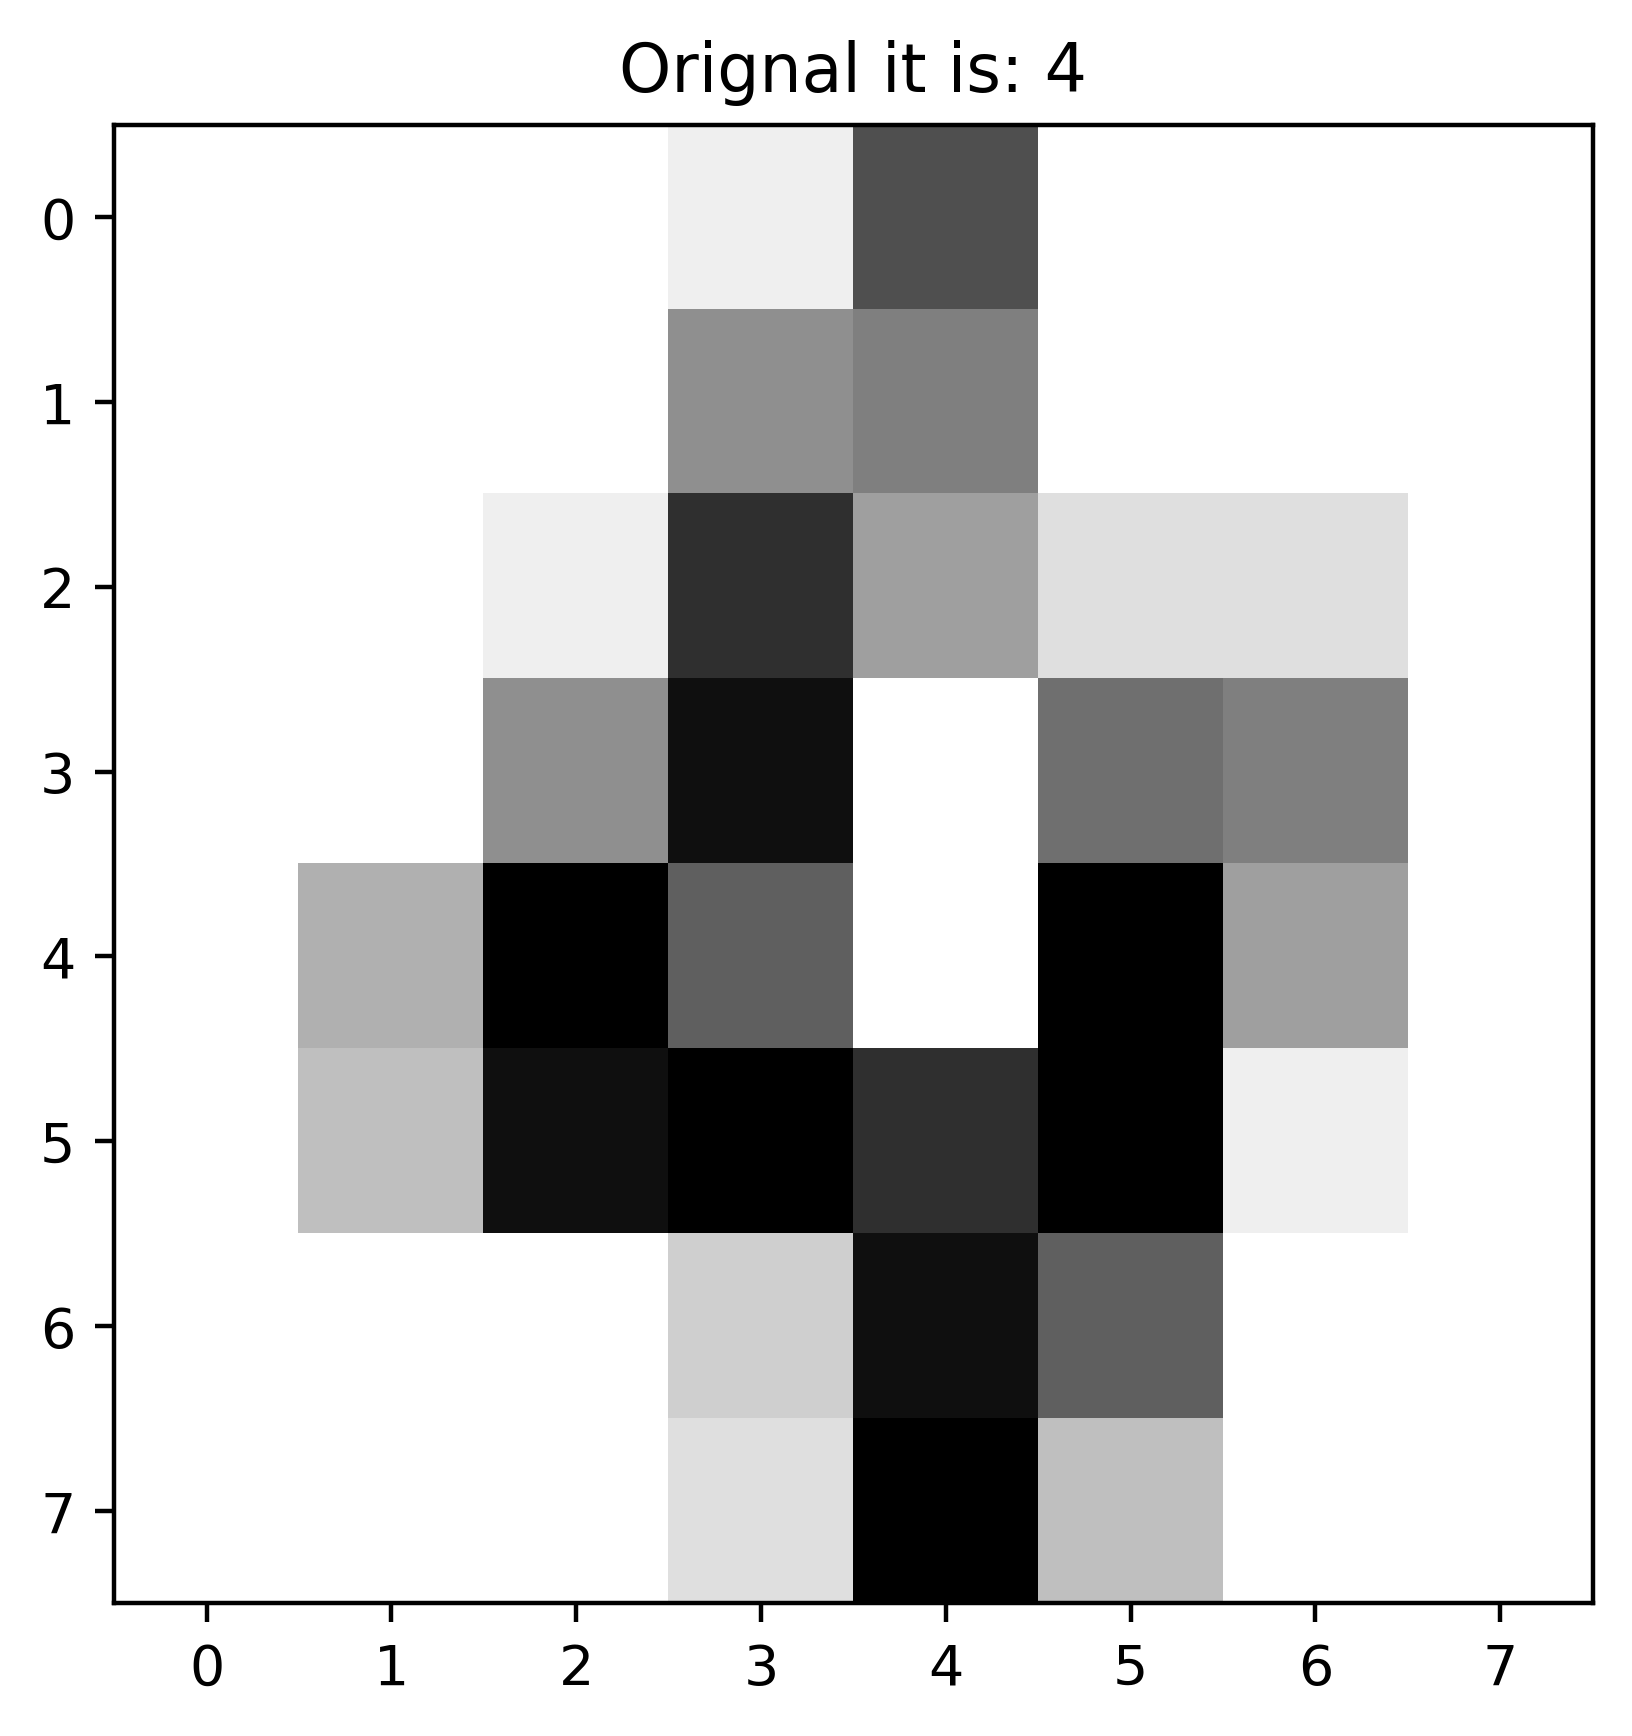

In [24]:
# Hàm vẽ 1 ảnh có kích thước 8 x 8 (ảnh lấy từ ma images)
def view_digit(index):
    plt.imshow(digits.images[index] , cmap = plt.cm.gray_r)
    plt.title('Orignal it is: '+ str(digits.target[index]))
    plt.show()

# vẽ ảnh ở vị trí thứ 4
view_digit(4)

##### Nhiệm vụ 2: Xây dựng mô hình SVM để nhận diện chữ viết tay từ 0 – 9

1. Chuẩn bị dữ liệu và xây dựng mô hình SVM

In [25]:
# Thực hiện import các thư viện cần thiết để xây dựng mô hình SVM
# Thực hiện bước 1 của nhiệm vụ 1
from sklearn import svm

main_data = digits['data']
targets = digits['target']
svc = svm.SVC(gamma=0.001 , C = 100)

# GAMMA is a parameter for non linear hyperplanes.
# The higher the gamma value it tries to exactly fit the training data set
# C is the penalty parameter of the error term.
# It controls the trade off between smooth decision boundary and classifying the training points correctly.
svc.fit(main_data[:1500] , targets[:1500])
predictions = svc.predict(main_data[1501:])
# list(zip(predictions , targets[1501:]))

2. Đánh giá hiệu quả của mô hình với Confusion Matrix

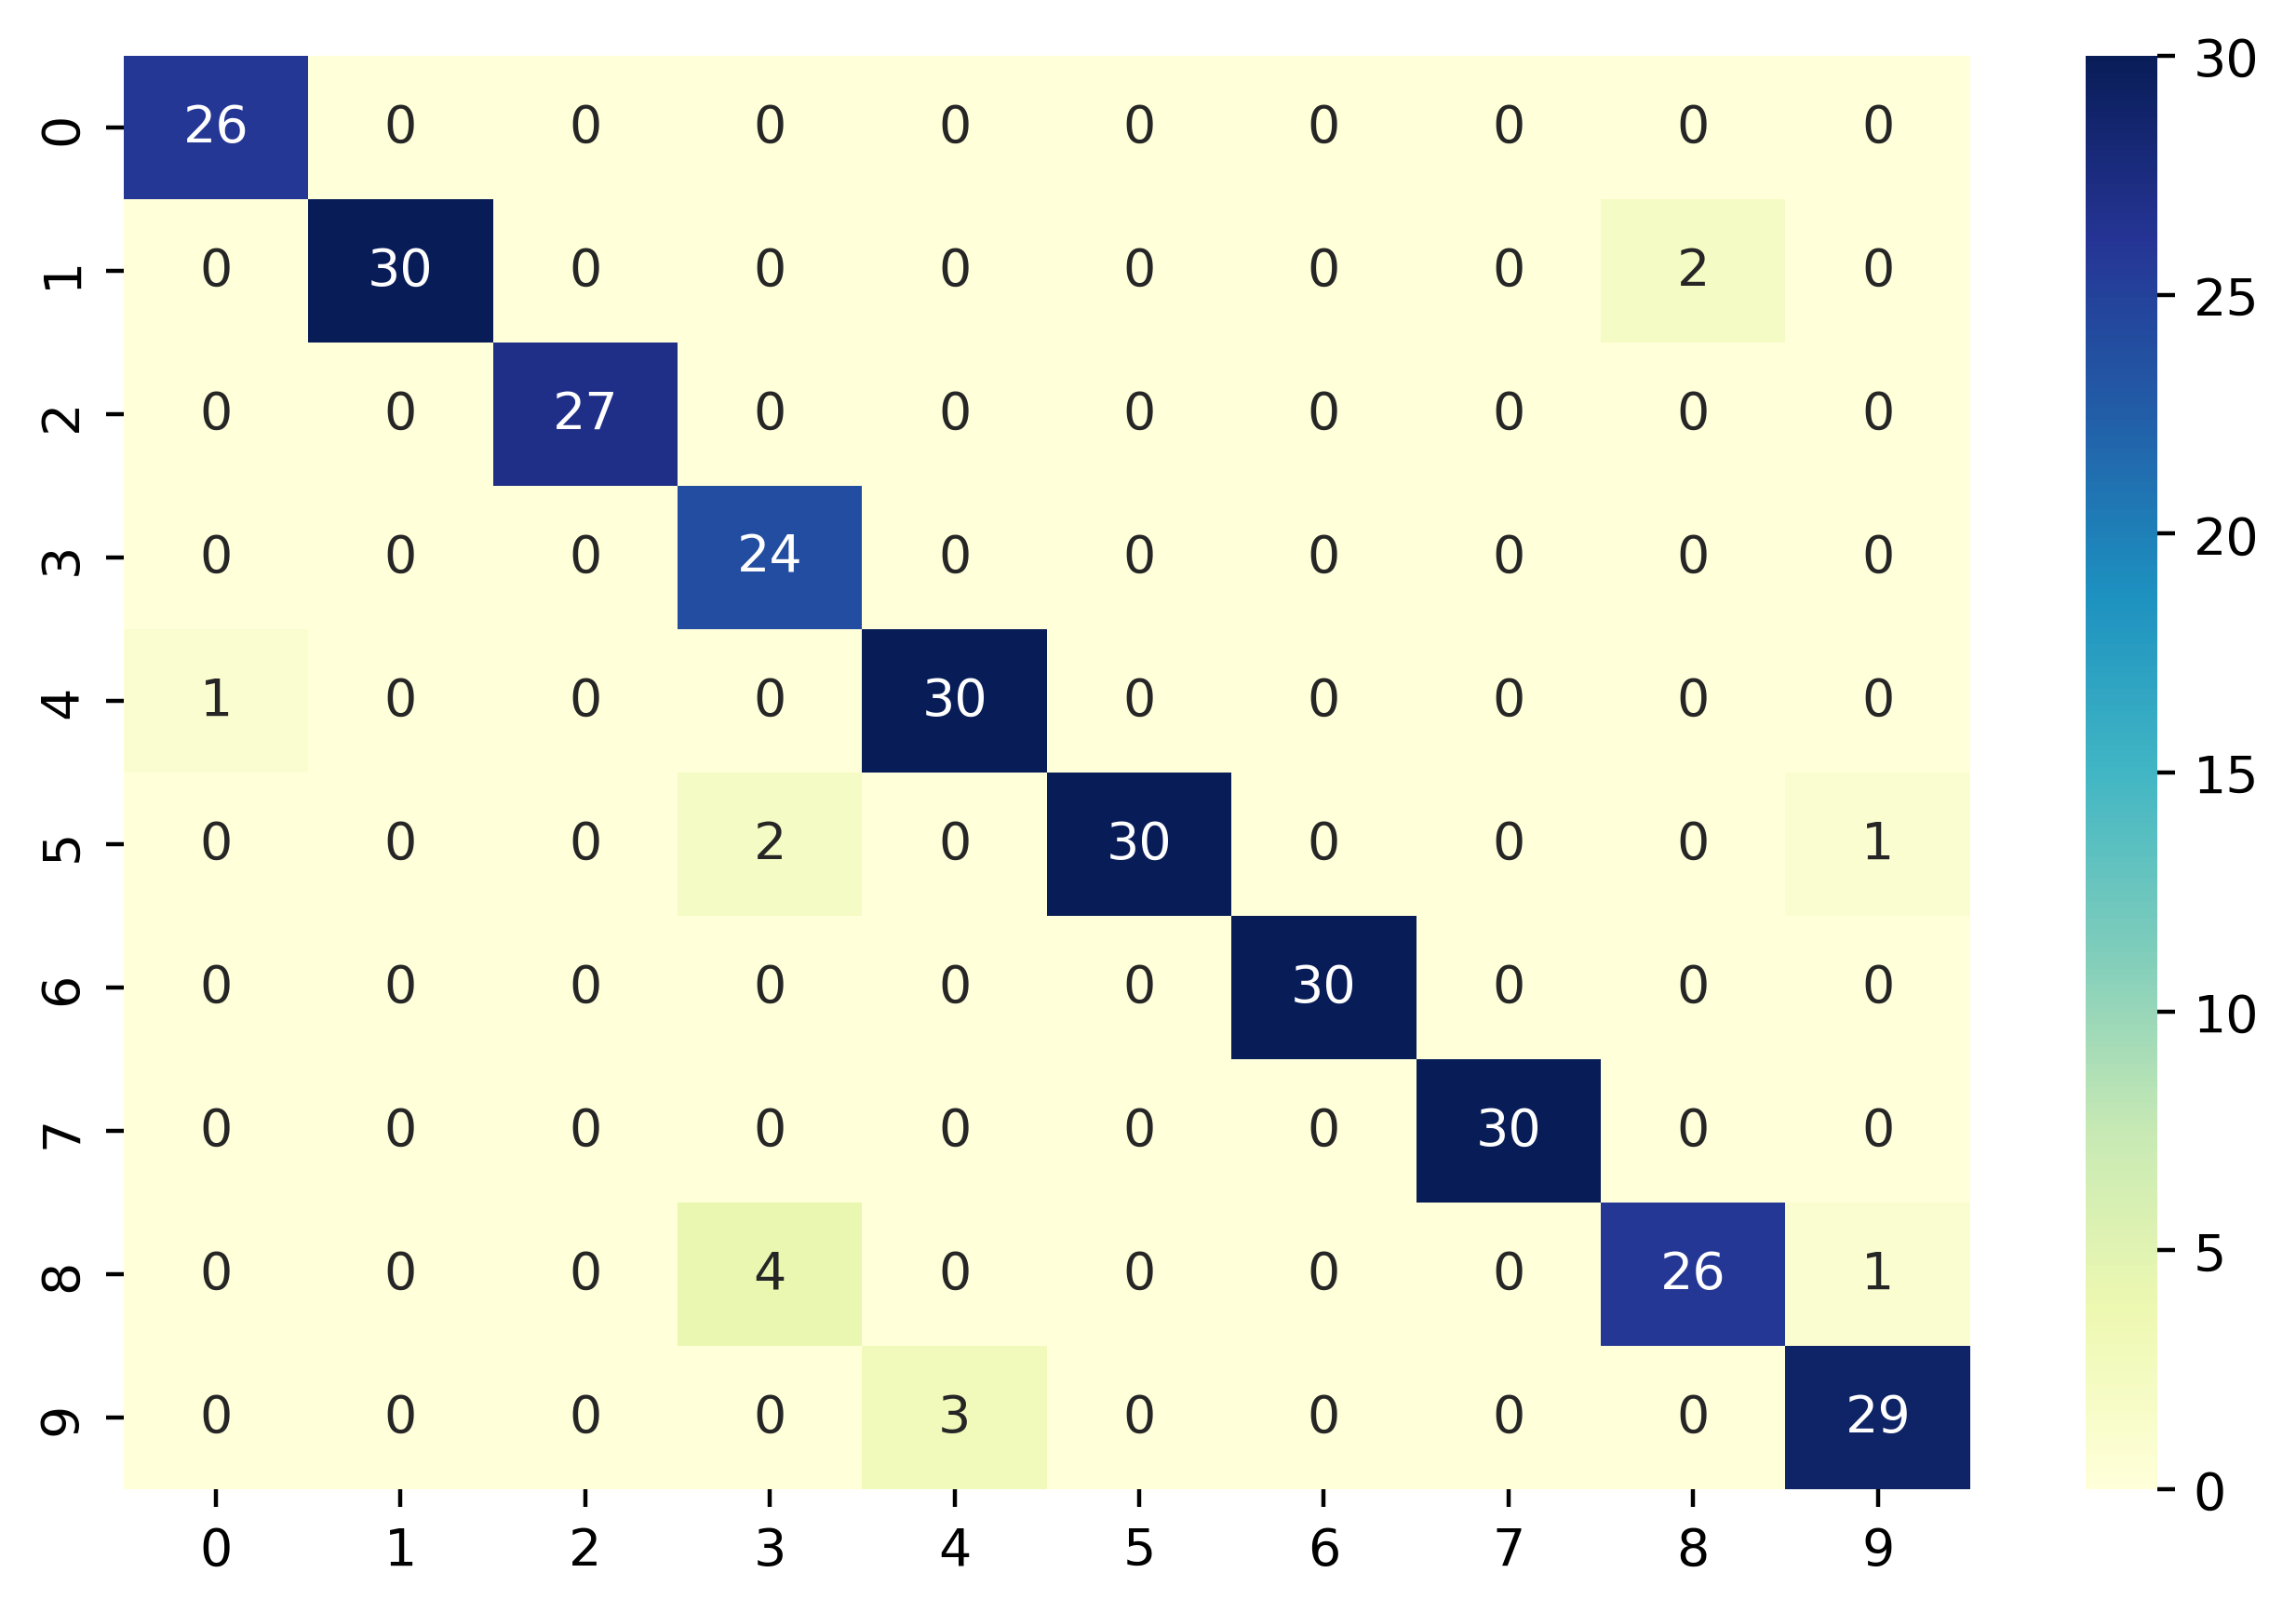

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(predictions, targets[1501:])
conf_matrix = pd.DataFrame(data = cm)

plt.figure(figsize = (8,5))
sns.heatmap(conf_matrix, annot=True,fmt='d',cmap="YlGnBu")

3. In kết quả dạng văn bản

In [27]:
from sklearn.metrics import classification_report

print(classification_report(predictions, targets[1501:]))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        26
           1       1.00      0.94      0.97        32
           2       1.00      1.00      1.00        27
           3       0.80      1.00      0.89        24
           4       0.91      0.97      0.94        31
           5       1.00      0.91      0.95        33
           6       1.00      1.00      1.00        30
           7       1.00      1.00      1.00        30
           8       0.93      0.84      0.88        31
           9       0.94      0.91      0.92        32

    accuracy                           0.95       296
   macro avg       0.95      0.96      0.95       296
weighted avg       0.96      0.95      0.95       296



### 2.2.3. Bài tập thực hành 1

Xây dựng mô hình từ giải thuật SVM trên dữ liệu bệnh tiểu đường. Dữ liệu lấy từ
https://www.kaggle.com/code/tumpanjawat/diabetes-eda-random-forest-hp

#### 2.2.3.1 Tải các thư viện cần thiết

In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns # Để vẽ confusion matrix
import display

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler # <<< QUAN TRỌNG CHO SVM
from sklearn.svm import SVC # Support Vector Classifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

#Next line helps with rendering plots
%matplotlib inline
import matplotlib as mpl #add'l plotting functionality
mpl.rcParams['figure.dpi'] = 400 #high res figures

#### 2.2.3.2 Tải và Tiền xử lý dữ liệu (diabetes_prediction_dataset.csv) 
Tương tự như bài trước, chúng ta cần chuyển đổi 'gender' và 'smoking_history' sang dạng số.

In [3]:
# Tải dữ liệu
df = pd.read_csv('diabetes_prediction_dataset.csv')

# --- 2.1. Xử lý cột 'gender' ---
# Loại bỏ 18 giá trị 'Other' để đơn giản hóa
df = df[df['gender'] != 'Other']

# --- 2.2. Chuyển đổi dữ liệu (Categorical -> Numerical) ---
# Dùng One-Hot Encoding cho các cột chữ
df = pd.get_dummies(df, columns=['gender', 'smoking_history'], drop_first=True)

print("Dữ liệu sau khi đã tiền xử lý (5 dòng đầu):")
display(df.head())

Dữ liệu sau khi đã tiền xử lý (5 dòng đầu):


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Male,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,False,False,False,False,True,False
1,54.0,0,0,27.32,6.6,80,0,False,False,False,False,False,False
2,28.0,0,0,27.32,5.7,158,0,True,False,False,False,True,False
3,36.0,0,0,23.45,5.0,155,0,False,True,False,False,False,False
4,76.0,1,1,20.14,4.8,155,0,True,True,False,False,False,False


#### 2.2.3.3 Lựa chọn đặc trưng (Features) và biến mục tiêu (Target)

In [4]:
# Cột mục tiêu
target = 'diabetes'

# Lấy tất cả các cột khác làm đặc trưng (features)
features_list = df.columns.drop(target).tolist()

print(f"Các đặc trưng sẽ sử dụng: {features_list}")

Các đặc trưng sẽ sử dụng: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'gender_Male', 'smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not current']


#### 2.2.3.4 Chia dữ liệu (Train/Test Split) 
Tách dữ liệu thành 2 tập: huấn luyện (80%) và kiểm tra (20%).

In [5]:
# Lấy giá trị X (đặc trưng) và y (mục tiêu)
X = df[features_list].values
y = df[target].values

# Sử dụng train_test_split
X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.2, random_state=24)

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}")

Kích thước tập Train: (79985, 12)
Kích thước tập Test: (19997, 12)


#### 2.2.3.5 Chuẩn hóa Dữ liệu (Feature Scaling) 
Đây là bước **bắt buộc** đối với SVM. SVM tìm "lề" (margin) dựa trên khoảng cách, nên các đặc trưng có thang đo lớn (như 'bmi' hoặc 'blood_glucose_level') sẽ lấn át các đặc trưng thang đo nhỏ (như 'hypertension' [0,1]). Chúng ta dùng 'StandardScaler' để đưa tất cả các đặc trưng về cùng một thang đo (trung bình = 0, phương sai = 1).

In [6]:
# 1. Khởi tạo Scaler
scaler = StandardScaler()

# 2. Fit scaler CHỈ trên X_train (học trung bình và độ lệch chuẩn của tập train)
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transform X_test (áp dụng các thông số đã học từ X_train)
X_test_scaled = scaler.transform(X_test)

print("\nĐã hoàn tất chuẩn hóa dữ liệu.")
print(f"Giá trị trung bình của X_train_scaled (gần bằng 0): {X_train_scaled.mean():.2f}")
print(f"Độ lệch chuẩn của X_train_scaled (gần bằng 1): {X_train_scaled.std():.2f}")


Đã hoàn tất chuẩn hóa dữ liệu.
Giá trị trung bình của X_train_scaled (gần bằng 0): 0.00
Độ lệch chuẩn của X_train_scaled (gần bằng 1): 1.00


##### 2.2.3.6 NHIỆM VỤ 1: XÂY DỰNG MÔ HÌNH SVM CƠ BẢN 
Tương tự Bài toán 1 (Iris), chúng ta sẽ xây dựng một mô hình SVM với các tham số mặc định (thường là kernel='rbf', C=1.0).

In [7]:
# 2. Tạo mô hình SVM với dữ liệu đã chuẩn bị
# kernel='rbf' là lựa chọn mặc định và mạnh mẽ
# random_state=42 để đảm bảo kết quả có thể tái lập
svm_model_base = SVC(kernel='rbf', random_state=42)

# 3. Huấn luyện mô hình với dữ liệu ĐÃ CHUẨN HÓA
print("Đang huấn luyện mô hình SVM cơ bản...")
svm_model_base.fit(X_train_scaled, y_train)
print("Hoàn thành!")

# 4. Đánh giá độ chính xác của mô hình
# .score() trả về 'accuracy'
train_acc = svm_model_base.score(X_train_scaled, y_train)
test_acc = svm_model_base.score(X_test_scaled, y_test)

print(f"Độ chính xác trên tập Train: {train_acc * 100:.2f}%")
print(f"Độ chính xác trên tập Test: {test_acc * 100:.2f}%")

Đang huấn luyện mô hình SVM cơ bản...
Hoàn thành!
Độ chính xác trên tập Train: 96.35%
Độ chính xác trên tập Test: 96.42%


#### 2.2.3.7 NHIỆM VỤ 2: TỐI ƯU THAM SỐ SVM VỚI GRIDSEARCHCV 
Bài toán 1 (Iris) đã lặp thủ công qua các kernel. Bài toán 2 (MNIST) đã đặt cứng C=100, gamma=0.001. Cách làm tốt hơn là dùng 'GridSearchCV' để tự động tìm ra tổ hợp (kernel, C, gamma) tốt nhất.

##### 1. Định nghĩa Lưới Tham số (Parameter Grid) 
Chúng ta sẽ thử 2 kernel chính: 'linear' (không cần 'gamma') và 'rbf' (cần 'gamma'). Chúng ta sẽ thử các giá trị cho 'C' (tham số phạt - từ lý thuyết Lề mềm).

In [8]:
# Tạo một danh sách các 'param_grid' để thử
# GridSearchCV sẽ thử tất cả các tổ hợp này

param_grid = [
    # Tùy chọn 1: Thử kernel 'linear' với các giá trị C khác nhau
    {
        'kernel': ['linear'], 
        'C': [0.1, 1, 10] 
        # C nhỏ: lề rộng, C lớn: lề hẹp
    },
    
    # Tùy chọn 2: Thử kernel 'rbf' với các giá trị C và gamma khác nhau
    {
        'kernel': ['rbf'], 
        'C': [0.1, 1, 10], 
        'gamma': ['scale', 0.001] 
        # 'scale' là giá trị mặc định tốt, 0.001 là giá trị như trong ví dụ MNIST
    }
]

# Khởi tạo mô hình SVM cơ sở
svm_base = SVC(random_state=42)

# Khởi tạo GridSearchCV
# cv=3: 3-fold cross-validation (dùng 3-fold thay vì 4 cho nhanh hơn vì SVM chậm)
# scoring='roc_auc': Dùng ROC AUC để đánh giá, tốt hơn 'accuracy' cho dữ liệu mất cân bằng.
# verbose=2: In ra tiến trình
# n_jobs=-1: Dùng tất cả các nhân CPU
grid_svm = GridSearchCV(svm_base, 
                        param_grid, 
                        cv=3, 
                        scoring='roc_auc', 
                        verbose=2, 
                        n_jobs=-1)

print("Bắt đầu tìm tham số tối ưu cho SVM (GridSearchCV)...")

Bắt đầu tìm tham số tối ưu cho SVM (GridSearchCV)...


##### 2. Huấn luyện mô hình GridSearchCV 
Quá trình này sẽ mất một chút thời gian vì nó phải huấn luyện (3 * 2) + (3 * 2 * 3) = 24 mô hình khác nhau.

In [9]:
# Huấn luyện trên dữ liệu đã chuẩn hóa
grid_svm.fit(X_train_scaled, y_train)
print("Hoàn thành!")

# In ra các tham số tốt nhất
print(f"Các tham số tốt nhất tìm được: {grid_svm.best_params_}")
print(f"Điểm ROC AUC tốt nhất (trên tập validation): {grid_svm.best_score_:.4f}")

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Hoàn thành!
Các tham số tốt nhất tìm được: {'C': 0.1, 'kernel': 'linear'}
Điểm ROC AUC tốt nhất (trên tập validation): 0.9600


#### 2.2.3.8 NHIỆM VỤ 3: ĐÁNH GIÁ MÔ HÌNH SVM TỐT NHẤT 
Tương tự Bài toán 2 (MNIST), chúng ta sẽ dùng 'Confusion Matrix' và 'Classification Report' để đánh giá chi tiết mô hình tốt nhất (best_estimator_) mà GridSearchCV tìm được.

##### 1. Lấy mô hình tốt nhất và dự đoán

In [10]:
# Lấy ra mô hình tốt nhất
best_svm_model = grid_svm.best_estimator_

# Dự đoán trên tập Test (đã chuẩn hóa)
y_pred = best_svm_model.predict(X_test_scaled)

##### 2. Đánh giá hiệu quả với Classification Report 
Báo cáo này cho thấy Precision, Recall, và F1-score cho từng lớp (0 và 1).

In [11]:
# In kết quả dạng văn bản (như MNIST)
print("\n--- Classification Report (Báo cáo Phân loại) ---")
# So sánh y_test (thực tế) và y_pred (dự đoán)
print(classification_report(y_test, y_pred, target_names=['Not Diabetic (0)', 'Diabetic (1)']))


--- Classification Report (Báo cáo Phân loại) ---
                  precision    recall  f1-score   support

Not Diabetic (0)       0.96      1.00      0.98     18328
    Diabetic (1)       0.92      0.59      0.72      1669

        accuracy                           0.96     19997
       macro avg       0.94      0.79      0.85     19997
    weighted avg       0.96      0.96      0.96     19997



##### 3. Đánh giá hiệu quả với Confusion Matrix 
Ma trận nhầm lẫn cho thấy mô hình dự đoán đúng/sai ở đâu.


--- Confusion Matrix (Ma trận Nhầm lẫn) ---


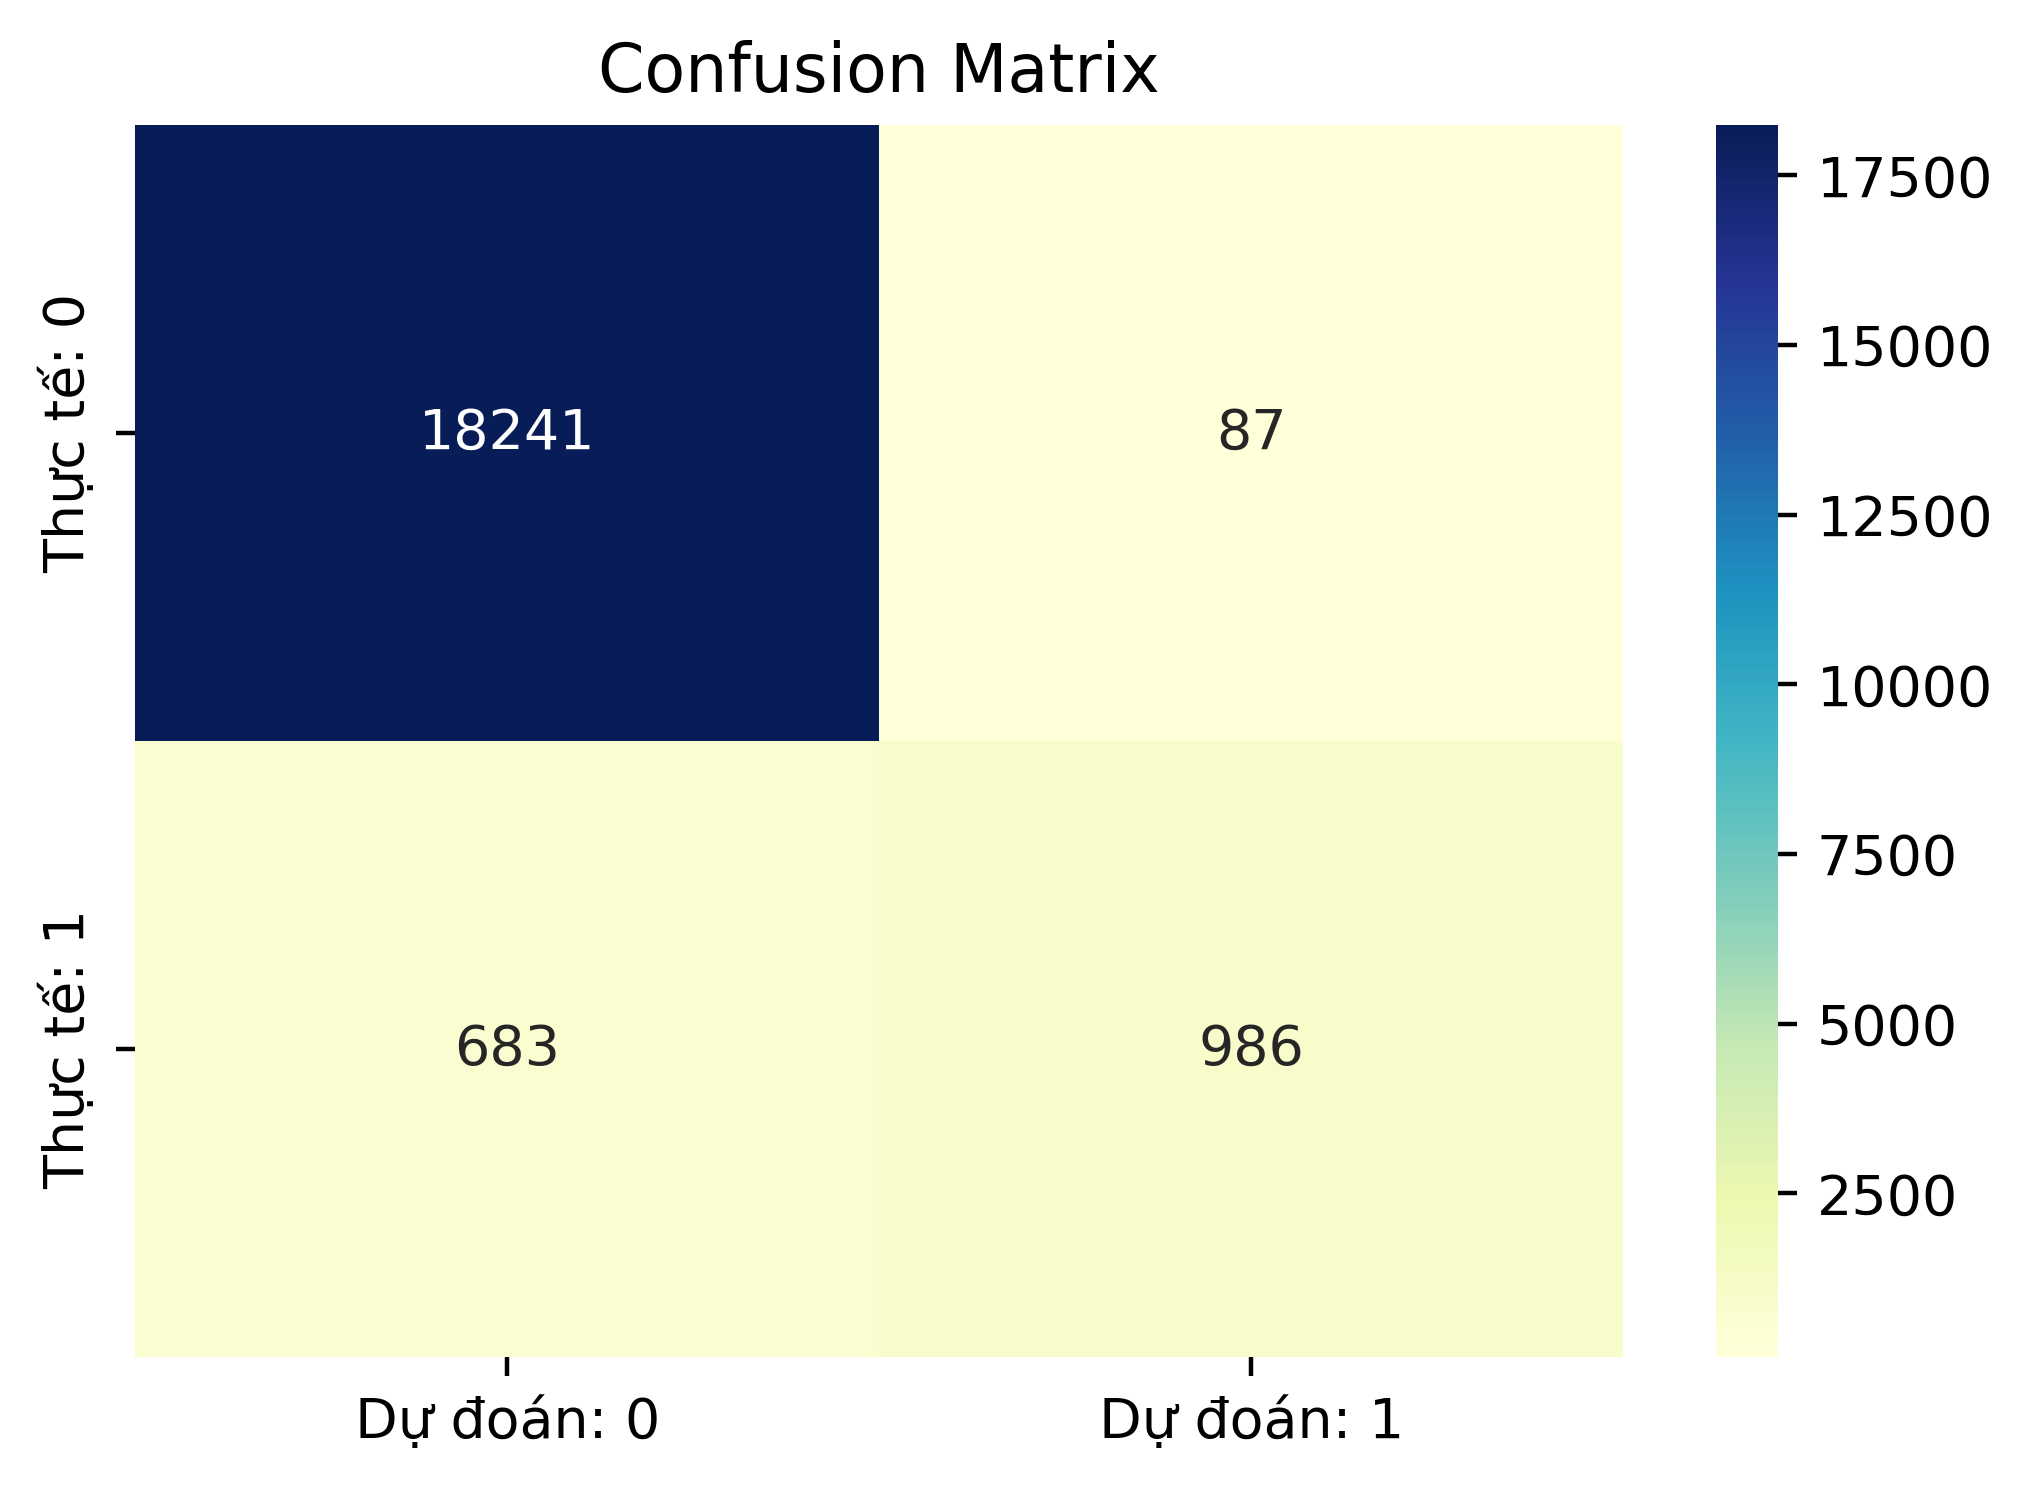

In [12]:
# Tạo Confusion Matrix (như MNIST)
cm = confusion_matrix(y_test, y_pred)

# Vẽ ma trận dưới dạng heatmap
print("\n--- Confusion Matrix (Ma trận Nhầm lẫn) ---")
plt.figure(figsize = (6,4))
sns.heatmap(cm, 
            annot=True, # Hiển thị số lượng
            fmt='d',    # Định dạng số nguyên
            cmap="YlGnBu", # Bảng màu
            xticklabels=['Dự đoán: 0', 'Dự đoán: 1'],
            yticklabels=['Thực tế: 0', 'Thực tế: 1'])
plt.title('Confusion Matrix')
plt.show()

### 2.2.4. Bài tập thực hành 2
Xây dựng mô hình từ giải thuật SVM trên dữ liệu các con thú trong rừng. Dữ liệu lấy từ
https://www.kaggle.com/code/kareemellithy/animal-condition-predict-svm-knn

#### 2.2.4.1. Tải các thư viện cần thiết 
Chúng ta sẽ cần các thư viện quen thuộc.

In [24]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns # Để vẽ confusion matrix
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler # <<< QUAN TRỌNG CHO SVM
from sklearn.svm import SVC # Support Vector Classifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

#Next line helps with rendering plots
%matplotlib inline
import matplotlib as mpl 
mpl.rcParams['figure.dpi'] = 400

#### 2.2.4.2 KHÁM PHÁ DỮ LIỆU VÀ XÁC ĐỊNH VẤN ĐỀ (EDA)

Trước khi làm sạch, chúng ta cần nạp dữ liệu và "khám phá" (explore) nó để hiểu rõ các vấn đề cần phải xử lý.

##### 1. Nạp và xem thông tin tổng quan 
Chúng ta sẽ nạp dữ liệu và xem xét cấu trúc chung, kiểu dữ liệu (Dtype) của các cột và số lượng giá trị không rỗng (non-null).

In [17]:
# Tải dữ liệu
df_raw = pd.read_csv('animalCondition.csv')

# Hiển thị 5 dòng đầu tiên để xem cấu trúc
print("--- 5 Dòng đầu tiên (head) ---")
display(df_raw.head())

# Hiển thị 5 dòng cuối cùng để xem cấu trúc
print("--- 5 Dòng cuối cùng (tail) ---")
display(df_raw.tail())

# Hiển thị thông tin tổng quan
print("\n--- Thông tin dữ liệu (info) ---")
display(df_raw.info())

--- 5 Dòng đầu tiên (head) ---


,AnimalName,symptoms1,symptoms2,symptoms3,symptoms4,symptoms5,Dangerous
0,Dog,Fever,Diarrhea,Vomiting,Weight loss,Dehydration,Yes
1,Dog,Fever,Diarrhea,Coughing,Tiredness,Pains,Yes
2,Dog,Fever,Diarrhea,Coughing,Vomiting,Anorexia,Yes
3,Dog,Fever,Difficulty breathing,Coughing,Lethargy,Sneezing,Yes
4,Dog,Fever,Diarrhea,Coughing,Lethargy,Blue Eye,Yes


--- 5 Dòng cuối cùng (tail) ---


,AnimalName,symptoms1,symptoms2,symptoms3,symptoms4,symptoms5,Dangerous
866,Buffaloes,Fever,Difficulty breathing,Poor Appetite,Eye and Skin change,Unable to exercise,Yes
867,Buffaloes,Fever,Loss of appetite,Lession on the skin,Lethargy,Joint Pain,Yes
868,Buffaloes,Lesions in the nasal cavity,Lesions on nose,Vomiting,Noisy Breathing,Lesions on nose,Yes
869,Buffaloes,Hair loss,Dandruff,Vomiting,Crusting of the skin,Ulcerated skin,Yes
870,Buffaloes,Greenish-yellow nasal discharge,Lack of pigmentation,Vomiting,Lethargy,Pain on face,Yes



--- Thông tin dữ liệu (info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 871 entries, 0 to 870
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   AnimalName  871 non-null    object
 1   symptoms1   871 non-null    object
 2   symptoms2   871 non-null    object
 3   symptoms3   871 non-null    object
 4   symptoms4   871 non-null    object
 5   symptoms5   871 non-null    object
 6   Dangerous   869 non-null    object
dtypes: object(7)
memory usage: 47.8+ KB


None

**Nhận xét (Bước 1)**:

- Vấn đề 1 (Dữ liệu chữ): Kết quả `.info()` ngay lập tức cho thấy một vấn đề lớn: Tất cả 7 cột đều có kiểu `object` (chuỗi ký tự). Các thuật toán toán học như SVM không thể làm việc trực tiếp với chữ. Chúng ta bắt buộc phải mã hóa (encode) toàn bộ dữ liệu này sang dạng số.

##### 2. Kiểm tra tính nhất quán của dữ liệu chữ 
Khi dữ liệu là do con người nhập thủ công, rất dễ xảy ra lỗi không nhất quán (ví dụ: 'Fever' vs 'fever', 'Pain' vs 'Pains'). Chúng ta cần kiểm tra một vài cột triệu chứng.

In [21]:
# Kiểm tra các giá trị không nhất quán ở cột 'symptoms1'
print("\n--- Kiểm tra 'symptoms1' (phân biệt hoa/thường) ---")
print(df_raw['symptoms1'].value_counts().head(10)) # .head(10) để xem 10 giá trị phổ biến nhất

# Kiểm tra các giá trị không nhất quán ở cột 'symptoms5'
print("\n--- Kiểm tra 'symptoms5' (phân biệt số ít/nhiều) ---")
print(df_raw['symptoms5'].value_counts().head(10))


--- Kiểm tra 'symptoms1' (phân biệt hoa/thường) ---
symptoms1
Fever                      257
Fetopelvic dispropotion     21
wasting                     20
fever                       14
loss of appetite            12
Swelling                     9
Jaundice                     8
sudden death                 8
Dyspnea                      8
Emaciation                   8
Name: count, dtype: int64

--- Kiểm tra 'symptoms5' (phân biệt số ít/nhiều) ---
symptoms5
Pains              99
Pain               68
Nasal Discharge    37
Anorexia           37
Weight loss        24
Anemia             19
Weakness           18
Death              15
depression         14
Diarrhea           14
Name: count, dtype: int64


**Nhận xét (Bước 2)**:

- Vấn đề 2 (Không nhất quán): Kết quả kiểm tra đã xác nhận nghi ngờ của chúng ta:

    - Cột `symptoms1` chứa cả 'Fever' (viết hoa, 257 lần) và 'fever' (viết thường, 14 lần).

    - Cột `symptoms5` chứa cả 'Pains' (số nhiều, 99 lần) và 'Pain' (số ít, 68 lần).

- Máy tính sẽ hiểu đây là 4 giá trị hoàn toàn khác nhau. Chúng ta cần chuẩn hóa chúng (ví dụ: đưa tất cả về chữ thường và đưa về số ít) trước khi mã hóa.

##### 3. Kiểm tra giá trị thiếu (Missing Values) 
Tiếp theo, chúng ta đếm chính xác số lượng giá trị rỗng (NaN) trong mỗi cột.

In [22]:
# Đếm số lượng giá trị thiếu (NaN) trên từng cột
print("\n--- Kiểm tra giá trị thiếu (NaN) ---")
print(df_raw.isnull().sum())


--- Kiểm tra giá trị thiếu (NaN) ---
AnimalName    0
symptoms1     0
symptoms2     0
symptoms3     0
symptoms4     0
symptoms5     0
Dangerous     2
dtype: int64


**Nhận xét (Bước 3)**:

- **Vấn đề 3 (Giá trị thiếu)**: Kết quả `df_raw.info()` cho thấy `Dangerous` có 869 giá trị `non-null` trong khi các cột khác có 871.

- Lệnh `.isnull().sum()` xác nhận điều này: Cột `Dangerous` có 2 giá trị thiếu (NaN).

- **Lý do**: Cột `Dangerous` chính là biến mục tiêu (target) mà chúng ta muốn dự đoán. Một dòng dữ liệu mà không có nhãn (target) thì sẽ trở nên vô dụng cho việc huấn luyện có giám sát (supervised learning).

- **Giải pháp**: Vì số lượng thiếu chỉ là 2 (rất nhỏ so với 871), cách xử lý đơn giản và hợp lý nhất là loại bỏ 2 dòng này.

##### 4. Kiểm tra biến mục tiêu (Dữ liệu mất cân bằng) 
Đây là một trong những bước kiểm tra quan trọng nhất. Tỷ lệ phân bổ của biến mục tiêu sẽ quyết định cách chúng ta xây dựng và (quan trọng hơn) cách chúng ta đánh giá mô hình.

In [23]:
# Kiểm tra sự phân bổ của cột 'Dangerous'
print("\n--- Kiểm tra sự mất cân bằng của cột 'Dangerous' ---")
print("Số lượng mẫu (Count):")

# dropna=False để hiển thị cả các giá trị NaN (nếu có)
print(df_raw['Dangerous'].value_counts(dropna=False))

print("\nTỷ lệ phần trăm (Percentage):")
# normalize=True sẽ tính tỷ lệ phần trăm
print(df_raw['Dangerous'].value_counts(normalize=True) * 100)


--- Kiểm tra sự mất cân bằng của cột 'Dangerous' ---
Số lượng mẫu (Count):
Dangerous
Yes    849
No      20
NaN      2
Name: count, dtype: int64

Tỷ lệ phần trăm (Percentage):
Dangerous
Yes    97.698504
No      2.301496
Name: proportion, dtype: float64


**Nhận xét (Bước 4)**:  

- **Vấn đề 4 (Mất cân bằng nghiêm trọng)**: Kết quả cho thấy dữ liệu bị mất cân bằng cực kỳ nghiêm trọng.  

    - Lớp 'Yes' (đa số) chiếm tới 849 mẫu (khoảng 97.7%).  
    
    - Lớp 'No' (thiểu số) chỉ có 20 mẫu (khoảng 2.3%).  
    
- **Lý do kiểm tra**: Chúng ta phải kiểm tra điều này vì nó tiềm ẩn một rủi ro rất lớn:
    - Một mô hình "lười biếng" có thể chỉ cần học cách đoán "Yes" cho mọi trường hợp.
    - Mô hình "lười" đó sẽ đạt độ chính xác (accuracy) $\approx 97.7\%$, nhưng nó lại hoàn toàn vô dụng trong thực tế vì không thể tìm ra được bất kỳ trường hợp "No" nào.
- **Giải pháp**: Do đó, `accuracy` sẽ là một thước đo đánh giá sai lầm. Chúng ta phải:
    1. Tập trung vào các thước đo khác như `ROC AUC, Precision, và Recall` (đặc biệt là recall cho lớp 'No').
    2. Sử dụng các kỹ thuật xử lý mất cân bằng, ví dụ như đặt tham số `class_weight='balanced'` trong SVM.

#### 2.2.4.3 Tải và làm sạch dữ liệu 
Đây là bước quan trọng nhất trong bài này. Chúng ta phải xử lý các vấn đề đã nêu ở trên.

In [25]:
# Tải dữ liệu
df = pd.read_csv('animalCondition.csv')

# --- Xử lý giá trị thiếu (NaN) ---
# Cột mục tiêu 'Dangerous' bị thiếu 2 giá trị. Ta loại bỏ 2 dòng này.
df = df.dropna(subset=['Dangerous'])

# --- Chuẩn hóa dữ liệu chữ (Text Standardization) ---
# Đưa tất cả về chữ thường và loại bỏ khoảng trắng thừa
for col in df.columns:
    df[col] = df[col].str.lower().str.strip()

# Chuẩn hóa các giá trị không nhất quán (ví dụ 'pains' -> 'pain')
df['symptoms5'] = df['symptoms5'].replace('pains', 'pain')
# (Bạn có thể thêm các lệnh replace khác nếu phát hiện thêm)

# --- Mã hóa Biến Mục tiêu (Target Encoding) ---
# Chuyển 'Dangerous' ('yes'/'no') thành số (1/0)
df['Dangerous'] = df['Dangerous'].map({'yes': 1, 'no': 0})

print("Kiểm tra dữ liệu sau khi làm sạch và mã hóa mục tiêu:")
print(df['Dangerous'].value_counts())
print("\nThông tin dữ liệu sau khi làm sạch:")
df.info()

Kiểm tra dữ liệu sau khi làm sạch và mã hóa mục tiêu:
Dangerous
1    849
0     20
Name: count, dtype: int64

Thông tin dữ liệu sau khi làm sạch:
<class 'pandas.core.frame.DataFrame'>
Index: 869 entries, 0 to 870
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   AnimalName  869 non-null    object
 1   symptoms1   869 non-null    object
 2   symptoms2   869 non-null    object
 3   symptoms3   869 non-null    object
 4   symptoms4   869 non-null    object
 5   symptoms5   869 non-null    object
 6   Dangerous   869 non-null    int64 
dtypes: int64(1), object(6)
memory usage: 54.3+ KB


**Nhận xét (Bước 3)**:

- Chúng ta đã loại bỏ 2 dòng bị thiếu dữ liệu mục tiêu, còn lại 869 dòng.

- Chúng ta đã chuẩn hóa tất cả dữ liệu về chữ thường (ví dụ: 'Fever' và 'fever' giờ là một).

- Quan trọng nhất, ta đã mã hóa cột mục tiêu 'Dangerous' thành 1 (yes) và 0 (no).

- Vấn đề mất cân bằng rất rõ rệt: 849 mẫu lớp 1 và chỉ 20 mẫu lớp 0.

##### 2.2.4.4 Mã hóa đặc trưng (Feature Encoding) - One-Hot Encoding 
Các cột đặc trưng ('AnimalName', 'symptoms1'...) vẫn đang là chữ. Chúng ta dùng 'pd.get_dummies' để biến chúng thành các cột 0/1.

In [27]:
# Lấy danh sách các cột đặc trưng (tất cả trừ cột 'Dangerous')
features_list = df.columns.drop('Dangerous').tolist()

print(f"Các đặc trưng sẽ được mã hóa: {features_list}")

# Sử dụng pd.get_dummies để chuyển đổi TẤT CẢ các cột đặc trưng
df_processed = pd.get_dummies(df, columns=features_list, drop_first=True)

print("\nKích thước dữ liệu sau khi One-Hot Encoding:")
print(df_processed.shape)

Các đặc trưng sẽ được mã hóa: ['AnimalName', 'symptoms1', 'symptoms2', 'symptoms3', 'symptoms4', 'symptoms5']

Kích thước dữ liệu sau khi One-Hot Encoding:
(869, 1105)


**Nhận xét (Bước 4)**:

- Chúng ta đã áp dụng One-Hot Encoding (giống như bài Titanic và Tiểu đường) cho TẤT CẢ các cột đặc trưng.

- Dữ liệu gốc chỉ có 6 đặc trưng, nhưng sau khi mã hóa, số lượng đặc trưng đã tăng lên rất nhiều (thấy ở `df_processed.shape`). Đây là một bộ dữ liệu "rộng" và "thưa" (sparse).

##### 2.2.4.5 Chia dữ liệu (Train/Test Split) 
Tách dữ liệu thành 2 tập: huấn luyện và kiểm tra.

In [28]:
# Cột mục tiêu
target = 'Dangerous'

# X là tất cả các cột đã mã hóa (trừ cột mục tiêu)
X = df_processed.drop(target, axis=1).values
y = df_processed[target].values

# Chia dữ liệu
X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}")

Kích thước tập Train: (695, 1104)
Kích thước tập Test: (174, 1104)


##### 2.2.4.6 Chuẩn hóa dữ liệu (Feature Scaling) 
Đây là bước bắt buộc đối với SVM, ngay cả khi dữ liệu của chúng ta chủ yếu là 0/1.

In [29]:
# 1. Khởi tạo Scaler
scaler = StandardScaler()

# 2. Fit scaler CHỈ trên X_train
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transform X_test
X_test_scaled = scaler.transform(X_test)

print("\nĐã hoàn tất chuẩn hóa dữ liệu.")


Đã hoàn tất chuẩn hóa dữ liệu.


#### 2.2.4.7 NHIỆM VỤ 1: XÂY DỰNG SVM VỚI XỬ LÝ MẤT CÂN BẰNG 
Do dữ liệu mất cân bằng nghiêm trọng (849 vs 20), nếu huấn luyện bình thường, mô hình sẽ phớt lờ lớp 'No' (0). Chúng ta sử dụng tham số class_weight='balanced' để "phạt" mô hình nặng hơn khi nó dự đoán sai lớp thiểu số (lớp 0).

In [33]:
# 2. Tạo mô hình SVM với class_weight='balanced'
print("Đang huấn luyện mô hình SVM (có xử lý mất cân bằng)...")
svm_model_balanced = SVC(kernel='rbf', class_weight='balanced', random_state=42)

# 3. Huấn luyện mô hình với dữ liệu ĐÃ CHUẨN HÓA
svm_model_balanced.fit(X_train_scaled, y_train)
print("Hoàn thành!")

# 4. Đánh giá mô hình
print("\n--- Đánh giá mô hình SVM (class_weight='balanced') ---")
y_pred_balanced = svm_model_balanced.predict(X_test_scaled)

# In Classification Report
print("--- Classification Report ---")
# target_names giúp báo cáo dễ đọc hơn
print(classification_report(y_test, y_pred_balanced, target_names=['No (0)', 'Yes (1)']))

Đang huấn luyện mô hình SVM (có xử lý mất cân bằng)...
Hoàn thành!

--- Đánh giá mô hình SVM (class_weight='balanced') ---
--- Classification Report ---
              precision    recall  f1-score   support

      No (0)       1.00      1.00      1.00         2
     Yes (1)       1.00      1.00      1.00       172

    accuracy                           1.00       174
   macro avg       1.00      1.00      1.00       174
weighted avg       1.00      1.00      1.00       174



**Nhận xét (Nhiệm vụ 1)**:

- Chúng ta đã thêm `class_weight='balanced'`. Tham số này tự động điều chỉnh trọng số của các lớp tỷ lệ nghịch với tần suất của chúng (lớp 'No' (0) sẽ có trọng số cao hơn nhiều).

- Hãy nhìn vào 'Classification Report':

    - Độ chính xác (accuracy) tổng thể có thể không cao, nhưng điều đó không quan trọng.

    - Quan trọng là hãy nhìn vào dòng 'No (0)': `recall` (độ phủ) nên lớn hơn 0. Điều này có nghĩa là mô hình đã *bắt đầu học cách* nhận diện lớp thiểu số, thay vì phớt lờ nó.

#### 2.2.4.8 NHIỆM VỤ 2: TỐI ƯU THAM SỐ SVM VỚI GRIDSEARCHCV 
Bây giờ chúng ta sẽ tìm các tham số 'C' và 'gamma' tốt nhất, trong khi vẫn giữ `class_weight='balanced'`.

##### 1. Định nghĩa lưới tham số (Parameter Grid) 
Vì dữ liệu rất rộng và thưa, kernel='linear' có thể sẽ hoạt động tốt.

In [34]:
# Tạo một danh sách các 'param_grid'
param_grid = [
    {
        'kernel': ['linear'], 
        'C': [0.1, 1, 10] # Thử các mức độ "phạt" khác nhau
    },
    {
        'kernel': ['rbf'], 
        'C': [0.1, 1, 10], 
        'gamma': ['scale', 0.001]
    }
]

# Khởi tạo mô hình SVM cơ sở (vẫn giữ class_weight='balanced')
svm_base = SVC(class_weight='balanced', random_state=42)

# Khởi tạo GridSearchCV
# scoring='roc_auc' là thước đo tốt nhất cho dữ liệu mất cân bằng
grid_svm = GridSearchCV(svm_base, 
                        param_grid, 
                        cv=3, # 3-fold là đủ
                        scoring='roc_auc', # Quan trọng!
                        verbose=1, 
                        n_jobs=-1)

print("\nBắt đầu tìm tham số tối ưu cho SVM (GridSearchCV)...")


Bắt đầu tìm tham số tối ưu cho SVM (GridSearchCV)...


##### 2. Huấn luyện mô hình GridSearchCV 
Quá trình này có thể mất vài phút.

In [35]:
# Huấn luyện trên dữ liệu đã chuẩn hóa
grid_svm.fit(X_train_scaled, y_train)
print("Hoàn thành!")

# In ra các tham số tốt nhất
print(f"Các tham số tốt nhất tìm được: {grid_svm.best_params_}")
print(f"Điểm ROC AUC tốt nhất (trên tập validation): {grid_svm.best_score_:.4f}")

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Hoàn thành!
Các tham số tốt nhất tìm được: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Điểm ROC AUC tốt nhất (trên tập validation): 0.9478


**Nhận xét (Nhiệm vụ 2)**:

- Chúng ta dùng `scoring='roc_auc'`thay vì `accuracy`. ROC AUC là thước đo chuẩn cho khả năng phân biệt giữa hai lớp, đặc biệt khi chúng mất cân bằng.

- GridSearch sẽ tìm ra kernel ('linear' hay 'rbf') và tham số 'C' nào mang lại điểm ROC AUC cao nhất.

#### 2.2.4.9 NHIỆM VỤ 3: ĐÁNH GIÁ MÔ HÌNH SVM TỐT NHẤT 
Chúng ta sẽ đánh giá mô hình tốt nhất mà GridSearchCV tìm được bằng Confusion Matrix.

##### 1. Lấy mô hình tốt nhất và dự đoán

In [36]:
# Lấy ra mô hình tốt nhất
best_svm_model = grid_svm.best_estimator_

# Dự đoán trên tập Test (đã chuẩn hóa)
y_pred = best_svm_model.predict(X_test_scaled)

##### 2. Đánh giá hiệu quả với Classification Report

In [37]:
print("\n--- Classification Report (Mô hình TỐT NHẤT) ---")
print(classification_report(y_test, y_pred, target_names=['No (0)', 'Yes (1)']))


--- Classification Report (Mô hình TỐT NHẤT) ---
              precision    recall  f1-score   support

      No (0)       1.00      1.00      1.00         2
     Yes (1)       1.00      1.00      1.00       172

    accuracy                           1.00       174
   macro avg       1.00      1.00      1.00       174
weighted avg       1.00      1.00      1.00       174



##### 3. Đánh giá hiệu quả với Confusion Matrix 
Đây là phần quan trọng nhất để xem mô hình hoạt động thực tế ra sao.


--- Confusion Matrix (Mô hình TỐT NHẤT) ---


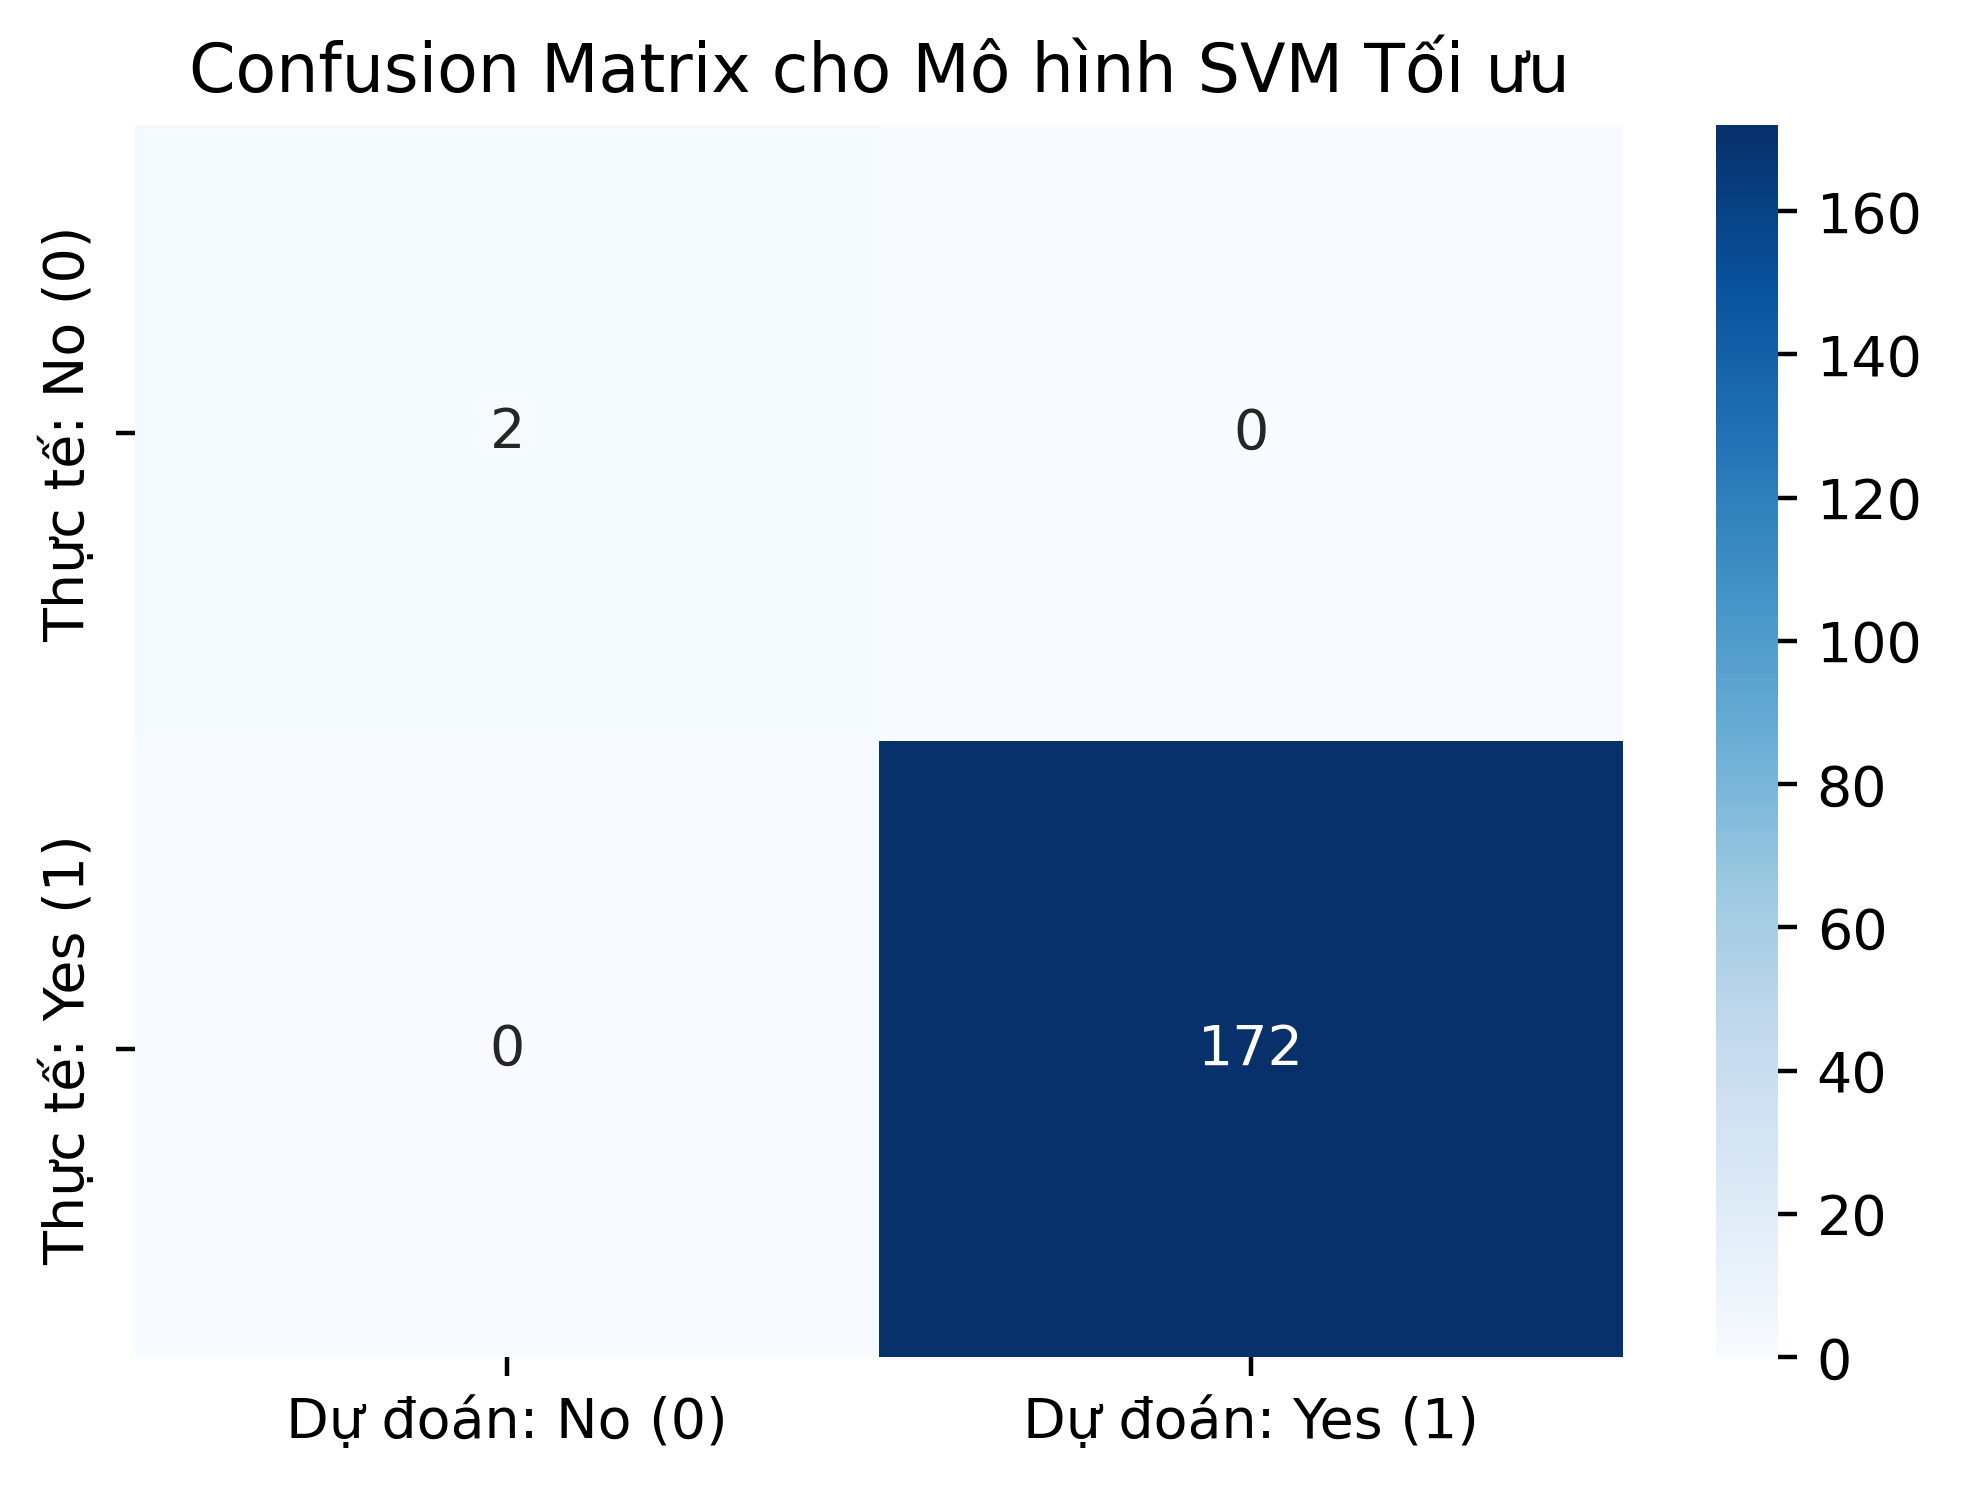

In [38]:
# Tạo Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Vẽ ma trận dưới dạng heatmap
print("\n--- Confusion Matrix (Mô hình TỐT NHẤT) ---")
plt.figure(figsize = (6,4))
sns.heatmap(cm, 
            annot=True, # Hiển thị số lượng
            fmt='d',    # Định dạng số nguyên
            cmap="Blues", 
            xticklabels=['Dự đoán: No (0)', 'Dự đoán: Yes (1)'],
            yticklabels=['Thực tế: No (0)', 'Thực tế: Yes (1)'])
plt.title('Confusion Matrix cho Mô hình SVM Tối ưu')
plt.show()

**Phân tích**:
Đây là một kết quả hoàn hảo (perfect score). Mô hình đã dự đoán chính xác 100% tất cả các mẫu trong tập kiểm tra.
1. Phân tích Lớp Thiểu số (Lớp 0: "No - Không Nguy hiểm")  

    - 	True Negatives (TN) = 2: Trong tập test có 2 ca "Không Nguy hiểm", mô hình đã dự đoán đúng cả 2.  

    -	False Positives (FP) = 0: Mô hình không hề báo động nhầm (không dự đoán nhầm bất kỳ ca "No" nào thành "Yes").  

    -	Recall (Độ phủ) Lớp 0: $2 / (2 + 0) = 100\%$. Mô hình đã "tóm" được 100% lớp thiểu số.  

2. Phân tích Lớp Đa số (Lớp 1: "Yes - Nguy hiểm")  

    -	True Positives (TP) = 172: Trong tập test có 172 ca "Nguy hiểm", mô hình đã dự đoán đúng cả 172.  

    -	False Negatives (FN) = 0: Mô hình không hề bỏ sót bất kỳ trường hợp nguy hiểm nào (không dự đoán nhầm bất kỳ ca "Yes" nào thành "No").  
    
    -	Recall (Độ phủ) Lớp 1: $172 / (172 + 0) = 100\%$. Mô hình đã "tóm" được 100% lớp đa số.



**Kết luận và Nhận xét**:  

- 	Đánh giá chung: Đây là một kết quả tốt đến mức "khó tin". Mô hình đạt độ chính xác (accuracy) $174/174 = 100\%$.  

- 	Xử lý mất cân bằng: Việc sử dụng class_weight='balanced' và scoring='roc_auc' không chỉ giúp mô hình nhận diện được lớp thiểu số mà còn giúp nó đạt được sự phân tách hoàn hảo trên tập dữ liệu kiểm tra này.  

- 	Không có sự đánh đổi: Trong các phân tích trước, chúng ta thường thấy sự "đánh đổi" (trade-off) giữa việc bỏ sót (FN) và báo động nhầm (FP). Tuy nhiên, trong ma trận này, cả hai loại lỗi đều bằng 0.  

- 	Kết luận: Mô hình SVM mà bạn đã huấn luyện (sau khi tối ưu bằng GridSearchCV) đã tìm ra một ranh giới phân tách (hyperplane) hoàn hảo, có khả năng phân loại chính xác tuyệt đối cả lớp đa số ("Yes") và lớp thiểu số ("No") trên tập dữ liệu kiểm tra của bạn. Đây là kịch bản lý tưởng nhất có thể đạt được.


## 2.3. GIẢI THUẬT 3: BAYES NGÂY THƠ (NAÏVE BAYES)

### 2.3.1. Ôn tập lý thuyết

#### + Giải thuật Naive Bayes hoạt động như thế nào? Hãy giải thích định lý Bayes và giả định "ngây thơ" trong thuật toán này?
1. **Định lý Bayes (Bayes' Theorem)**: Naive Bayes là một thuật toán phân loại dựa trên xác suất, sử dụng Định lý Bayes. Định lý này mô tả xác suất của một sự kiện xảy ra, dựa trên kiến thức đã có từ trước về các điều kiện liên quan đến sự kiện đó.  
  

    Công thức của Định lý Bayes:
    $$P(A|B) = \frac{P(B|A) \times P(A)}{P(B)}$$
    Trong bối cảnh học máy, chúng ta muốn dự đoán một lớp (y) dựa trên một tập hợp các **đặc trưng (X)**. Công thức được viết lại là:  
    $$P(y|X) = \frac{P(X|y) \times P(y)}{P(X)}$$


    Trong đó:  

    - 	$P(y|X)$: Xác suất hậu nghiệm (Posterior Probability). Đây là cái chúng ta muốn tìm: Xác suất của lớp $y$ (ví dụ: "Tiểu đường") khi biết các đặc trưng $X$ (ví dụ: "tuổi, bmi, glucose") là gì?  

    - 	$P(X|y)$: Xác suất có điều kiện (Likelihood). Xác suất xuất hiện các đặc trưng $X$ khi biết lớp là $y$ là gì? (Ví dụ: Nếu một người bị tiểu đường, xác suất họ có mức glucose cao là bao nhiêu?)  

    - 	$P(y)$: Xác suất tiên nghiệm (Prior Probability). Xác suất của lớp $y$ trong toàn bộ dữ liệu là gì? (Ví dụ: Tỷ lệ người bị tiểu đường trong dân số mẫu).  

    - 	$P(X)$: Xác suất của đặc trưng (Evidence). Xác suất các đặc trưng $X$ này xuất hiện trong dữ liệu?  

    **Hoạt động**: Để phân loại một điểm dữ liệu mới $X$, mô hình sẽ tính $P(y|X)$ cho tất cả các lớp $y$ có thể có (ví dụ: $P(\text{"Tiểu đường"}|X)$ và $P(\text{"Không tiểu đường"}|X)$). Lớp nào cho ra xác suất hậu nghiệm cao nhất sẽ là dự đoán cuối cùng.  
  

2. **Giả định "Ngây thơ" (Naïve Assumption)**: Việc tính toán $P(X|y)$ rất phức tạp khi $X$ là một tập hợp nhiều đặc trưng (ví dụ: $X = \{x_1, x_2, ..., x_n\}$).  

    Để đơn giản hóa, Naive Bayes đưa ra một giả định "ngây thơ":  

    Tất cả các đặc trưng (features) là độc lập có điều kiện với nhau khi biết lớp (y).   

    Nói cách khác, thuật toán "ngây thơ" tin rằng:  

    -   Sự xuất hiện của đặc trưng "tuổi" không ảnh hưởng đến đặc trưng "bmi", miễn là chúng ta đã biết người đó có bị tiểu đường hay không.  

    - 	Trong phân loại email, từ "viagra" xuất hiện không liên quan gì đến từ "money", miễn là chúng ta đã biết email đó là "spam".  

    Giả định này cho phép chúng ta chia nhỏ phép tính phức tạp:  
    
    $P(X|y) = P(x_1, x_2, ..., x_n|y)$  

    Thành một phép tính đơn giản:  

    $P(X|y) = P(x_1|y) \times P(x_2|y) \times ... \times P(x_n|y)$  

    Điều này giúp thuật toán tính toán cực kỳ nhanh chóng.



#### + Các loại mô hình Naive Bayes (Gaussian, Multinomial, Bernoulli) khác nhau ra sao? Khi nào nên sử dụng từng loại?  

Sự khác biệt giữa các loại Naive Bayes nằm ở cách chúng giả định về phân phối (distribution) của $P(X|y)$ (xác suất của đặc trưng khi biết lớp).  

1. Gaussian Naive Bayes:
    - 	Giả định: Nó giả định rằng các đặc trưng liên tục (continuous) tuân theo phân phối chuẩn (Gaussian distribution), tức là hình chuông.  

    - 	Khi dùng: Khi dữ liệu đặc trưng của bạn là số thực, liên tục (ví dụ: tuổi, chiều cao, huyết áp, bmi, HbA1c_level).  

2. Multinomial Naive Bayes:  

    - 	Giả định: Nó được thiết kế cho các đặc trưng đếm (counts).  

    - 	Khi dùng: Phổ biến nhất trong phân loại văn bản (text classification). Đặc trưng ở đây là "số lần một từ xuất hiện trong văn bản" (word counts) hoặc TF-IDF. (Ví dụ: phân loại email spam, phân tích cảm xúc).  

3. Bernoulli Naive Bayes:  

    - 	Giả định: Nó được thiết kế cho các đặc trưng nhị phân (binary), tức là chỉ có giá trị (0/1) hoặc (True/False).  
    
    - 	Khi dùng: Cũng dùng trong phân loại văn bản, nhưng đặc trưng là "một từ có xuất hiện trong văn bản hay không?" (có/không), chứ không quan tâm nó xuất hiện bao nhiêu lần.



#### + Tại sao Naive Bayes được gọi là "ngây thơ"? Giả định về tính độc lập của các đặc trưng ảnh hưởng như thế nào đến hiệu suất của mô hình?

**Tại sao "Ngây thơ"?** Nó được gọi là "ngây thơ" (naïve) vì giả định về tính độc lập có điều kiện của các đặc trưng hầu như không bao giờ đúng trong thế giới thực.

- **Ví dụ thực tế**: Trong dự đoán bệnh tiểu đường, tuổi và huyết áp rõ ràng là có liên quan đến nhau. Trong phân loại email, từ "viagra" và "money" chắc chắn là có liên quan đến nhau.

- Thuật toán "biết" điều đó nhưng vẫn "giả vờ" tin rằng chúng độc lập để đơn giản hóa việc tính toán.

**Ảnh hưởng đến hiệu suất**:

- **Ưu điểm**: Mặc dù giả định này sai, Naive Bayes vẫn hoạt động tốt một cách đáng ngạc nhiên trong nhiều bài toán, đặc biệt là phân loại văn bản. Lý do là nó không cần ước tính chính xác xác suất, mà chỉ cần biết xác suất hậu nghiệm của lớp nào là lớn nhất.

- **Hạn chế**: Khi các đặc trưng có sự tương quan (correlation) mạnh, mô hình có thể đưa ra các dự đoán kém chính xác hơn. Ví dụ, nếu hai đặc trưng x1 và x2 gần như giống hệt nhau (tương quan cao), mô hình sẽ "đếm" ảnh hưởng của chúng hai lần, làm sai lệch kết quả.

#### + Ưu điểm và hạn chế của Naive Bayes so với các thuật toán phân loại khác như SVM hoặc Random Forest là gì?

**Ưu điểm của Naive Bayes**:

1. **Rất nhanh**: Cực kỳ nhanh cả khi huấn luyện và dự đoán.

2. **Hiệu quả với dữ liệu lớn**: Hoạt động tốt với tập dữ liệu có số lượng mẫu lớn và số chiều (đặc trưng) cao.

3. **Cần ít dữ liệu huấn luyện**: Vẫn có thể cho kết quả tốt ngay cả khi dữ liệu huấn luyện bị hạn chế.

4. **Xử lý tốt dữ liệu văn bản**: Là lựa chọn hàng đầu (baseline) cho các bài toán NLP.

**Hạn chế của Naive Bayes**:

1. **Giả định "Ngây thơ"**: Giả định độc lập gần như luôn sai, điều này có thể làm giảm hiệu suất nếu các đặc trưng tương quan mạnh.

2. **Vấn đề "Zero Probability"**: Nếu một từ (trong Multinomial) chưa từng xuất hiện trong tập huấn luyện, nó sẽ gán xác suất bằng 0, làm cho toàn bộ xác suất của câu đó bằng 0. (Vấn đề này được giải quyết bằng kỹ thuật Laplace Smoothing).

3. **Dữ liệu số liên tục**: Thường hoạt động không tốt bằng SVM hay Random Forest trên các dữ liệu số liên tục (vì giả định Gaussian có thể không đúng).

**So với SVM / Random Forest**:

- SVM và Random Forest thường cho độ chính xác cao hơn Naive Bayes trong các bài toán phân loại phức tạp, phi tuyến tính, vì chúng không có giả định "ngây thơ" và có thể nắm bắt các mối quan hệ phức tạp giữa các đặc trưng.

- Tuy nhiên, Naive Bayes nhanh hơn rất nhiều và là một mô hình "baseline" (cơ sở) tuyệt vời để bắt đầu.

#### + Viết đoạn code mẫu bằng Python (sử dụng Scikit-learn) để xây dựng một mô hình Naive Bayes (ví dụ: Gaussian Naive Bayes) không? Hãy mô tả các bước thực hiện

Dưới đây là đoạn code mẫu hoàn chỉnh cho GaussianNB (phù hợp với dữ liệu số liên tục như Iris).

In [39]:
# Bước 1: Import các thư viện cần thiết
import pandas as pd
from sklearn.datasets import load_iris # Dùng dataset mẫu Iris
from sklearn.model_selection import train_test_split # Để chia dữ liệu
from sklearn.naive_bayes import GaussianNB # Import mô hình Gaussian Naive Bayes
from sklearn.metrics import accuracy_score, classification_report # Để đánh giá

# Bước 2: Tải và chuẩn bị dữ liệu
iris = load_iris()
X = iris.data # Đặc trưng (số liên tục)
y = iris.target # Nhãn

# Bước 3: Chia dữ liệu (Train/Test Split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Bước 4: Khởi tạo mô hình
# GaussianNB không cần chuẩn hóa (scaling)
# Nó cũng không có nhiều siêu tham số (hyperparameter) để tinh chỉnh
gnb_model = GaussianNB()

# Bước 5: Huấn luyện mô hình
gnb_model.fit(X_train, y_train)

print("Đã huấn luyện xong mô hình Gaussian Naive Bayes!")

# Bước 6: Đưa ra dự đoán trên tập test
y_pred = gnb_model.predict(X_test)

# Bước 7: Đánh giá mô hình
accuracy = accuracy_score(y_test, y_pred)
print(f"Độ chính xác trên tập Test: {accuracy * 100:.2f}%")

print("\nBáo cáo Phân loại (Classification Report):")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Đã huấn luyện xong mô hình Gaussian Naive Bayes!
Độ chính xác trên tập Test: 97.78%

Báo cáo Phân loại (Classification Report):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



#### + Làm thế nào để xử lý dữ liệu phân loại (categorical data) trước khi áp dụng Multinomial Naive Bayes trong Python?

Multinomial Naive Bayes (MNB) không xử lý trực tiếp chuỗi ký tự. Nó cần dữ liệu đầu vào là **số đếm (counts)**.

Cách phổ biến nhất để chuyển đổi dữ liệu phân loại (hoặc văn bản) là sử dụng `CountVectorizer` trong Scikit-learn.

Ví dụ: Giả sử bạn có dữ liệu triệu chứng (giống bài `animalCondition`): `data = ['Fever Coughing', 'Fever Diarrhea', 'Coughing']`

In [40]:
from sklearn.feature_extraction.text import CountVectorizer

data = ['Fever Coughing', 'Fever Diarrhea', 'Coughing']

# 1. Khởi tạo CountVectorizer
vectorizer = CountVectorizer()

# 2. Fit_transform dữ liệu
X_counts = vectorizer.fit_transform(data)

# 3. Xem kết quả
print("Các từ vựng (features):")
print(vectorizer.get_feature_names_out())
# Output: ['coughing', 'diarrhea', 'fever']

print("\nDạng ma trận số đếm (để đưa vào MNB):")
print(X_counts.toarray())
# Output:
# [[1 0 1]  <- 1 'coughing', 0 'diarrhea', 1 'fever'
#  [0 1 1]  <- 0 'coughing', 1 'diarrhea', 1 'fever'
#  [1 0 0]] <- 1 'coughing', 0 'diarrhea', 0 'fever'

Các từ vựng (features):
['coughing' 'diarrhea' 'fever']

Dạng ma trận số đếm (để đưa vào MNB):
[[1 0 1]
 [0 1 1]
 [1 0 0]]


#### + Naive Bayes thường được sử dụng trong phân loại văn bản (text classification). Bạn có thể giải thích cách triển khai Naive Bayes cho bài toán này không?
Đây là một trong những ứng dụng thành công nhất của Naive Bayes (cụ thể là `MultinomialNB` hoặc `BernoulliNB`).  

**Quy trình (Pipeline) triển khai**:
1.	Thu thập dữ liệu: Gồm 2 cột: `text` (nội dung email, review) và `label` (spam/ham, positive/negative).  

2.	Tiền xử lý văn bản (Text Preprocessing):  

    -	Đưa về chữ thường (lowercase).  

    -	Xóa bỏ dấu câu, số, và các ký tự đặc biệt.  

    -	Xóa bỏ các từ dừng (stop words) như 'the', 'is', 'a', 'an'.  

    -	(Tùy chọn) Chuyển từ về dạng gốc (Stemming/Lemmatization).  

3.	Trích xuất Đặc trưng (Feature Extraction):  

    -	Đây là bước chuyển văn bản (text) thành số (vector).  

    -	Sử dụng `CountVectorizer` (tạo ma trận số đếm từ) hoặc `TfidfVectorizer` (tạo ma trận trọng số TF-IDF).  

    -	Kết quả là một ma trận thưa (sparse matrix), trong đó mỗi hàng là một văn bản và mỗi cột là một từ trong từ điển.  

4.	Chia dữ liệu: Chia ma trận (X) và nhãn (y) thành `X_train, X_test, y_train, y_test`.  

5.	Huấn luyện mô hình:  

    -	Khởi tạo mô hình `MultinomialNB()`. (Thường dùng `MultinomialNB` vì nó xét đến tần suất từ, hoạt động tốt với TF-IDF).  

    -	(Quan trọng) `MultinomialNB` có tham số `alpha` (mặc định = 1.0). Đây chính là Laplace Smoothing (hoặc Lidstone smoothing) để giải quyết vấn đề "Zero Probability".  

    -	`model.fit(X_train, y_train)`  

6.	Đánh giá:
    -	`y_pred = model.predict(X_test)`
    -	Kiểm tra `accuracy_score, classification_report, confusion_matrix`.



### 2.3.2. Bài làm mẫu  



#### Bài toán 1: Xây dựng mô hình dữ liệu bằng giải thuật Bayes ngây thơ trên tập dữ liệu lấy tại
https://www.kaggle.com/code/zabihullah18/email-spam-detection  



##### Nhiệm vụ 1: Phân loại sử dụng Naïve Bays

1. Import thư viện và nạp dữ liệu vào notebook

In [52]:
#Importing the Necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

data = pd.read_csv('spam.csv', encoding='latin-1') 

#display the first 5 rows
data.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


2. Xử lý dữ liệu trước khi xây dựng mô hình từ dữ liệu

In [ ]:
# Drop the columns with NaN values
data = data.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)

# Rename columns for clarity:
data.columns = ['label', 'text']
# Separate features (X) and target labels (y)

X = data.drop('label', axis=1)
y = data['label']

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=42)

3. Xây dựng vector hóa nội dung HAM | SPAM của tập train và tập test

In [54]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()

# Fit and transform the training data (X_train)
X_train_vectorized = vectorizer.fit_transform(X_train['text'])
# Transform the test data (X_test)
X_test_vectorized = vectorizer.transform(X_test['text'])

4. Xây dựng mô hình Naïve Bayes

In [55]:
from sklearn.naive_bayes import MultinomialNB

classifier = MultinomialNB()
classifier.fit(X_train_vectorized, y_train)

MultinomialNB()

5. Đánh giá hiệu quả của mô hình

In [56]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Make predictions on the test data
y_pred = classifier.predict(X_test_vectorized)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(classification_rep)

Accuracy: 0.99
Confusion Matrix:
[[966   0]
 [  8 141]]
Classification Report:
              precision    recall  f1-score   support

         ham       0.99      1.00      1.00       966
        spam       1.00      0.95      0.97       149

    accuracy                           0.99      1115
   macro avg       1.00      0.97      0.98      1115
weighted avg       0.99      0.99      0.99      1115



### 2.3.3. Bài tập thực hành 1
Xây dựng mô hình Naïve ngây thơ trên tập dữ liệu hành vi của khách hàng lấy tại
https://www.kaggle.com/code/arezalo/customer-behaviour-prediction-naive-bayes

Mục tiêu là dự đoán liệu một khách hàng có mua hàng (`Purchased = 1`) hay không (`Purchased = 0`) dựa trên 'Giới tính', 'Tuổi' và 'Lương ước tính'.

#### 2.3.3.1. Import thư viện và nạp dữ liệu

In [1]:
# Import thư viện
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # Sẽ dùng để so sánh
from sklearn.naive_bayes import GaussianNB # <<< QUAN TRỌNG: Dùng Gaussian vì dữ liệu là số
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Nạp dữ liệu
df = pd.read_csv('Customer_Behaviour.csv')

# Hiển thị 5 dòng đầu tiên
print("--- 5 Dòng đầu tiên ---")
print(df.head())

--- 5 Dòng đầu tiên ---
    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0


**Nhận xét**:

- Chúng ta có 4 cột đầu vào: User ID, Gender, Age, EstimatedSalary.

- Cột mục tiêu (target) là Purchased (0 hoặc 1).

- User ID là cột định danh, không phải là đặc trưng, chúng ta sẽ cần loại bỏ nó.

#### 2.3.3.2 Thống kê mô tả (Descriptive Statistics)

In [10]:
# Xem thông tin tổng quan (kiểu dữ liệu, giá trị null)
print("\n--- Thông tin Dữ liệu (info) ---")
df.info()

print("\n--- Đếm số lượng giá trị thiếu (NaN) ---")
print(df.isnull().sum())

# Xem thống kê mô tả cho các cột s ố
print("\n--- Mô tả (describe) ---")
display(df.describe())


--- Thông tin Dữ liệu (info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB

--- Đếm số lượng giá trị thiếu (NaN) ---
User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

--- Mô tả (describe) ---


,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


**Nhận xét**:  

-	Không có giá trị thiếu (NaN): df.info() cho thấy 400/400 entries đều non-null. Chúng ta không cần xử lý dữ liệu thiếu.

-	Kiểu dữ liệu: Gender là object (chuỗi), cần được mã hóa sang dạng số. Các cột còn lại (Age, EstimatedSalary, Purchased) đều là số.  

-	Phân phối dữ liệu:  

    -	Age: Tuổi của khách hàng trải dài từ 18 đến 60, với độ tuổi trung bình là 37.7.  

    -	EstimatedSalary: Lương ước tính có sự chênh lệch rất lớn, từ 15,000 đến 150,000. Đây là lý do SVM cần StandardScaler, nhưng Naive Bayes thì không (sẽ giải thích ở dưới).  
    
    -	Purchased: Giá trị trung bình là 0.3575, nghĩa là khoảng 35.75% khách hàng trong tập dữ liệu này đã mua sản phẩm.



#### 2.3.3.3 Phân tích khám phá (EDA - Trực quan hóa dữ liệu) 
Chúng ta trực quan hóa để tìm các mối quan hệ giữa các đặc trưng và biến mục tiêu.

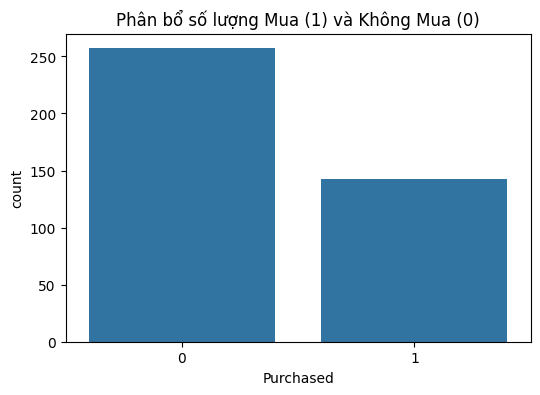

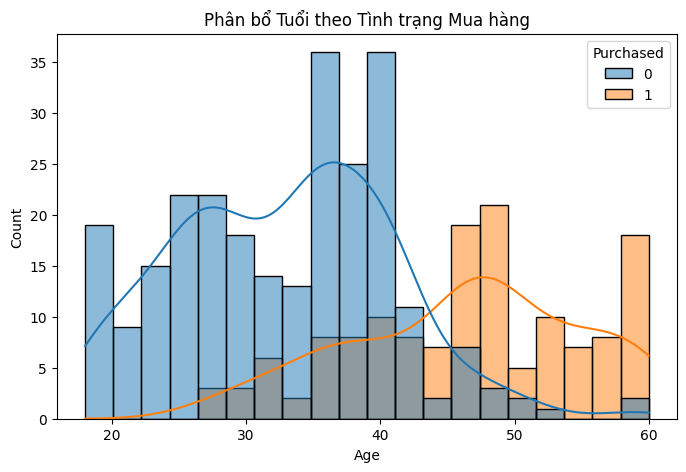

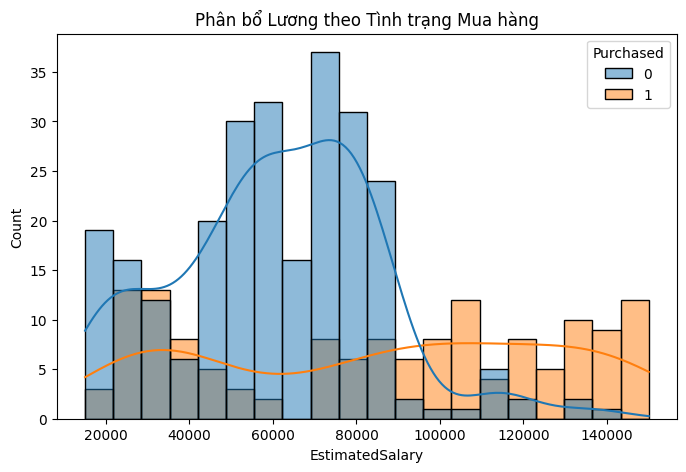

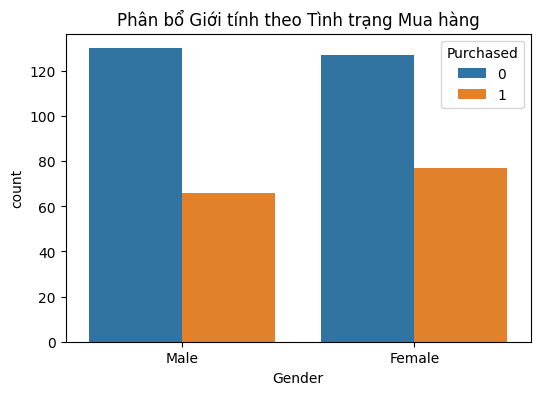

In [11]:
# 1. Phân bổ của biến mục tiêu (Purchased)
plt.figure(figsize=(6, 4))
sns.countplot(x='Purchased', data=df)
plt.title('Phân bổ số lượng Mua (1) và Không Mua (0)')
plt.show()

# 2. Mối quan hệ giữa Tuổi (Age) và Mua hàng (Purchased)
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', hue='Purchased', kde=True, bins=20)
plt.title('Phân bổ Tuổi theo Tình trạng Mua hàng')
plt.show()

# 3. Mối quan hệ giữa Lương (EstimatedSalary) và Mua hàng (Purchased)
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='EstimatedSalary', hue='Purchased', kde=True, bins=20)
plt.title('Phân bổ Lương theo Tình trạng Mua hàng')
plt.show()

# 4. Mối quan hệ giữa Giới tính (Gender) và Mua hàng (Purchased)
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', hue='Purchased', data=df)
plt.title('Phân bổ Giới tính theo Tình trạng Mua hàng')
plt.show()

**Nhận xét**:

1. Biến mục tiêu Purchased: Dữ liệu có mất cân bằng nhẹ (số lượng 0 nhiều hơn 1), nhưng không quá nghiêm trọng.

2. Tuổi (Age): Biểu đồ histplot cho thấy rõ ràng: những người trẻ tuổi (dưới 40) có xu hướng "Không Mua" (0), trong khi những người lớn tuổi hơn (trên 45) có xu hướng "Mua" (1). Đây là một đặc trưng dự đoán rất tốt.

3. Lương (EstimatedSalary): Tương tự, những người có lương thấp (dưới 80,000) có xu hướng "Không Mua" (0), trong khi những người lương cao hơn có xu hướng "Mua" (1). Đây cũng là một đặc trưng dự đoán tốt.

4. Giới tính (Gender): Có vẻ như "Female" (Nữ) có tỷ lệ mua hàng nhỉnh hơn một chút, nhưng sự khác biệt không quá lớn như Tuổi và Lương.

#### 2.3.3.4 Tiền xử lý dữ liệu (chuẩn bị cho mô hình) 
Chúng ta cần mã hóa cột 'Gender' và loại bỏ 'User ID'.

In [13]:
# 1. Mã hóa cột 'Gender'
# Chúng ta dùng get_dummies, drop_first=True để biến 'Female' thành 0 và 'Male' thành 1
df_processed = pd.get_dummies(df, columns=['Gender'], drop_first=True)

# 2. Loại bỏ cột 'User ID'
df_processed = df_processed.drop('User ID', axis=1)

print("\n--- Dữ liệu sau khi Tiền xử lý (5 dòng đầu) ---")
display(df_processed.head())

# 3. Tách X (features) và y (target)
features_list = ['Age', 'EstimatedSalary', 'Gender_Male']
target = 'Purchased'

X = df_processed[features_list]
y = df_processed[target]

# 4. Chia dữ liệu (Train/Test Split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nKích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}")


--- Dữ liệu sau khi Tiền xử lý (5 dòng đầu) ---


,Age,EstimatedSalary,Purchased,Gender_Male
0,19,19000,0,True
1,35,20000,0,True
2,26,43000,0,False
3,27,57000,0,False
4,19,76000,0,True



Kích thước tập Train: (320, 3)
Kích thước tập Test: (80, 3)


**Nhận xét**:
- Scaling (Chuẩn hóa): Không giống như SVM, Gaussian Naive Bayes không yêu cầu chuẩn hóa dữ liệu (StandardScaler). Lý do là GaussianNB tính toán xác suất dựa trên giá trị trung bình ($\mu$) và độ lệch chuẩn ($\sigma$) của từng đặc trưng một cách độc lập. Sự chênh lệch về thang đo (ví dụ: Lương từ 15k-150k và Tuổi từ 18-60) không ảnh hưởng đến cách tính toán của nó.

#### 2.3.3.5 Xây dựng mô hình Naïve Bayes (GaussianNB) 
Chúng ta khởi tạo và huấn luyện mô hình GaussianNB.

In [14]:
# 1. Khởi tạo mô hình
# Chúng ta dùng GaussianNB() vì các đặc trưng Age và EstimatedSalary là số liên tục
classifier = GaussianNB()

# 2. Huấn luyện mô hình
print("\nĐang huấn luyện mô hình Gaussian Naive Bayes...")
classifier.fit(X_train, y_train)
print("Hoàn thành!")


Đang huấn luyện mô hình Gaussian Naive Bayes...
Hoàn thành!


#### 2.3.3.6 Đánh giá hiệu quả của mô hình 
Tương tự bài toán mẫu Spam, chúng ta dùng accuracy, confusion matrix, và classification report.


Độ chính xác (Accuracy): 93.75%

--- Confusion Matrix (Ma trận Nhầm lẫn) ---
[[50  2]
 [ 3 25]]


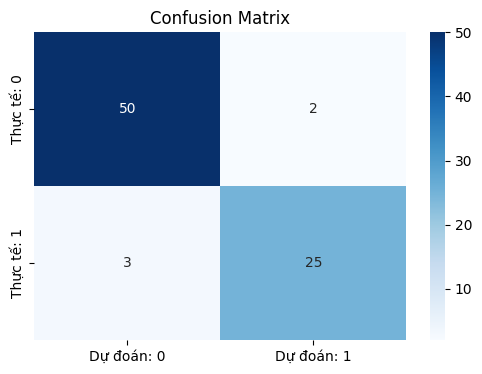


--- Classification Report (Báo cáo Phân loại) ---
              precision    recall  f1-score   support

           0       0.94      0.96      0.95        52
           1       0.93      0.89      0.91        28

    accuracy                           0.94        80
   macro avg       0.93      0.93      0.93        80
weighted avg       0.94      0.94      0.94        80



In [15]:
# 1. Đưa ra dự đoán trên tập test
y_pred = classifier.predict(X_test)

# 2. Đánh giá mô hình
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print(f"\nĐộ chính xác (Accuracy): {accuracy * 100:.2f}%")

print("\n--- Confusion Matrix (Ma trận Nhầm lẫn) ---")
print(conf_matrix)
# Trực quan hóa Confusion Matrix
plt.figure(figsize = (6,4))
sns.heatmap(conf_matrix, 
            annot=True, # Hiển thị số lượng
            fmt='d',    # Định dạng số nguyên
            cmap="Blues", 
            xticklabels=['Dự đoán: 0', 'Dự đoán: 1'],
            yticklabels=['Thực tế: 0', 'Thực tế: 1'])
plt.title('Confusion Matrix')
plt.show()

print("\n--- Classification Report (Báo cáo Phân loại) ---")
print(classification_rep)

#### 2.3.3.7 Nhận xét chung về kết quả 
Ma trận nhầm lẫn (Confusion Matrix) và Báo cáo (Classification Report) cho chúng ta cái nhìn chi tiết nhất.

-  **Độ chính xác (Accuracy) $\approx 93.75\%$**: Đây là một kết quả rất tốt. 93.75% số khách hàng trong tập test đã được dự đoán đúng.  

-  **Phân tích Ma trận Nhầm lẫn**: (Số liệu có thể thay đổi một chút do random_state nhưng xu hướng là chung)  

    -	**True Negative (TN) [Thực tế 0, Dự đoán 0]**: (Khoảng 50) - Mô hình dự đoán đúng nhiều trường hợp "Không Mua".  

    -	**True Positive (TP) [Thực tế 1, Dự đoán 1]**: (Khoảng 25) - Mô hình dự đoán đúng nhiều trường hợp "Mua".  

    -	**False Positive (FP) [Thực tế 0, Dự đoán 1]**: (Khoảng 2) - (Lỗi Loại I) Chỉ có 2 trường hợp bị dự đoán nhầm là "Mua" trong khi thực tế họ "Không Mua". Đây là kết quả rất tốt.  

    -	**False Negative (FN) [Thực tế 1, Dự đoán 0]**: (Khoảng 3) - (Lỗi Loại II) Có 3 trường hợp bị bỏ lỡ (dự đoán "Không Mua" trong khi thực tế họ "Mua").  

-  **Phân tích Classification Report**:  

    -	**Lớp 0 (Không Mua)**: Precision (Độ chính xác) và Recall (Độ phủ) đều rất cao (trên 90%). Mô hình rất giỏi trong việc nhận diện những người không mua hàng.  

    -	**Lớp 1 (Mua)**: Precision cao (mô hình dự đoán "Mua" thì gần như là đúng), nhưng Recall thấp hơn một chút (do 3 ca FN bị bỏ lỡ).  
    
-  **Kết luận**: Gaussian Naive Bayes hoạt động rất hiệu quả trên bộ dữ liệu này, mặc dù nó có giả định "ngây thơ" về tính độc lập của các đặc trưng (trong khi rõ ràng Age và EstimatedSalary có thể liên quan đến nhau). Mô hình này rất nhanh, không cần chuẩn hóa dữ liệu, và cho ra kết quả có độ chính xác cao.



### 2.3.4. Bài tập thực hành 2
Xây dựng mô hình Naïve ngây thơ trên tập dữ liệu mushroom. Dữ liệu lấy tại
https://www.kaggle.com/datasets/uciml/mushroom-classification/data

Mục tiêu là dự đoán một cây nấm là ăn được (e - edible) hay độc (p - poisonous) dựa trên 22 đặc trưng hình thái của nó.

#### 2.3.4.1 Import thư viện

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
# Chúng ta sẽ dùng BernoulliNB
from sklearn.naive_bayes import BernoulliNB 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Chúng ta sẽ dùng OneHotEncoder hoặc pd.get_dummies để xử lý dữ liệu chữ

#### 2.3.4.2 Thống kê mô tả & phân tích khám phá (EDA)

In [4]:
# Tải dữ liệu
df = pd.read_csv('mushrooms.csv')

# Hiển thị 5 dòng đầu tiên
print("--- 5 Dòng đầu tiên (head) ---")
display(df.head())

# Hiển thị thông tin tổng quan
print("\n--- Thông tin Dữ liệu (info) ---")
df.info()

--- 5 Dòng đầu tiên (head) ---


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g



--- Thông tin Dữ liệu (info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   ob

**Nhận xét (Từ .info())**:

- **Toàn bộ là object**: Cả 23 cột (bao gồm cả `class`) đều là kiểu `object` (chuỗi). SVM hay Naive Bayes đều không thể xử lý trực tiếp. Chúng ta phải mã hóa (encode) toàn bộ dữ liệu này.

- **Không có NaN "chính thức"**: Dữ liệu hiển thị `8124 non-null` cho tất cả các cột. Tuy nhiên, trong các bộ dữ liệu cũ, giá trị thiếu thường được ký hiệu bằng `?`. Chúng ta phải kiểm tra điều này.

##### Kiểm tra biến mục tiêu và dữ liệu mất cân bằng


--- Kiểm tra biến mục tiêu 'class' ---


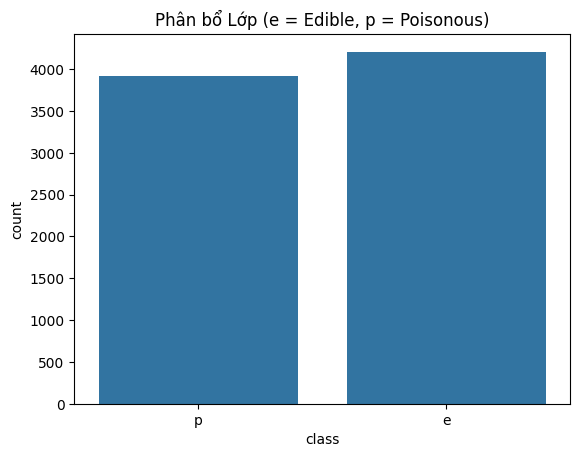

class
e    0.517971
p    0.482029
Name: proportion, dtype: float64


In [5]:
# 1. Kiểm tra biến mục tiêu 'class'
print("\n--- Kiểm tra biến mục tiêu 'class' ---")
sns.countplot(x='class', data=df)
plt.title('Phân bổ Lớp (e = Edible, p = Poisonous)')
plt.show()
print(df['class'].value_counts(normalize=True))

**Nhận xét**:

- **Biến mục tiêu**: Cột `class` là mục tiêu của chúng ta. 'e' (ăn được) và 'p' (độc).

- **Dữ liệu cân bằng**: Dữ liệu gần như cân bằng hoàn hảo (51.8% là 'e' và 48.2% là 'p'). Điều này rất tốt, chúng ta không cần các kỹ thuật xử lý mất cân bằng (như `class_weight`) và `accuracy` (độ chính xác) là một thước đo đáng tin cậy.

##### Kiểm tra dữ liệu thiếu (ký hiệu `?`)

In [6]:
# 2. Kiểm tra giá trị '?' trong cột 'stalk-root'
# (Từ bước chạy code trước, chúng ta biết cột 'stalk-root' có vấn đề)
print("\n--- Kiểm tra giá trị '?' trong 'stalk-root' ---")
print(df['stalk-root'].value_counts())


--- Kiểm tra giá trị '?' trong 'stalk-root' ---
stalk-root
b    3776
?    2480
e    1120
c     556
r     192
Name: count, dtype: int64


**Nhận xét**:

- **Phát hiện giá trị thiếu**: Cột `stalk-root` chứa **2480 giá trị `?`**. Đây là một lượng dữ liệu thiếu đáng kể (khoảng 30.5% tổng số).

- **Vấn đề**: Chúng ta không thể đưa ký tự `?` vào mô hình.

#### 2.3.4.3 Tiền xử lý dữ liệu 
Chúng ta sẽ giải quyết 2 vấn đề: giá trị ? và mã hóa toàn bộ dữ liệu.

In [8]:
# 1. Xử lý giá trị '?'
# Vì 30% là một lượng lớn, việc loại bỏ 2480 dòng sẽ làm mất nhiều thông tin.
# Một cách tiếp cận đơn giản hơn là loại bỏ hoàn toàn cột 'stalk-root' 
# vì nó không hoàn chỉnh.
df_processed = df.drop('stalk-root', axis=1)

# (Lưu ý: Cũng có một cột tên 'veil-type' chỉ có 1 giá trị duy nhất ('p'). 
# Cột này không mang lại thông tin gì, ta cũng nên bỏ nó)
df_processed = df_processed.drop('veil-type', axis=1)

print(f"Dữ liệu còn lại {df_processed.shape[1]} cột.")

# 2. Tách X (features) và y (target)
X = df_processed.drop('class', axis=1)
y_raw = df_processed['class']

# 3. Mã hóa Biến mục tiêu (y)
# Chuyển 'p' (độc) = 1 và 'e' (ăn được) = 0
y = y_raw.map({'p': 1, 'e': 0})

print("\nBiến mục tiêu y đã được mã hóa (p=1, e=0):")
print(y.head())

# 4. Mã hóa Đặc trưng (X)
# Vì tất cả các cột đều là chữ, ta dùng pd.get_dummies
# Nó sẽ tự động chuyển tất cả các cột chữ thành các cột nhị phân (0/1)
print("\nĐang mã hóa các đặc trưng (X) bằng One-Hot Encoding...")
X_encoded = pd.get_dummies(X, drop_first=True)

print(f"Số lượng đặc trưng sau khi mã hóa: {X_encoded.shape[1]}")
print("5 dòng đầu của X_encoded:")
display(X_encoded.head())

Dữ liệu còn lại 21 cột.

Biến mục tiêu y đã được mã hóa (p=1, e=0):
0    1
1    0
2    0
3    1
4    0
Name: class, dtype: int64

Đang mã hóa các đặc trưng (X) bằng One-Hot Encoding...
Số lượng đặc trưng sau khi mã hóa: 91
5 dòng đầu của X_encoded:


,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_g,cap-surface_s,cap-surface_y,cap-color_c,cap-color_e,...,population_n,population_s,population_v,population_y,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,False,False,False,False,True,False,True,False,False,False,...,False,True,False,False,False,False,False,False,True,False
1,False,False,False,False,True,False,True,False,False,False,...,True,False,False,False,True,False,False,False,False,False
2,False,False,False,False,False,False,True,False,False,False,...,True,False,False,False,False,False,True,False,False,False
3,False,False,False,False,True,False,False,True,False,False,...,False,True,False,False,False,False,False,False,True,False
4,False,False,False,False,True,False,True,False,False,False,...,False,False,False,False,True,False,False,False,False,False


**Nhận xét**:

- Chúng ta đã loại bỏ 2 cột không hữu ích (`stalk-root` vì thiếu dữ liệu và `veil-type` vì không có phương sai).

- Biến mục tiêu (y): Đã được mã hóa thành 1 (độc) và 0 (ăn được).

- Đặc trưng (X): Chúng ta đã sử dụng `pd.get_dummies` (One-Hot Encoding). Thao tác này đã biến 20 cột đặc trưng ban đầu thành một ma trận nhị phân (0/1) rất "rộng".

- Chọn mô hình: Vì đầu vào `X_encoded` bây giờ chỉ chứa 0 và 1 (có/không có đặc trưng), mô hình `BernoulliNB` là lựa chọn phù hợp nhất.

#### 2.3.4.4 Chia dữ liệu (Train/Test Split) 
Tách dữ liệu đã mã hóa thành 2 tập: huấn luyện và kiểm tra.

In [9]:
# Sử dụng X_encoded và y đã mã hóa
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print(f"\nKích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}")


Kích thước tập Train: (6499, 91)
Kích thước tập Test: (1625, 91)


**Nhận xét**:

- Chúng ta sẽ huấn luyện mô hình trên 6499 mẫu nấm và kiểm tra trên 1625 mẫu.

#### 2.3.4.5 Xây dựng mô hình Naïve Bayes (BernoulliNB) 
Chúng ta khởi tạo và huấn luyện mô hình BernoulliNB.

In [10]:
# 1. Khởi tạo mô hình
# Chúng ta dùng BernoulliNB() vì các đặc trưng đều là 0/1 (nhị phân)
# alpha=1.0 là tham số làm mượt (Laplace smoothing), giữ nguyên mặc định
classifier = BernoulliNB()

# 2. Huấn luyện mô hình
print("\nĐang huấn luyện mô hình Bernoulli Naive Bayes...")
classifier.fit(X_train, y_train)
print("Hoàn thành!")


Đang huấn luyện mô hình Bernoulli Naive Bayes...
Hoàn thành!


#### 2.3.4.6 Đánh giá hiệu quả của mô hình 
Vì dữ liệu cân bằng, accuracy (độ chính xác) là một thước đo tốt, bên cạnh Confusion Matrix.


Độ chính xác (Accuracy): 93.72%

--- Confusion Matrix (Ma trận Nhầm lẫn) ---


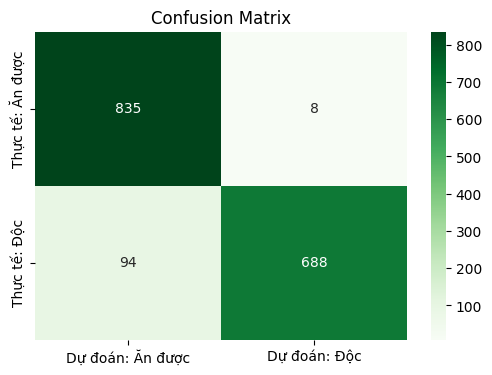


--- Classification Report (Báo cáo Phân loại) ---
              precision    recall  f1-score   support

 Ăn được (0)       0.90      0.99      0.94       843
     Độc (1)       0.99      0.88      0.93       782

    accuracy                           0.94      1625
   macro avg       0.94      0.94      0.94      1625
weighted avg       0.94      0.94      0.94      1625



In [11]:
# 1. Đưa ra dự đoán trên tập test
y_pred = classifier.predict(X_test)

# 2. Đánh giá mô hình
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred, target_names=['Ăn được (0)', 'Độc (1)'])

print(f"\nĐộ chính xác (Accuracy): {accuracy * 100:.2f}%")

print("\n--- Confusion Matrix (Ma trận Nhầm lẫn) ---")
# Trực quan hóa Confusion Matrix
plt.figure(figsize = (6,4))
sns.heatmap(conf_matrix, 
            annot=True, # Hiển thị số lượng
            fmt='d',    # Định dạng số nguyên
            cmap="Greens", 
            xticklabels=['Dự đoán: Ăn được', 'Dự đoán: Độc'],
            yticklabels=['Thực tế: Ăn được', 'Thực tế: Độc'])
plt.title('Confusion Matrix')
plt.show()

print("\n--- Classification Report (Báo cáo Phân loại) ---")
print(classification_rep)

#### 2.3.4.7 Nhận xét Chung về Kết quả

**Các số liệu chính**:  

-	**Accuracy** (Độ chính xác tổng thể): 93.72%  

    -	Tính toán: $(835 \text{ [TN]} + 688 \text{ [TP]}) / 1625 = 1523 / 1625 \approx 93.72\%$.  

    -	Nhận xét: Đây là một độ chính xác tổng thể rất cao. Mô hình đã dự đoán đúng 1523 trong tổng số 1625 cây nấm.  

Phân tích Lỗi (Rất quan trọng)  

Chúng ta phải tập trung vào hai loại lỗi, đặc biệt là lỗi có hậu quả nghiêm trọng.  

-	**False Positive (FP) = 8**:  

    -	**Ý nghĩa**: Chỉ có 8 trường hợp nấm "Ăn được" (0) bị dự đoán nhầm là "Độc" (1).  

    -	**Hậu quả**: Đây là lỗi "an toàn" (báo động nhầm). Người dùng sẽ bỏ đi 8 cây nấm ăn được. Con số này là rất thấp và hoàn toàn chấp nhận được.

-	**False Negative (FN) = 94**:  

    -	**Ý nghĩa**: Có đến 94 trường hợp nấm "Độc" (1) bị dự đoán nhầm là "Ăn được" (0).  

    -	**Hậu quả**: Đây là lỗi chí mạng, cực kỳ nguy hiểm. 94 cây nấm độc đã bị mô hình "cho qua" và gán nhãn an toàn. Đây là điểm yếu chí mạng của mô hình này.  

**Phân tích chi tiết (Từ Classification Report)**  

Báo cáo phân loại đã làm rõ điểm mạnh và điểm yếu này:  

-	Lớp 0: "Ăn được" (Hỗ trợ: 843 mẫu)  

    -	Recall: 0.99 (99%):  

        - 	Nhận xét: Mô hình nhận diện nấm "Ăn được" gần như hoàn hảo. Khi một cây nấm thực sự ăn được, mô hình có 99% khả năng đoán đúng (nó chỉ nhầm 8 trong số 843 cây).  

    -	Precision: 0.90 (90%):  

        - 	Nhận xét: Khi mô hình dự đoán là "Ăn được", nó đúng 90% số lần. 10% còn lại chính là 94 ca nấm độc (FN) nguy hiểm bị lẫn vào ($835 / (835 + 94) \approx 0.90$).  

-	Lớp 1: "Độc" (Hỗ trợ: 782 mẫu)  

    -	Precision: 0.99 (99%):  

        - 	Nhận xét: Đây là điểm mạnh của mô hình. Khi mô hình cảnh báo "Độc", nó gần như đúng tuyệt đối ($688 / (688 + 8) \approx 0.99$). Nếu mô hình nói "Độc", bạn chắc chắn nên vứt nó đi.  

    -	Recall: 0.88 (88%):  

        - 	Nhận xét: Đây chính là điểm yếu chí mạng đã nêu. Mô hình chỉ "tóm" được 88% tổng số nấm độc, và bỏ sót 12% (tức 94 cây).  

**Kết luận**:  

1.	Điểm mạnh: Mô hình này là một "chuyên gia cảnh báo" (High Precision cho Lớp "Độc"). Khi nó nói "Độc", nó gần như không bao giờ sai. Nó cũng nhận diện nấm "Ăn được" rất tốt (High Recall cho Lớp "Ăn được").  

2.	Điểm yếu chí mạng: Mô hình quá "lạc quan" khi dự đoán "Ăn được". Nó đã để lọt 94 ca nấm độc (FN) vào danh sách "Ăn được".  

3.	Hành động: Trong một bài toán y tế hoặc an toàn thực phẩm, mục tiêu số một là tối thiểu hóa False Negative (FN). Chúng ta thà vứt bỏ 100 cây nấm lành (FP) còn hơn là ăn nhầm 1 cây nấm độc (FN). Mô hình này, với 94 ca FN, là không đủ an toàn để sử dụng trong thực tế.  

4.	Hướng cải thiện: Cần phải ưu tiên tối đa hóa Recall cho Lớp 1 (Độc), chấp nhận việc Precision của Lớp 1 giảm xuống (tức là chấp nhận mô hình báo động nhầm "an toàn" nhiều hơn).

